# Скачивание датасета

In [1]:
!pip -q install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 26.6 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
from pathlib import Path

import json
import os
import subprocess

PROJECT_DIR = Path('/content/hdb_compnet')
DATA_DIR = PROJECT_DIR / 'data'

DATASET_SLUG = 'paveleshmeev/sgp-resale-prices-90'
DATA_FILENAME = 'df_common_sample_complete_case.csv'
DATA_PATH = DATA_DIR / DATA_FILENAME

KAGGLE_DIR = Path.home() / '.kaggle'
KAGGLE_CREDENTIALS_PATH = KAGGLE_DIR / 'kaggle.json'

DATA_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

kaggle_credentials = {
    'username': userdata.get('KAGGLE_USERNAME'),
    'key': userdata.get('KAGGLE_KEY')
}

KAGGLE_CREDENTIALS_PATH.write_text(
    json.dumps(kaggle_credentials),
    encoding='utf-8'
)

os.chmod(KAGGLE_CREDENTIALS_PATH, 0o600)

In [3]:
subprocess.run(
    [
        'kaggle',
        'datasets',
        'download',
        '--dataset',
        DATASET_SLUG,
        '--file',
        DATA_FILENAME,
        '--path',
        str(DATA_DIR),
        '--unzip',
        '--force'
    ],
    check=True
)

CompletedProcess(args=['kaggle', 'datasets', 'download', '--dataset', 'paveleshmeev/sgp-resale-prices-90', '--file', 'df_common_sample_complete_case.csv', '--path', '/content/hdb_compnet/data', '--unzip', '--force'], returncode=0)

In [4]:
import pandas as pd

df_common_sample = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

df_common_sample.head()

,resale_id,transaction_date,x,y,max_floor_lvl,year_completed,commercial,market_hawker,miscellaneous,multistorey_carpark,...,household_net_worth,resale_price,floor_mean,town,flat_type,floor_area_sqm,flat_model,lease_commence_date,remaining_lease_full_years,log_resale_price
0,85762,1995-01-01,24111.492688,30993.386185,10.0,1962.0,0.0,0.0,0.0,0.0,...,423213.9,54000.0,2,QUEENSTOWN,2 ROOM,46.0,STANDARD,1971,74,10.896739
1,85763,1995-01-01,24094.806524,31073.554178,10.0,1962.0,0.0,0.0,0.0,0.0,...,423213.9,42000.0,5,QUEENSTOWN,2 ROOM,46.0,STANDARD,1971,74,10.645425
2,85764,1995-01-01,24094.806524,31073.554178,10.0,1962.0,0.0,0.0,0.0,0.0,...,423213.9,40000.0,11,QUEENSTOWN,2 ROOM,46.0,STANDARD,1971,74,10.596635
3,85773,1995-01-01,22581.776154,32150.973599,14.0,1975.0,0.0,0.0,0.0,0.0,...,423213.9,126000.0,11,QUEENSTOWN,3 ROOM,73.0,IMPROVED,1976,79,11.744037
4,85749,1995-01-01,23968.094605,31179.678814,10.0,1963.0,0.0,0.0,0.0,0.0,...,423213.9,45000.0,11,QUEENSTOWN,2 ROOM,46.0,STANDARD,1983,86,10.714418


# Подготовка данных

## Разделение на train, val, test выборки

In [61]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df_common_sample['transaction_date'] = pd.to_datetime(df_common_sample['transaction_date'], errors='coerce')

df_common_sample['sale_year'] = df_common_sample['transaction_date'].dt.year

In [62]:
random_state = 42

df_train, df_temp = train_test_split(
    df_common_sample,
    test_size=0.30,
    random_state=random_state,
    shuffle=True,
    stratify=df_common_sample['sale_year']
)

print('train:', df_train.shape)
print('temp: ', df_temp.shape)

train: (603532, 71)
temp:  (258657, 71)


In [63]:
df_val, df_test = train_test_split(
    df_temp,
    test_size=2/3,
    random_state=random_state,
    shuffle=True,
    stratify=df_temp['sale_year']
)

print('train:', df_train.shape, f'({len(df_train) / len(df_common_sample):.2%})')
print('val:  ', df_val.shape,   f'({len(df_val) / len(df_common_sample):.2%})')
print('test: ', df_test.shape,  f'({len(df_test) / len(df_common_sample):.2%})')

train: (603532, 71) (70.00%)
val:   (86219, 71) (10.00%)
test:  (172438, 71) (20.00%)


In [64]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

## Состав retrieval-матриц

In [65]:
RETRIEVAL_SPACES = {
    'structural': {
        'numeric': (
            'max_floor_lvl',
            'year_completed',
            'commercial',
            'market_hawker',
            'miscellaneous',
            'multistorey_carpark',
            'precinct_pavilion',
            'total_dwelling_units',
            'floor_mean',
            'floor_area_sqm',
            'lease_commence_date',
            'remaining_lease_full_years'
        ),
        'categorical': (
            'flat_model',
        )
    },
    'spatial': {
        'numeric': (
            'x',
            'y',
            'dist_mrt_exit_m',
            'mrt_station_count_1km',
            'walk_time_to_nearest_mrt_exit_min',
            'dist_to_raffles_place_m',
            'dist_nearest_primary_school_m',
            'primary_school_count_1km',
            'dist_nearest_secondary_school_m',
            'secondary_school_count_1km',
            'dist_nearest_park_m',
            'park_count_1km',
            'dist_nearest_hospital_m',
            'hospital_count_1km',
            'dist_nearest_hawker_centre_m',
            'hawker_centre_count_1km'
        ),
        'categorical': (
            'town',
            'nearest_hospital_type',
            'nearest_hospital_category'
        )
    },
    'market': {
        'numeric': (
            'month_index',
            'month_sin',
            'month_cos',
            'bank_hdb_max_tenure_years',
            'bank_hdb_msr',
            'hdb_housing_loan_max_tenure_years',
            'hdb_housing_msr',
            'ltv_first_std',
            'ltv_second_std',
            'ltv_third_plus_std',
            'ltv_non_individual_std',
            'ltv_first_long',
            'ltv_second_long',
            'ltv_third_plus_long',
            'ltv_any_existing_std',
            'ltv_any_existing_long',
            'cpf_oa_rate',
            'hdb_ltv_effective',
            'cpi_all_items',
            'sgs_2y_yield',
            'real_gdp_sa',
            'resident_population',
            'resident_unemployment_rate',
            'ulc_index_sa',
            'per_capita_gdp_real',
            'resident_households_hdb',
            'household_net_worth'
        ),
        'categorical': ()
    }
}

RETRIEVAL_REFERENCE_COLUMNS = (
    'resale_id',
    'month_index',
    'floor_area_sqm',
    'flat_type',
    'target_scaled'
)

RETRIEVAL_GROUP_COLUMN = 'flat_type'

## Подготовка целевой переменной

In [66]:
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()

df_train['target_scaled'] = target_scaler.fit_transform(
    df_train[['log_resale_price']]
).ravel()

df_val['target_scaled'] = target_scaler.transform(
    df_val[['log_resale_price']]
).ravel()

df_test['target_scaled'] = target_scaler.transform(
    df_test[['log_resale_price']]
).ravel()

## Подготовка численных переменных

In [67]:
for df in (df_train, df_val, df_test):
    month = df['transaction_date'].dt.month

    df['month_index'] = (
        df['transaction_date'].dt.year * 12 + month - 1
    ).astype('int32')

    df['month_sin'] = np.sin(
        2 * np.pi * (month - 1) / 12
    ).astype('float32')

    df['month_cos'] = np.cos(
        2 * np.pi * (month - 1) / 12
    ).astype('float32')

In [68]:
from sklearn.preprocessing import StandardScaler

train_reference = df_train[
    [
        'resale_id',
        'month_index',
        'floor_area_sqm',
        'flat_type',
        'target_scaled'
    ]
].copy()

val_reference = df_val[
    [
        'resale_id',
        'month_index',
        'floor_area_sqm',
        'flat_type',
        'target_scaled'
    ]
].copy()

test_reference = df_test[
    [
        'resale_id',
        'month_index',
        'floor_area_sqm',
        'flat_type',
        'target_scaled'
    ]
].copy()

In [60]:
def add_hdb_ltv_effective(df):
    df = df.copy()

    df['hdb_ltv_effective'] = np.select(
        [
            df['flat_type'].eq('1 ROOM'),
            df['flat_type'].eq('2 ROOM'),
            df['flat_type'].eq('3 ROOM'),
            df['flat_type'].eq('4 ROOM'),
            df['flat_type'].eq('5 ROOM'),
            df['flat_type'].eq('EXECUTIVE'),
            df['flat_type'].eq('MULTI-GENERATION')
        ],
        [
            df['hdb_ltv_1room'],
            df['hdb_ltv_2room'],
            df['hdb_ltv_3room'],
            df['hdb_ltv_4room'],
            df['hdb_ltv_5room'],
            df['hdb_ltv_exec'],
            df['hdb_ltv_others']
        ],
        default=np.nan
    )

    return df.drop(
        columns=[
            'hdb_ltv_1room',
            'hdb_ltv_2room',
            'hdb_ltv_3room',
            'hdb_ltv_4room',
            'hdb_ltv_5room',
            'hdb_ltv_exec',
            'hdb_ltv_others'
        ]
    )

In [69]:
df_train = add_hdb_ltv_effective(df_train)
df_val = add_hdb_ltv_effective(df_val)
df_test = add_hdb_ltv_effective(df_test)

In [70]:
unscaled_numeric_columns = [
    'commercial',
    'market_hawker',
    'miscellaneous',
    'multistorey_carpark',
    'precinct_pavilion',
    'month_sin',
    'month_cos'
]

excluded_numeric_columns = {
    'resale_id',
    'sale_year',
    'resale_price',
    'log_resale_price',
    'target_scaled',
    'x',
    'y',
    'hdb_ltv_1room',
    'hdb_ltv_2room',
    'hdb_ltv_3room',
    'hdb_ltv_4room',
    'hdb_ltv_5room',
    'hdb_ltv_exec',
    'hdb_ltv_others',
    *unscaled_numeric_columns
}

standardized_numeric_columns = [
    column
    for column in df_train.select_dtypes(include=np.number).columns
    if column not in excluded_numeric_columns
]

numeric_scaler = StandardScaler()
numeric_scaler.fit(df_train[standardized_numeric_columns])

coordinate_center = df_train[['x', 'y']].mean()

coordinate_scale = np.sqrt(
    (
        (df_train[['x', 'y']] - coordinate_center) ** 2
    ).to_numpy().mean()
)

In [71]:
numerical_feature_columns = [
    column
    for column in df_train.columns
    if column in (
        set(standardized_numeric_columns)
        | set(unscaled_numeric_columns)
        | {'x', 'y'}
    )
]

def transform_numeric_features(df):
    transformed = pd.DataFrame(
        numeric_scaler.transform(
            df[standardized_numeric_columns]
        ),
        columns=standardized_numeric_columns,
        index=df.index,
        dtype='float32'
    )

    transformed[['x', 'y']] = (
        (df[['x', 'y']] - coordinate_center)
        / coordinate_scale
    ).astype('float32')

    transformed[unscaled_numeric_columns] = (
        df[unscaled_numeric_columns].astype('float32')
    )

    return transformed[numerical_feature_columns]

In [72]:
X_train_numeric = transform_numeric_features(df_train)
X_val_numeric = transform_numeric_features(df_val)
X_test_numeric = transform_numeric_features(df_test)

## Подготовка категориальных данных

In [75]:
from sklearn.preprocessing import OneHotEncoder

retrieval_one_hot_encoders = {}

X_train_categorical = {}
X_val_categorical = {}
X_test_categorical = {}

for space_name, space_config in RETRIEVAL_SPACES.items():
    if not space_config['categorical']:
        continue

    retrieval_one_hot_encoders[space_name] = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=True,
        dtype=np.float32
    )

    X_train_categorical[space_name] = (
        retrieval_one_hot_encoders[space_name]
        .fit_transform(
            df_train[list(space_config['categorical'])]
        )
        .tocsr()
    )

    X_val_categorical[space_name] = (
        retrieval_one_hot_encoders[space_name]
        .transform(
            df_val[list(space_config['categorical'])]
        )
        .tocsr()
    )

    X_test_categorical[space_name] = (
        retrieval_one_hot_encoders[space_name]
        .transform(
            df_test[list(space_config['categorical'])]
        )
        .tocsr()
    )

In [76]:
CATEGORY_COLUMNS = (
    'town',
    'flat_type',
    'flat_model',
    'nearest_hospital_type',
    'nearest_hospital_category'
)

category_mappings = {
    column: {
        category: index
        for index, category in enumerate(
            sorted(df_train[column].dropna().unique()),
            start=1
        )
    }
    for column in CATEGORY_COLUMNS
}

In [77]:
category_cardinalities = {
    column: len(mapping) + 1
    for column, mapping in category_mappings.items()
}

embedding_dimensions = {
    column: min(
        16,
        max(
            2,
            int(np.ceil(np.sqrt(cardinality)))
        )
    )
    for column, cardinality in category_cardinalities.items()
}

In [78]:
def encode_categories(df):
    return pd.DataFrame(
        {
            column: (
                df[column]
                .map(category_mappings[column])
                .fillna(0)
                .astype('int64')
            )
            for column in CATEGORY_COLUMNS
        },
        index=df.index
    )

In [79]:
X_train_category_indices = encode_categories(df_train)
X_val_category_indices = encode_categories(df_val)
X_test_category_indices = encode_categories(df_test)

## Создание retrieval-матриц

In [80]:
from scipy.sparse import csr_matrix, hstack

def build_retrieval_matrices(
    numeric_features,
    categorical_features
):
    retrieval_matrices = {}

    for space_name, space_config in RETRIEVAL_SPACES.items():
        numeric_matrix = numeric_features[
            list(space_config['numeric'])
        ].to_numpy(
            dtype=np.float32,
            copy=True
        )

        if space_config['categorical']:
            retrieval_matrices[space_name] = hstack(
                [
                    csr_matrix(numeric_matrix),
                    categorical_features[space_name]
                ],
                format='csr',
                dtype=np.float32
            )
        else:
            retrieval_matrices[space_name] = np.ascontiguousarray(
                numeric_matrix,
                dtype=np.float32
            )

    return retrieval_matrices

In [82]:
X_train_retrieval = build_retrieval_matrices(
    X_train_numeric,
    X_train_categorical
)

X_val_retrieval = build_retrieval_matrices(
    X_val_numeric,
    X_val_categorical
)

X_test_retrieval = build_retrieval_matrices(
    X_test_numeric,
    X_test_categorical
)

## Создание Reference Memory

In [83]:
from collections.abc import Mapping
from dataclasses import dataclass
from types import MappingProxyType

from scipy.sparse import csr_matrix


@dataclass(frozen=True, slots=True)
class ReferenceMemory:
    resale_ids: np.ndarray
    month_indices: np.ndarray
    floor_areas: np.ndarray
    flat_type_indices: np.ndarray
    targets: np.ndarray
    numeric_features: np.ndarray
    categorical_features: np.ndarray
    retrieval_features: Mapping[str, np.ndarray | csr_matrix]
    numeric_columns: tuple[str, ...]
    categorical_columns: tuple[str, ...]

    def __len__(self) -> int:
        return self.resale_ids.shape[0]

In [84]:
reference_memory = ReferenceMemory(
    resale_ids=np.ascontiguousarray(
        train_reference['resale_id'].to_numpy(
            dtype=np.int64,
            copy=False
        )
    ),
    month_indices=np.ascontiguousarray(
        train_reference['month_index'].to_numpy(
            dtype=np.int32,
            copy=False
        )
    ),
    floor_areas=np.ascontiguousarray(
        train_reference['floor_area_sqm'].to_numpy(
            dtype=np.float32,
            copy=False
        )
    ),
    flat_type_indices=np.ascontiguousarray(
        X_train_category_indices['flat_type'].to_numpy(
            dtype=np.int64,
            copy=False
        )
    ),
    targets=np.ascontiguousarray(
        train_reference['target_scaled'].to_numpy(
            dtype=np.float32,
            copy=False
        )
    ),
    numeric_features=np.ascontiguousarray(
        X_train_numeric.to_numpy(
            dtype=np.float32,
            copy=False
        )
    ),
    categorical_features=np.ascontiguousarray(
        X_train_category_indices[
            list(CATEGORY_COLUMNS)
        ].to_numpy(
            dtype=np.int64,
            copy=False
        )
    ),
    retrieval_features=MappingProxyType(
        {
            'structural': (
                X_train_retrieval['structural']
                .astype(np.float32, copy=False)
                .tocsr(copy=False)
            ),
            'spatial': (
                X_train_retrieval['spatial']
                .astype(np.float32, copy=False)
                .tocsr(copy=False)
            ),
            'market': np.ascontiguousarray(
                X_train_retrieval['market'],
                dtype=np.float32
            )
        }
    ),
    numeric_columns=tuple(X_train_numeric.columns),
    categorical_columns=tuple(CATEGORY_COLUMNS)
)

## Создание Retrieval indices

In [85]:
from collections.abc import Mapping
from dataclasses import dataclass
from types import MappingProxyType

from sklearn.neighbors import NearestNeighbors


@dataclass(frozen=True, slots=True)
class NeighborGroupIndex:
    model: NearestNeighbors
    memory_positions: np.ndarray

    def __len__(self) -> int:
        return self.memory_positions.shape[0]

In [86]:
def build_retrieval_indices(
    reference_memory: ReferenceMemory
) -> Mapping[str, Mapping[int, NeighborGroupIndex]]:
    retrieval_indices = {}

    flat_type_indices = np.unique(
        reference_memory.flat_type_indices
    )

    flat_type_indices = flat_type_indices[
        flat_type_indices != 0
    ]

    for space_name, retrieval_features in (
        reference_memory.retrieval_features.items()
    ):
        group_indices = {}

        for flat_type_index in flat_type_indices:
            memory_positions = np.flatnonzero(
                reference_memory.flat_type_indices
                == flat_type_index
            ).astype(np.int64)

            model = NearestNeighbors(
                n_neighbors=128,
                algorithm='brute',
                metric='euclidean',
                n_jobs=-1
            )

            model.fit(
                retrieval_features[memory_positions]
            )

            group_indices[int(flat_type_index)] = (
                NeighborGroupIndex(
                    model=model,
                    memory_positions=memory_positions
                )
            )

        retrieval_indices[space_name] = MappingProxyType(
            group_indices
        )

    return MappingProxyType(retrieval_indices)

In [87]:
retrieval_indices = build_retrieval_indices(
    reference_memory
)

# Поиск ближайших транзакций

## Первоначальный поиск ближайших транзакций

In [125]:
from numpy.lib.format import open_memmap


@dataclass(frozen=True, slots=True)
class InitialNeighborCache:
    indices_path: Path
    distances_path: Path
    shape: tuple[int, int]

    def load_indices(
        self,
        mmap_mode: str = 'r'
    ) -> np.ndarray:
        return np.load(
            self.indices_path,
            mmap_mode=mmap_mode
        )

    def load_distances(
        self,
        mmap_mode: str = 'r'
    ) -> np.ndarray:
        return np.load(
            self.distances_path,
            mmap_mode=mmap_mode
        )

In [126]:
def build_initial_neighbor_caches(
    retrieval_indices,
    retrieval_features_by_split,
    category_indices_by_split,
    cache_dir,
    k_search=128,
    batch_size=1024
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    initial_neighbor_caches = {}

    for split_name, retrieval_features in (
        retrieval_features_by_split.items()
    ):
        initial_neighbor_caches[split_name] = {}

        flat_type_indices = category_indices_by_split[
            split_name
        ]['flat_type'].to_numpy(
            dtype=np.int64,
            copy=False
        )

        for space_name, space_indices in (
            retrieval_indices.items()
        ):
            indices_path = (
                cache_dir
                / f'{split_name}_{space_name}_indices.npy'
            )

            distances_path = (
                cache_dir
                / f'{split_name}_{space_name}_distances.npy'
            )

            candidate_indices = open_memmap(
                indices_path,
                mode='w+',
                dtype=np.int32,
                shape=(len(flat_type_indices), k_search)
            )

            candidate_distances = open_memmap(
                distances_path,
                mode='w+',
                dtype=np.float32,
                shape=(len(flat_type_indices), k_search)
            )

            candidate_indices[:] = -1
            candidate_distances[:] = np.inf

            for flat_type_index, group_index in (
                space_indices.items()
            ):
                query_positions = np.flatnonzero(
                    flat_type_indices == flat_type_index
                )

                if query_positions.size == 0:
                    continue

                n_neighbors = min(
                    k_search,
                    len(group_index)
                )

                for start in range(
                    0,
                    query_positions.size,
                    batch_size
                ):
                    batch_positions = query_positions[
                        start:start + batch_size
                    ]

                    distances, local_indices = (
                        group_index.model.kneighbors(
                            retrieval_features[space_name][
                                batch_positions
                            ],
                            n_neighbors=n_neighbors,
                            return_distance=True
                        )
                    )

                    global_indices = (
                        group_index.memory_positions[
                            local_indices
                        ]
                    )

                    candidate_indices[
                        batch_positions,
                        :n_neighbors
                    ] = global_indices.astype(
                        np.int32,
                        copy=False
                    )

                    candidate_distances[
                        batch_positions,
                        :n_neighbors
                    ] = distances.astype(
                        np.float32,
                        copy=False
                    )

            candidate_indices.flush()
            candidate_distances.flush()

            del candidate_indices
            del candidate_distances

            initial_neighbor_caches[
                split_name
            ][space_name] = InitialNeighborCache(
                indices_path=indices_path,
                distances_path=distances_path,
                shape=(len(flat_type_indices), k_search)
            )

        initial_neighbor_caches[split_name] = (
            MappingProxyType(
                initial_neighbor_caches[split_name]
            )
        )

    return MappingProxyType(initial_neighbor_caches)

In [46]:
initial_neighbor_caches = build_initial_neighbor_caches(
    retrieval_indices=retrieval_indices,
    retrieval_features_by_split={
        'train': X_train_retrieval,
        'validation': X_val_retrieval,
        'test': X_test_retrieval
    },
    category_indices_by_split={
        'train': X_train_category_indices,
        'validation': X_val_category_indices,
        'test': X_test_category_indices
    },
    cache_dir=PROJECT_DIR / 'cache' / 'initial_neighbors',
    k_search=128,
    batch_size=1024
)

## Фильтрация транзакций

In [127]:
@dataclass(frozen=True, slots=True)
class FinalCandidateCache:
    indices_path: Path
    distances_path: Path
    time_gaps_path: Path
    masks_path: Path
    counts_path: Path
    shape: tuple[int, int]

    def load_indices(
        self,
        mmap_mode: str = 'r'
    ) -> np.ndarray:
        return np.load(
            self.indices_path,
            mmap_mode=mmap_mode
        )

    def load_distances(
        self,
        mmap_mode: str = 'r'
    ) -> np.ndarray:
        return np.load(
            self.distances_path,
            mmap_mode=mmap_mode
        )

    def load_time_gaps(
        self,
        mmap_mode: str = 'r'
    ) -> np.ndarray:
        return np.load(
            self.time_gaps_path,
            mmap_mode=mmap_mode
        )

    def load_masks(
        self,
        mmap_mode: str = 'r'
    ) -> np.ndarray:
        return np.load(
            self.masks_path,
            mmap_mode=mmap_mode
        )

    def load_counts(
        self,
        mmap_mode: str = 'r'
    ) -> np.ndarray:
        return np.load(
            self.counts_path,
            mmap_mode=mmap_mode
        )

In [128]:
def build_final_candidate_caches(
    initial_neighbor_caches,
    reference_memory,
    reference_by_split,
    cache_dir,
    k_candidates=32,
    batch_size=8192
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    final_candidate_caches = {}

    for split_name, split_reference in reference_by_split.items():
        final_candidate_caches[split_name] = {}

        query_resale_ids = split_reference[
            'resale_id'
        ].to_numpy(
            dtype=np.int64,
            copy=False
        )

        query_month_indices = split_reference[
            'month_index'
        ].to_numpy(
            dtype=np.int32,
            copy=False
        )

        query_floor_areas = split_reference[
            'floor_area_sqm'
        ].to_numpy(
            dtype=np.float32,
            copy=False
        )

        for space_name, initial_cache in (
            initial_neighbor_caches[split_name].items()
        ):
            indices_path = (
                cache_dir
                / f'{split_name}_{space_name}_indices.npy'
            )

            distances_path = (
                cache_dir
                / f'{split_name}_{space_name}_distances.npy'
            )

            time_gaps_path = (
                cache_dir
                / f'{split_name}_{space_name}_time_gaps.npy'
            )

            masks_path = (
                cache_dir
                / f'{split_name}_{space_name}_masks.npy'
            )

            counts_path = (
                cache_dir
                / f'{split_name}_{space_name}_counts.npy'
            )

            final_indices = open_memmap(
                indices_path,
                mode='w+',
                dtype=np.int32,
                shape=(len(split_reference), k_candidates)
            )

            final_distances = open_memmap(
                distances_path,
                mode='w+',
                dtype=np.float32,
                shape=(len(split_reference), k_candidates)
            )

            final_time_gaps = open_memmap(
                time_gaps_path,
                mode='w+',
                dtype=np.int16,
                shape=(len(split_reference), k_candidates)
            )

            final_masks = open_memmap(
                masks_path,
                mode='w+',
                dtype=np.bool_,
                shape=(len(split_reference), k_candidates)
            )

            final_counts = open_memmap(
                counts_path,
                mode='w+',
                dtype=np.uint8,
                shape=(len(split_reference),)
            )

            final_indices[:] = -1
            final_distances[:] = 0
            final_time_gaps[:] = 0
            final_masks[:] = False
            final_counts[:] = 0

            initial_indices = initial_cache.load_indices()
            initial_distances = initial_cache.load_distances()

            for start in range(
                0,
                len(split_reference),
                batch_size
            ):
                end = min(
                    start + batch_size,
                    len(split_reference)
                )

                candidate_indices = np.asarray(
                    initial_indices[start:end]
                )

                candidate_distances = np.asarray(
                    initial_distances[start:end]
                )

                valid = candidate_indices >= 0

                safe_indices = np.where(
                    valid,
                    candidate_indices,
                    0
                )

                candidate_resale_ids = (
                    reference_memory.resale_ids[
                        safe_indices
                    ]
                )

                candidate_month_indices = (
                    reference_memory.month_indices[
                        safe_indices
                    ]
                )

                candidate_floor_areas = (
                    reference_memory.floor_areas[
                        safe_indices
                    ]
                )

                valid &= (
                    candidate_resale_ids
                    != query_resale_ids[start:end, None]
                )

                valid &= (
                    candidate_month_indices
                    < query_month_indices[start:end, None]
                )

                relative_area_difference = np.abs(
                    candidate_floor_areas
                    / query_floor_areas[start:end, None]
                    - 1
                )

                priority = np.full(
                    candidate_indices.shape,
                    3,
                    dtype=np.int8
                )

                priority[
                    valid
                    & (relative_area_difference <= 0.25)
                ] = 2

                priority[
                    valid
                    & (relative_area_difference <= 0.20)
                ] = 1

                priority[
                    valid
                    & (relative_area_difference <= 0.15)
                ] = 0

                selection_order = np.argsort(
                    priority,
                    axis=1,
                    kind='stable'
                )[:, :k_candidates]

                selected_priority = np.take_along_axis(
                    priority,
                    selection_order,
                    axis=1
                )

                selected_masks = selected_priority < 3

                selected_indices = np.take_along_axis(
                    candidate_indices,
                    selection_order,
                    axis=1
                )

                selected_distances = np.take_along_axis(
                    candidate_distances,
                    selection_order,
                    axis=1
                )

                selected_month_indices = np.take_along_axis(
                    candidate_month_indices,
                    selection_order,
                    axis=1
                )

                selected_time_gaps = (
                    query_month_indices[start:end, None]
                    - selected_month_indices
                )

                final_indices[start:end] = np.where(
                    selected_masks,
                    selected_indices,
                    -1
                ).astype(
                    np.int32,
                    copy=False
                )

                final_distances[start:end] = np.where(
                    selected_masks,
                    selected_distances,
                    0
                ).astype(
                    np.float32,
                    copy=False
                )

                final_time_gaps[start:end] = np.where(
                    selected_masks,
                    selected_time_gaps,
                    0
                ).astype(
                    np.int16,
                    copy=False
                )

                final_masks[start:end] = selected_masks

                final_counts[start:end] = (
                    selected_masks.sum(axis=1)
                    .astype(np.uint8)
                )

            final_indices.flush()
            final_distances.flush()
            final_time_gaps.flush()
            final_masks.flush()
            final_counts.flush()

            del final_indices
            del final_distances
            del final_time_gaps
            del final_masks
            del final_counts
            del initial_indices
            del initial_distances

            final_candidate_caches[
                split_name
            ][space_name] = FinalCandidateCache(
                indices_path=indices_path,
                distances_path=distances_path,
                time_gaps_path=time_gaps_path,
                masks_path=masks_path,
                counts_path=counts_path,
                shape=(
                    len(split_reference),
                    k_candidates
                )
            )

        final_candidate_caches[split_name] = (
            MappingProxyType(
                final_candidate_caches[split_name]
            )
        )

    return MappingProxyType(final_candidate_caches)

In [50]:
final_candidate_caches = build_final_candidate_caches(
    initial_neighbor_caches=initial_neighbor_caches,
    reference_memory=reference_memory,
    reference_by_split={
        'train': train_reference,
        'validation': val_reference,
        'test': test_reference
    },
    cache_dir=PROJECT_DIR / 'cache' / 'final_candidates',
    k_candidates=32,
    batch_size=8192
)

## Сохранение в Kaggle datasets

In [51]:
import shutil

CACHE_EXPORT_DIR = PROJECT_DIR / 'cache_export'
CACHE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

shutil.make_archive(
    str(CACHE_EXPORT_DIR / 'initial_neighbors'),
    'gztar',
    root_dir=PROJECT_DIR / 'cache',
    base_dir='initial_neighbors'
)

shutil.make_archive(
    str(CACHE_EXPORT_DIR / 'final_candidates'),
    'gztar',
    root_dir=PROJECT_DIR / 'cache',
    base_dir='final_candidates'
)

'/content/hdb_compnet/cache_export/final_candidates.tar.gz'

In [52]:
subprocess.run(
    [
        'kaggle',
        'datasets',
        'init',
        '--path',
        str(CACHE_EXPORT_DIR)
    ],
    check=True
)

metadata_path = CACHE_EXPORT_DIR / 'dataset-metadata.json'

metadata = json.loads(
    metadata_path.read_text(encoding='utf-8')
)

metadata['title'] = 'HDB-CompNet Cache'
metadata['id'] = 'paveleshmeev/hdb-compnet-cache'

metadata_path.write_text(
    json.dumps(
        metadata,
        indent=2
    ),
    encoding='utf-8'
)

133

In [53]:
subprocess.run(
    [
        'kaggle',
        'datasets',
        'create',
        '--path',
        str(CACHE_EXPORT_DIR),
        '--quiet'
    ],
    check=True
)

CompletedProcess(args=['kaggle', 'datasets', 'create', '--path', '/content/hdb_compnet/cache_export', '--quiet'], returncode=0)

## Скачивание из Kaggle datasets

In [92]:
CACHE_DIR = PROJECT_DIR / 'cache'
CACHE_DOWNLOAD_DIR = PROJECT_DIR / 'cache_download'

shutil.rmtree(
    CACHE_DIR,
    ignore_errors=True
)

shutil.rmtree(
    CACHE_DOWNLOAD_DIR,
    ignore_errors=True
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CACHE_DOWNLOAD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [93]:
CACHE_DATASET_SLUG = 'paveleshmeev/hdb-compnet-cache'

subprocess.run(
    [
        'kaggle',
        'datasets',
        'download',
        '--dataset',
        CACHE_DATASET_SLUG,
        '--path',
        str(CACHE_DOWNLOAD_DIR),
        '--unzip',
        '--force',
        '--quiet'
    ],
    check=True
)

CompletedProcess(args=['kaggle', 'datasets', 'download', '--dataset', 'paveleshmeev/hdb-compnet-cache', '--path', '/content/hdb_compnet/cache_download', '--unzip', '--force', '--quiet'], returncode=0)

In [94]:
def find_cache_source(
    root_dir: Path,
    cache_name: str
) -> Path:
    candidates = [
        directory
        for directory in root_dir.rglob(cache_name)
        if directory.is_dir()
        and any(directory.glob('*.npy'))
    ]

    if not candidates:
        raise FileNotFoundError(
            f'Cache directory with .npy files was not found: '
            f'{cache_name}'
        )

    return max(
        candidates,
        key=lambda directory: len(directory.parts)
    )

In [95]:
for cache_name in (
    'initial_neighbors',
    'final_candidates'
):
    source_dir = find_cache_source(
        root_dir=CACHE_DOWNLOAD_DIR,
        cache_name=cache_name
    )

    destination_dir = (
        CACHE_DIR
        / cache_name
    )

    shutil.copytree(
        source_dir,
        destination_dir
    )

In [96]:
shutil.rmtree(
    CACHE_DOWNLOAD_DIR,
    ignore_errors=True
)

In [132]:
from pathlib import Path

import numpy as np


CACHE_DIR = PROJECT_DIR / 'cache'

INITIAL_NEIGHBORS_DIR = (
    CACHE_DIR
    / 'initial_neighbors'
)

FINAL_CANDIDATES_DIR = (
    CACHE_DIR
    / 'final_candidates'
)

In [133]:
def load_cache_arrays(
    cache_dir: Path,
    fields: tuple[str, ...]
) -> dict[str, dict[str, dict[str, np.ndarray]]]:
    return {
        split_name: {
            space_name: {
                field_name: np.load(
                    cache_dir
                    / (
                        f'{split_name}_'
                        f'{space_name}_'
                        f'{field_name}.npy'
                    ),
                    mmap_mode='r',
                    allow_pickle=False
                )
                for field_name in fields
            }
            for space_name in (
                'structural',
                'spatial',
                'market'
            )
        }
        for split_name in (
            'train',
            'validation',
            'test'
        )
    }

In [134]:
initial_neighbor_caches = load_cache_arrays(
    cache_dir=INITIAL_NEIGHBORS_DIR,
    fields=(
        'indices',
        'distances'
    )
)

In [135]:
final_candidate_caches = load_cache_arrays(
    cache_dir=FINAL_CANDIDATES_DIR,
    fields=(
        'indices',
        'distances',
        'masks',
        'counts',
        'time_gaps'
    )
)

# Контейнеры данных

In [129]:
import torch

from torch.utils.data import Dataset


@dataclass(frozen=True, slots=True)
class ModelSplitData:
    numeric_features: np.ndarray
    categorical_features: np.ndarray
    targets: np.ndarray
    candidate_caches: dict[str, FinalCandidateCache]
    numeric_columns: tuple[str, ...]
    categorical_columns: tuple[str, ...]

    def __len__(self) -> int:
        return self.targets.shape[0]


@dataclass(frozen=True, slots=True)
class CandidateCacheArrays:
    indices: np.ndarray
    distances: np.ndarray
    time_gaps: np.ndarray
    masks: np.ndarray
    counts: np.ndarray

In [130]:
def build_model_split_data(
    numeric_features,
    categorical_features,
    reference,
    candidate_caches
):
    return ModelSplitData(
        numeric_features=np.ascontiguousarray(
            numeric_features.to_numpy(
                dtype=np.float32,
                copy=False
            )
        ),
        categorical_features=np.ascontiguousarray(
            categorical_features[
                list(CATEGORY_COLUMNS)
            ].to_numpy(
                dtype=np.int64,
                copy=False
            )
        ),
        targets=np.ascontiguousarray(
            reference['target_scaled'].to_numpy(
                dtype=np.float32,
                copy=False
            )
        ),
        candidate_caches=dict(candidate_caches),
        numeric_columns=tuple(numeric_features.columns),
        categorical_columns=tuple(CATEGORY_COLUMNS)
    )

In [136]:
train_split_data = build_model_split_data(
    X_train_numeric,
    X_train_category_indices,
    train_reference,
    final_candidate_caches['train']
)

validation_split_data = build_model_split_data(
    X_val_numeric,
    X_val_category_indices,
    val_reference,
    final_candidate_caches['validation']
)

test_split_data = build_model_split_data(
    X_test_numeric,
    X_test_category_indices,
    test_reference,
    final_candidate_caches['test']
)

In [137]:
class TransactionIndexDataset(Dataset):
    def __init__(self, size: int):
        self.size = size

    def __len__(self) -> int:
        return self.size

    def __getitem__(self, index: int) -> int:
        return index

In [138]:
train_dataset = TransactionIndexDataset(
    len(train_split_data)
)

validation_dataset = TransactionIndexDataset(
    len(validation_split_data)
)

test_dataset = TransactionIndexDataset(
    len(test_split_data)
)

In [139]:
class HDBCompNetCollator:
    def __init__(
        self,
        split_data: ModelSplitData,
        reference_memory: ReferenceMemory
    ):
        self.split_data = split_data
        self.reference_numeric_features = (
            reference_memory.numeric_features
        )
        self.reference_categorical_features = (
            reference_memory.categorical_features
        )
        self.reference_targets = reference_memory.targets
        self.candidate_cache_arrays = None

    def _load_candidate_cache_arrays(self):
        if self.candidate_cache_arrays is None:
            self.candidate_cache_arrays = {
                space_name: CandidateCacheArrays(
                    indices=cache.load_indices(),
                    distances=cache.load_distances(),
                    time_gaps=cache.load_time_gaps(),
                    masks=cache.load_masks(),
                    counts=cache.load_counts()
                )
                for space_name, cache
                in self.split_data.candidate_caches.items()
            }

    def __call__(self, batch_indices):
        self._load_candidate_cache_arrays()

        batch_positions = np.asarray(
            batch_indices,
            dtype=np.int64
        )

        batch = {
            'numeric': torch.from_numpy(
                np.ascontiguousarray(
                    self.split_data.numeric_features[
                        batch_positions
                    ]
                )
            ),
            'categorical': torch.from_numpy(
                np.ascontiguousarray(
                    self.split_data.categorical_features[
                        batch_positions
                    ]
                )
            ),
            'target': torch.from_numpy(
                np.ascontiguousarray(
                    self.split_data.targets[
                        batch_positions
                    ]
                )
            ),
            'candidates': {}
        }

        for space_name, cache in (
            self.candidate_cache_arrays.items()
        ):
            candidate_indices = np.asarray(
                cache.indices[batch_positions],
                dtype=np.int64
            )

            candidate_masks = np.asarray(
                cache.masks[batch_positions],
                dtype=np.bool_
            )

            safe_indices = np.where(
                candidate_masks,
                candidate_indices,
                0
            )

            candidate_numeric = (
                self.reference_numeric_features[
                    safe_indices
                ]
                * candidate_masks[..., None]
            )

            candidate_categorical = np.where(
                candidate_masks[..., None],
                self.reference_categorical_features[
                    safe_indices
                ],
                0
            )

            candidate_targets = np.where(
                candidate_masks,
                self.reference_targets[safe_indices],
                0
            )

            candidate_distances = np.where(
                candidate_masks,
                cache.distances[batch_positions],
                0
            ).astype(
                np.float32,
                copy=False
            )

            candidate_time_gaps = np.where(
                candidate_masks,
                cache.time_gaps[batch_positions],
                0
            ).astype(
                np.float32,
                copy=False
            )

            candidate_counts = np.asarray(
                cache.counts[batch_positions],
                dtype=np.float32
            )

            batch['candidates'][space_name] = {
                'numeric': torch.from_numpy(
                    np.ascontiguousarray(
                        candidate_numeric,
                        dtype=np.float32
                    )
                ),
                'categorical': torch.from_numpy(
                    np.ascontiguousarray(
                        candidate_categorical,
                        dtype=np.int64
                    )
                ),
                'targets': torch.from_numpy(
                    np.ascontiguousarray(
                        candidate_targets,
                        dtype=np.float32
                    )
                ),
                'distances': torch.from_numpy(
                    np.ascontiguousarray(
                        candidate_distances
                    )
                ),
                'time_gaps': torch.from_numpy(
                    np.ascontiguousarray(
                        candidate_time_gaps
                    )
                ),
                'masks': torch.from_numpy(
                    np.ascontiguousarray(
                        candidate_masks
                    )
                ),
                'counts': torch.from_numpy(
                    np.ascontiguousarray(
                        candidate_counts
                    )
                )
            }

        return batch

In [140]:
train_collate_fn = HDBCompNetCollator(
    train_split_data,
    reference_memory
)

validation_collate_fn = HDBCompNetCollator(
    validation_split_data,
    reference_memory
)

test_collate_fn = HDBCompNetCollator(
    test_split_data,
    reference_memory
)

# Создание модели HDB-CompNet

## Конфигурация модели

In [141]:
from collections.abc import Mapping
from dataclasses import dataclass
from types import MappingProxyType


@dataclass(frozen=True, slots=True)
class HDBCompNetConfig:
    numeric_columns: tuple[str, ...]
    categorical_columns: tuple[str, ...]

    category_cardinalities: Mapping[str, int]
    embedding_dimensions: Mapping[str, int]

    numeric_column_indices: Mapping[str, int]
    categorical_column_indices: Mapping[str, int]

    retrieval_numeric_indices: Mapping[str, tuple[int, ...]]
    retrieval_categorical_indices: Mapping[str, tuple[int, ...]]

    branch_names: tuple[str, ...] = (
        'baseline',
        'structural',
        'spatial',
        'market'
    )

    retrieval_space_names: tuple[str, ...] = (
        'structural',
        'spatial',
        'market'
    )

    global_hidden_dim: int = 256
    global_embedding_dim: int = 128

    retrieval_hidden_dim: int = 128
    retrieval_embedding_dim: int = 64
    score_hidden_dim: int = 128

    gate_hidden_dim: int = 64
    reliability_feature_dim: int = 5

    dropout: float = 0.1
    k_candidates: int = 32

    huber_delta: float = 1.0
    auxiliary_loss_weight: float = 0.1

    learning_rate: float = 3e-4
    weight_decay: float = 1e-5

    batch_size: int = 512
    max_epochs: int = 30
    gradient_clip_norm: float = 1.0

    scheduler_factor: float = 0.5
    scheduler_patience: int = 2
    min_learning_rate: float = 1e-6
    early_stopping_patience: int = 5

    num_workers: int = 2
    pin_memory: bool = True
    persistent_workers: bool = True

    use_amp: bool = True
    amp_dtype: str = 'float16'

    seed: int = 42

    @property
    def total_embedding_dim(self) -> int:
        return sum(
            self.embedding_dimensions[column]
            for column in self.categorical_columns
        )

    @property
    def global_input_dim(self) -> int:
        return (
            len(self.numeric_columns)
            + self.total_embedding_dim
        )

    @property
    def pair_feature_dim(self) -> int:
        return (
            5 * self.retrieval_embedding_dim
            + 1
        )

    @property
    def gate_input_dim(self) -> int:
        return (
            self.global_embedding_dim
            + len(self.branch_names)
            + (
                len(self.retrieval_space_names)
                * self.reliability_feature_dim
            )
        )

    def retrieval_input_dim(
        self,
        space_name: str
    ) -> int:
        numeric_dim = len(
            self.retrieval_numeric_indices[space_name]
        )

        categorical_dim = sum(
            self.embedding_dimensions[
                self.categorical_columns[index]
            ]
            for index in (
                self.retrieval_categorical_indices[
                    space_name
                ]
            )
        )

        return numeric_dim + categorical_dim

In [142]:
numeric_column_indices = {
    column: index
    for index, column in enumerate(
        train_split_data.numeric_columns
    )
}

categorical_column_indices = {
    column: index
    for index, column in enumerate(
        train_split_data.categorical_columns
    )
}

retrieval_categorical_columns = {
    'structural': (
        'flat_type',
        'flat_model'
    ),
    'spatial': (
        'flat_type',
        'town',
        'nearest_hospital_type',
        'nearest_hospital_category'
    ),
    'market': (
        'flat_type',
    )
}

In [143]:
hdb_compnet_config = HDBCompNetConfig(
    numeric_columns=tuple(
        train_split_data.numeric_columns
    ),
    categorical_columns=tuple(
        train_split_data.categorical_columns
    ),
    category_cardinalities=MappingProxyType(
        {
            column: int(cardinality)
            for column, cardinality
            in category_cardinalities.items()
        }
    ),
    embedding_dimensions=MappingProxyType(
        {
            column: int(dimension)
            for column, dimension
            in embedding_dimensions.items()
        }
    ),
    numeric_column_indices=MappingProxyType(
        numeric_column_indices
    ),
    categorical_column_indices=MappingProxyType(
        categorical_column_indices
    ),
    retrieval_numeric_indices=MappingProxyType(
        {
            space_name: tuple(
                numeric_column_indices[column]
                for column in (
                    RETRIEVAL_SPACES[
                        space_name
                    ]['numeric']
                )
            )
            for space_name in (
                'structural',
                'spatial',
                'market'
            )
        }
    ),
    retrieval_categorical_indices=MappingProxyType(
        {
            space_name: tuple(
                categorical_column_indices[column]
                for column in (
                    retrieval_categorical_columns[
                        space_name
                    ]
                )
            )
            for space_name in (
                'structural',
                'spatial',
                'market'
            )
        }
    )
)

## Категориальные эмбеддинги

In [144]:
import torch
from torch import nn


class CategoricalEmbeddingBlock(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig
    ):
        super().__init__()

        self.categorical_columns = config.categorical_columns

        self.embeddings = nn.ModuleDict(
            {
                column: nn.Embedding(
                    num_embeddings=(
                        config.category_cardinalities[column]
                    ),
                    embedding_dim=(
                        config.embedding_dimensions[column]
                    ),
                    padding_idx=0
                )
                for column in self.categorical_columns
            }
        )

    def forward(
        self,
        categorical_indices: torch.Tensor,
        column_indices: tuple[int, ...] | None = None
    ) -> torch.Tensor:
        if column_indices is None:
            column_indices = tuple(
                range(len(self.categorical_columns))
            )

        return torch.cat(
            [
                self.embeddings[
                    self.categorical_columns[index]
                ](
                    categorical_indices[..., index]
                )
                for index in column_indices
            ],
            dim=-1
        )

## Базовый MLP-блок

In [145]:
class MLPBlock(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        dropout: float
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                output_dim
            ),
            nn.LayerNorm(
                output_dim
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            )
        )

    def forward(
        self,
        x: torch.Tensor
    ) -> torch.Tensor:
        return self.network(x)

## Глобальный энкодер квартиры

In [146]:
class GlobalPropertyEncoder(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            MLPBlock(
                input_dim=config.global_input_dim,
                output_dim=config.global_hidden_dim,
                dropout=config.dropout
            ),
            MLPBlock(
                input_dim=config.global_hidden_dim,
                output_dim=config.global_embedding_dim,
                dropout=config.dropout
            )
        )

    def forward(
        self,
        numeric_features: torch.Tensor,
        categorical_embeddings: torch.Tensor
    ) -> torch.Tensor:
        global_features = torch.cat(
            [
                numeric_features,
                categorical_embeddings
            ],
            dim=-1
        )

        return self.encoder(global_features)

## Базовая регрессионная ветвь

In [147]:
class BaselineRegressionBranch(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig
    ):
        super().__init__()

        self.regression_head = nn.Sequential(
            MLPBlock(
                input_dim=config.global_embedding_dim,
                output_dim=config.global_embedding_dim // 2,
                dropout=config.dropout
            ),
            nn.Linear(
                config.global_embedding_dim // 2,
                1
            )
        )

    def forward(
        self,
        global_representation: torch.Tensor
    ) -> torch.Tensor:
        return self.regression_head(
            global_representation
        ).squeeze(-1)

## Retrieval-ветви

### Подготовка данных для retrieval-ветвей

In [148]:
class RetrievalInputAdapter(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig,
        space_name: str
    ):
        super().__init__()

        self.categorical_indices = (
            config.retrieval_categorical_indices[space_name]
        )

        self.register_buffer(
            'numeric_indices',
            torch.tensor(
                config.retrieval_numeric_indices[space_name],
                dtype=torch.long
            ),
            persistent=False
        )

    def forward(
        self,
        target_numeric: torch.Tensor,
        target_categorical: torch.Tensor,
        candidate_numeric: torch.Tensor,
        candidate_categorical: torch.Tensor,
        categorical_embedding_block: CategoricalEmbeddingBlock
    ) -> tuple[torch.Tensor, torch.Tensor]:
        target_numeric = torch.index_select(
            target_numeric,
            dim=-1,
            index=self.numeric_indices
        )

        candidate_numeric = torch.index_select(
            candidate_numeric,
            dim=-1,
            index=self.numeric_indices
        )

        target_embeddings = categorical_embedding_block(
            target_categorical,
            self.categorical_indices
        )

        candidate_embeddings = categorical_embedding_block(
            candidate_categorical,
            self.categorical_indices
        )

        target_features = torch.cat(
            [
                target_numeric,
                target_embeddings
            ],
            dim=-1
        )

        candidate_features = torch.cat(
            [
                candidate_numeric,
                candidate_embeddings
            ],
            dim=-1
        )

        return target_features, candidate_features

In [149]:
class RetrievalInputPreparer(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig
    ):
        super().__init__()

        self.adapters = nn.ModuleDict(
            {
                space_name: RetrievalInputAdapter(
                    config=config,
                    space_name=space_name
                )
                for space_name in config.retrieval_space_names
            }
        )

    def forward(
        self,
        batch: dict,
        categorical_embedding_block: CategoricalEmbeddingBlock
    ) -> dict[str, dict[str, torch.Tensor]]:
        prepared_inputs = {}

        for space_name, adapter in self.adapters.items():
            candidate_data = batch['candidates'][space_name]

            target_features, candidate_features = adapter(
                target_numeric=batch['numeric'],
                target_categorical=batch['categorical'],
                candidate_numeric=candidate_data['numeric'],
                candidate_categorical=candidate_data['categorical'],
                categorical_embedding_block=(
                    categorical_embedding_block
                )
            )

            prepared_inputs[space_name] = {
                'target_features': target_features,
                'candidate_features': candidate_features,
                'candidate_targets': candidate_data['targets'],
                'distances': candidate_data['distances'],
                'time_gaps': candidate_data['time_gaps'],
                'masks': candidate_data['masks'],
                'counts': candidate_data['counts']
            }

        return prepared_inputs

### Энкодеры данных целевой и ближайших к ней транзакций в retrieval-ветвях

In [150]:
class RetrievalRepresentationEncoders(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig,
        space_name: str
    ):
        super().__init__()

        input_dim = config.retrieval_input_dim(
            space_name
        )

        self.target_encoder = nn.Sequential(
            MLPBlock(
                input_dim=input_dim,
                output_dim=config.retrieval_hidden_dim,
                dropout=config.dropout
            ),
            MLPBlock(
                input_dim=config.retrieval_hidden_dim,
                output_dim=config.retrieval_embedding_dim,
                dropout=config.dropout
            )
        )

        self.candidate_encoder = nn.Sequential(
            MLPBlock(
                input_dim=input_dim,
                output_dim=config.retrieval_hidden_dim,
                dropout=config.dropout
            ),
            MLPBlock(
                input_dim=config.retrieval_hidden_dim,
                output_dim=config.retrieval_embedding_dim,
                dropout=config.dropout
            )
        )

    def forward(
        self,
        target_features: torch.Tensor,
        candidate_features: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        target_representation = self.target_encoder(
            target_features
        )

        candidate_representations = self.candidate_encoder(
            candidate_features
        )

        return (
            target_representation,
            candidate_representations
        )

### Совместный вектор признаков для целевой транзакции и ее ближайшей транзакции

In [151]:
class PairFeatureBuilder(nn.Module):
    def forward(
        self,
        target_representation: torch.Tensor,
        candidate_representations: torch.Tensor,
        distances: torch.Tensor
    ) -> torch.Tensor:
        expanded_target = target_representation.unsqueeze(1).expand_as(
            candidate_representations
        )

        representation_difference = (
            expanded_target - candidate_representations
        )

        return torch.cat(
            [
                expanded_target,
                candidate_representations,
                representation_difference,
                torch.abs(representation_difference),
                expanded_target * candidate_representations,
                torch.log1p(
                    distances.clamp_min(0)
                ).unsqueeze(-1)
            ],
            dim=-1
        )

### Score-сеть по совместным векторам

In [152]:
class PairwiseScoreNetwork(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig
    ):
        super().__init__()

        self.pair_feature_builder = PairFeatureBuilder()

        self.score_network = nn.Sequential(
            MLPBlock(
                input_dim=config.pair_feature_dim,
                output_dim=config.score_hidden_dim,
                dropout=config.dropout
            ),
            MLPBlock(
                input_dim=config.score_hidden_dim,
                output_dim=config.retrieval_embedding_dim,
                dropout=config.dropout
            ),
            nn.Linear(
                config.retrieval_embedding_dim,
                1
            )
        )

    def forward(
        self,
        target_representation: torch.Tensor,
        candidate_representations: torch.Tensor,
        distances: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        pair_features = self.pair_feature_builder(
            target_representation=target_representation,
            candidate_representations=candidate_representations,
            distances=distances
        )

        scores = self.score_network(
            pair_features
        ).squeeze(-1)

        return pair_features, scores

### Обучаемый штраф за отдаленность ближайшей транзакции

In [153]:
import math

import torch.nn.functional as F


class TemporalRecencyPenalty(nn.Module):
    def __init__(
        self,
        initial_decay_rate: float = 0.05
    ):
        super().__init__()

        self.raw_decay_rate = nn.Parameter(
            torch.tensor(
                math.log(math.expm1(initial_decay_rate)),
                dtype=torch.float32
            )
        )

    def forward(
        self,
        base_scores: torch.Tensor,
        time_gaps: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        decay_rate = F.softplus(
            self.raw_decay_rate
        )

        adjusted_scores = (
            base_scores
            - decay_rate * torch.log1p(
                time_gaps.clamp_min(0)
            )
        )

        return adjusted_scores, decay_rate

### Masked softmax

In [154]:
def safe_masked_softmax(
    scores: torch.Tensor,
    masks: torch.Tensor,
    dim: int = -1
) -> torch.Tensor:
    masks = masks.to(dtype=torch.bool)

    original_dtype = scores.dtype
    working_scores = scores.float()

    masked_scores = working_scores.masked_fill(
        ~masks,
        torch.finfo(working_scores.dtype).min
    )

    has_candidates = masks.any(
        dim=dim,
        keepdim=True
    )

    max_scores = masked_scores.max(
        dim=dim,
        keepdim=True
    ).values

    max_scores = torch.where(
        has_candidates,
        max_scores,
        torch.zeros_like(max_scores)
    )

    exponentials = torch.exp(
        masked_scores - max_scores
    ) * masks.to(working_scores.dtype)

    denominator = exponentials.sum(
        dim=dim,
        keepdim=True
    )

    attention_weights = exponentials / denominator.clamp_min(
        torch.finfo(working_scores.dtype).tiny
    )

    attention_weights = torch.where(
        has_candidates,
        attention_weights,
        torch.zeros_like(attention_weights)
    )

    return attention_weights.to(original_dtype)

### Прогноз retrieval-ветви

In [155]:
class RetrievalPredictionAggregator(nn.Module):
    def forward(
        self,
        candidate_targets: torch.Tensor,
        attention_weights: torch.Tensor,
        masks: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        masked_targets = torch.where(
            masks,
            candidate_targets,
            torch.zeros_like(candidate_targets)
        )

        candidate_contributions = (
            attention_weights * masked_targets
        )

        branch_prediction = candidate_contributions.sum(
            dim=-1
        )

        return (
            branch_prediction,
            candidate_contributions
        )

### Показатели надежности retrieval-ветви

In [156]:
class RetrievalReliabilityEstimator(nn.Module):
    def forward(
        self,
        candidate_targets: torch.Tensor,
        distances: torch.Tensor,
        time_gaps: torch.Tensor,
        masks: torch.Tensor,
        attention_weights: torch.Tensor,
        branch_prediction: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        output_dtype = branch_prediction.dtype

        masks = masks.to(dtype=torch.bool)
        mask_values = masks.to(dtype=torch.float32)

        valid_counts = mask_values.sum(dim=-1)
        availability = valid_counts > 0
        safe_counts = valid_counts.clamp_min(1)

        candidate_fraction = (
            valid_counts / masks.shape[-1]
        )

        mean_distance = (
            distances.float() * mask_values
        ).sum(dim=-1) / safe_counts

        mean_time_gap = (
            time_gaps.float() * mask_values
        ).sum(dim=-1) / safe_counts

        target_deviations = (
            candidate_targets.float()
            - branch_prediction.float().unsqueeze(-1)
        )

        weighted_price_variance = (
            attention_weights.float()
            * target_deviations.square()
        ).sum(dim=-1)

        weighted_price_std = torch.sqrt(
            weighted_price_variance.clamp_min(0)
            + torch.finfo(torch.float32).eps
        )

        maximum_attention = attention_weights.float().max(
            dim=-1
        ).values

        reliability_features = torch.stack(
            [
                candidate_fraction,
                torch.log1p(mean_distance.clamp_min(0)),
                torch.log1p(mean_time_gap.clamp_min(0)),
                weighted_price_std,
                maximum_attention
            ],
            dim=-1
        )

        reliability_features = (
            reliability_features
            * availability.unsqueeze(-1)
        )

        return (
            reliability_features.to(output_dtype),
            availability
        )

### Общий класс для всех retrieval-ветвей

In [157]:
class RetrievalBranch(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig,
        space_name: str,
        initial_decay_rate: float = 0.05
    ):
        super().__init__()

        self.space_name = space_name

        self.representation_encoders = (
            RetrievalRepresentationEncoders(
                config=config,
                space_name=space_name
            )
        )

        self.pairwise_score_network = PairwiseScoreNetwork(
            config
        )

        self.temporal_recency_penalty = (
            TemporalRecencyPenalty(
                initial_decay_rate=initial_decay_rate
            )
        )

        self.prediction_aggregator = (
            RetrievalPredictionAggregator()
        )

        self.reliability_estimator = (
            RetrievalReliabilityEstimator()
        )

    def forward(
        self,
        branch_inputs: dict[str, torch.Tensor]
    ) -> dict[str, torch.Tensor]:
        (
            target_representation,
            candidate_representations
        ) = self.representation_encoders(
            target_features=branch_inputs[
                'target_features'
            ],
            candidate_features=branch_inputs[
                'candidate_features'
            ]
        )

        _, base_scores = self.pairwise_score_network(
            target_representation=target_representation,
            candidate_representations=(
                candidate_representations
            ),
            distances=branch_inputs['distances']
        )

        adjusted_scores, decay_rate = (
            self.temporal_recency_penalty(
                base_scores=base_scores,
                time_gaps=branch_inputs['time_gaps']
            )
        )

        attention_weights = safe_masked_softmax(
            scores=adjusted_scores,
            masks=branch_inputs['masks'],
            dim=-1
        )

        (
            branch_prediction,
            candidate_contributions
        ) = self.prediction_aggregator(
            candidate_targets=branch_inputs[
                'candidate_targets'
            ],
            attention_weights=attention_weights,
            masks=branch_inputs['masks']
        )

        reliability, availability = (
            self.reliability_estimator(
                candidate_targets=branch_inputs[
                    'candidate_targets'
                ],
                distances=branch_inputs['distances'],
                time_gaps=branch_inputs['time_gaps'],
                masks=branch_inputs['masks'],
                attention_weights=attention_weights,
                branch_prediction=branch_prediction
            )
        )

        return {
            'prediction': branch_prediction,
            'attention_weights': attention_weights,
            'reliability': reliability,
            'availability': availability,
            'base_scores': base_scores,
            'adjusted_scores': adjusted_scores,
            'candidate_contributions': (
                candidate_contributions
            ),
            'decay_rate': decay_rate
        }

## Gating-сеть

In [158]:
class GatingNetwork(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig
    ):
        super().__init__()

        self.branch_names = config.branch_names
        self.retrieval_space_names = (
            config.retrieval_space_names
        )

        self.gate_network = nn.Sequential(
            MLPBlock(
                input_dim=config.gate_input_dim,
                output_dim=config.gate_hidden_dim,
                dropout=config.dropout
            ),
            MLPBlock(
                input_dim=config.gate_hidden_dim,
                output_dim=config.gate_hidden_dim // 2,
                dropout=config.dropout
            ),
            nn.Linear(
                config.gate_hidden_dim // 2,
                len(config.branch_names)
            )
        )

    def forward(
        self,
        global_representation: torch.Tensor,
        branch_predictions: dict[str, torch.Tensor],
        retrieval_outputs: dict[
            str,
            dict[str, torch.Tensor]
        ]
    ) -> dict[str, torch.Tensor]:
        stacked_predictions = torch.stack(
            [
                branch_predictions[branch_name]
                for branch_name in self.branch_names
            ],
            dim=-1
        )

        reliability_features = torch.cat(
            [
                retrieval_outputs[
                    space_name
                ]['reliability']
                for space_name
                in self.retrieval_space_names
            ],
            dim=-1
        )

        gate_features = torch.cat(
            [
                global_representation,
                stacked_predictions,
                reliability_features
            ],
            dim=-1
        )

        gate_logits = self.gate_network(
            gate_features
        )

        branch_availability = torch.stack(
            [
                torch.ones_like(
                    branch_predictions['baseline'],
                    dtype=torch.bool
                ),
                *[
                    retrieval_outputs[
                        space_name
                    ]['availability']
                    for space_name
                    in self.retrieval_space_names
                ]
            ],
            dim=-1
        )

        gate_weights = safe_masked_softmax(
            scores=gate_logits,
            masks=branch_availability,
            dim=-1
        )

        return {
            'weights': gate_weights,
            'logits': gate_logits,
            'availability': branch_availability,
            'features': gate_features
        }

### Итоговый прогноз

In [159]:
def combine_branch_predictions(
    branch_predictions: dict[str, torch.Tensor],
    gate_weights: torch.Tensor,
    branch_names: tuple[str, ...]
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    stacked_predictions = torch.stack(
        [
            branch_predictions[branch_name]
            for branch_name in branch_names
        ],
        dim=-1
    )

    weighted_branch_contributions = (
        gate_weights * stacked_predictions
    )

    final_prediction = weighted_branch_contributions.sum(
        dim=-1
    )

    return (
        final_prediction,
        stacked_predictions,
        weighted_branch_contributions
    )

## Вся архитектура HDBCompNet

In [160]:
class HDBCompNet(nn.Module):
    def __init__(
        self,
        config: HDBCompNetConfig
    ):
        super().__init__()

        self.config = config

        self.categorical_embedding_block = (
            CategoricalEmbeddingBlock(
                config
            )
        )

        self.global_encoder = GlobalPropertyEncoder(
            config
        )

        self.baseline_branch = BaselineRegressionBranch(
            config
        )

        self.retrieval_input_preparer = (
            RetrievalInputPreparer(
                config
            )
        )

        self.retrieval_branches = nn.ModuleDict(
            {
                space_name: RetrievalBranch(
                    config=config,
                    space_name=space_name
                )
                for space_name
                in config.retrieval_space_names
            }
        )

        self.gating_network = GatingNetwork(
            config
        )

    def forward(
        self,
        batch: dict
    ) -> dict[str, object]:
        categorical_embeddings = (
            self.categorical_embedding_block(
                batch['categorical']
            )
        )

        global_representation = self.global_encoder(
            numeric_features=batch['numeric'],
            categorical_embeddings=(
                categorical_embeddings
            )
        )

        baseline_prediction = self.baseline_branch(
            global_representation
        )

        retrieval_inputs = (
            self.retrieval_input_preparer(
                batch=batch,
                categorical_embedding_block=(
                    self.categorical_embedding_block
                )
            )
        )

        retrieval_outputs = {
            space_name: self.retrieval_branches[
                space_name
            ](
                retrieval_inputs[space_name]
            )
            for space_name
            in self.config.retrieval_space_names
        }

        branch_predictions = {
            'baseline': baseline_prediction,
            'structural': retrieval_outputs[
                'structural'
            ]['prediction'],
            'spatial': retrieval_outputs[
                'spatial'
            ]['prediction'],
            'market': retrieval_outputs[
                'market'
            ]['prediction']
        }

        gating_output = self.gating_network(
            global_representation=global_representation,
            branch_predictions=branch_predictions,
            retrieval_outputs=retrieval_outputs
        )

        (
            final_prediction,
            stacked_branch_predictions,
            weighted_branch_contributions
        ) = combine_branch_predictions(
            branch_predictions=branch_predictions,
            gate_weights=gating_output['weights'],
            branch_names=self.config.branch_names
        )

        return {
            'prediction': final_prediction,
            'branch_predictions': branch_predictions,
            'stacked_branch_predictions': (
                stacked_branch_predictions
            ),
            'weighted_branch_contributions': (
                weighted_branch_contributions
            ),
            'gate_weights': gating_output['weights'],
            'gate_logits': gating_output['logits'],
            'branch_availability': (
                gating_output['availability']
            ),
            'gate_features': gating_output['features'],
            'global_representation': (
                global_representation
            ),
            'retrieval_outputs': retrieval_outputs
        }

## Функция потерь

In [161]:
def calculate_hdb_compnet_loss(
    model_output: dict,
    target: torch.Tensor,
    config: HDBCompNetConfig
) -> dict[str, object]:
    target = target.float()

    main_loss = F.huber_loss(
        model_output['prediction'].float(),
        target,
        reduction='mean',
        delta=config.huber_delta
    )

    baseline_loss = F.huber_loss(
        model_output[
            'branch_predictions'
        ]['baseline'].float(),
        target,
        reduction='mean',
        delta=config.huber_delta
    )

    branch_losses = {
        'baseline': baseline_loss
    }

    auxiliary_loss_sum = baseline_loss
    active_branch_count = torch.ones(
        (),
        device=target.device,
        dtype=target.dtype
    )

    for space_name in config.retrieval_space_names:
        retrieval_output = model_output[
            'retrieval_outputs'
        ][space_name]

        elementwise_loss = F.huber_loss(
            retrieval_output['prediction'].float(),
            target,
            reduction='none',
            delta=config.huber_delta
        )

        availability = retrieval_output[
            'availability'
        ].to(dtype=elementwise_loss.dtype)

        available_count = availability.sum()

        branch_loss = (
            elementwise_loss * availability
        ).sum() / available_count.clamp_min(1)

        branch_is_active = (
            available_count > 0
        ).to(dtype=elementwise_loss.dtype)

        branch_losses[space_name] = branch_loss

        auxiliary_loss_sum = (
            auxiliary_loss_sum
            + branch_loss * branch_is_active
        )

        active_branch_count = (
            active_branch_count
            + branch_is_active
        )

    auxiliary_loss = (
        auxiliary_loss_sum
        / active_branch_count
    )

    weighted_auxiliary_loss = (
        config.auxiliary_loss_weight
        * auxiliary_loss
    )

    total_loss = (
        main_loss
        + weighted_auxiliary_loss
    )

    return {
        'loss': total_loss,
        'main_loss': main_loss,
        'auxiliary_loss': auxiliary_loss,
        'weighted_auxiliary_loss': (
            weighted_auxiliary_loss
        ),
        'branch_losses': branch_losses,
        'active_branch_count': active_branch_count
    }

## DataLoader

In [162]:
from torch.utils.data import DataLoader


def create_hdb_compnet_dataloaders(
    config: HDBCompNetConfig
) -> tuple[DataLoader, DataLoader, DataLoader]:
    train_generator = torch.Generator()
    train_generator.manual_seed(config.seed)

    common_parameters = {
        'batch_size': config.batch_size,
        'num_workers': config.num_workers,
        'pin_memory': config.pin_memory,
        'drop_last': False,
        'persistent_workers': (
            config.persistent_workers
            and config.num_workers > 0
        )
    }

    if config.num_workers > 0:
        common_parameters['prefetch_factor'] = 2

    train_loader = DataLoader(
        dataset=train_dataset,
        shuffle=True,
        collate_fn=train_collate_fn,
        generator=train_generator,
        **common_parameters
    )

    validation_loader = DataLoader(
        dataset=validation_dataset,
        shuffle=False,
        collate_fn=validation_collate_fn,
        **common_parameters
    )

    test_loader = DataLoader(
        dataset=test_dataset,
        shuffle=False,
        collate_fn=test_collate_fn,
        **common_parameters
    )

    return (
        train_loader,
        validation_loader,
        test_loader
    )

## Train- и evaluation-loop

### Перенос батчей на GPU

In [163]:
def move_batch_to_device(
    batch,
    device: torch.device,
    non_blocking: bool = True
):
    if isinstance(batch, torch.Tensor):
        return batch.to(
            device=device,
            non_blocking=non_blocking
        )

    if isinstance(batch, dict):
        return {
            key: move_batch_to_device(
                value,
                device=device,
                non_blocking=non_blocking
            )
            for key, value in batch.items()
        }

    if isinstance(batch, list):
        return [
            move_batch_to_device(
                value,
                device=device,
                non_blocking=non_blocking
            )
            for value in batch
        ]

    if isinstance(batch, tuple):
        return tuple(
            move_batch_to_device(
                value,
                device=device,
                non_blocking=non_blocking
            )
            for value in batch
        )

    return batch

### Расчет метрик

In [164]:
from typing import Literal

import numpy as np
import torch

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)


def to_numpy_1d(
    values: torch.Tensor | np.ndarray
) -> np.ndarray:
    if isinstance(values, torch.Tensor):
        values = values.detach().float().cpu().numpy()

    return np.asarray(
        values,
        dtype=np.float64
    ).reshape(-1)


def inverse_transform_target(
    values_scaled: torch.Tensor | np.ndarray,
    target_scaler,
    log_transform: Literal['log', 'log1p'] = 'log'
) -> tuple[np.ndarray, np.ndarray]:
    values_scaled = to_numpy_1d(
        values_scaled
    )

    values_log = target_scaler.inverse_transform(
        values_scaled.reshape(-1, 1)
    ).reshape(-1)

    if log_transform == 'log':
        values_price = np.exp(
            values_log
        )
    elif log_transform == 'log1p':
        values_price = np.expm1(
            values_log
        )
    else:
        raise ValueError(
            f'Unsupported log transform: {log_transform}'
        )

    return (
        values_log,
        values_price
    )

In [165]:
def calculate_regression_metrics(
    target_scaled: torch.Tensor | np.ndarray,
    prediction_scaled: torch.Tensor | np.ndarray,
    target_scaler,
    log_transform: Literal['log', 'log1p'] = 'log'
) -> dict[str, float]:
    target_scaled = to_numpy_1d(
        target_scaled
    )

    prediction_scaled = to_numpy_1d(
        prediction_scaled
    )

    target_log, target_price = inverse_transform_target(
        values_scaled=target_scaled,
        target_scaler=target_scaler,
        log_transform=log_transform
    )

    prediction_log, prediction_price = (
        inverse_transform_target(
            values_scaled=prediction_scaled,
            target_scaler=target_scaler,
            log_transform=log_transform
        )
    )

    return {
        'scaled_mae': float(
            mean_absolute_error(
                target_scaled,
                prediction_scaled
            )
        ),
        'scaled_rmse': float(
            root_mean_squared_error(
                target_scaled,
                prediction_scaled
            )
        ),
        'scaled_r2': float(
            r2_score(
                target_scaled,
                prediction_scaled
            )
        ),
        'log_mae': float(
            mean_absolute_error(
                target_log,
                prediction_log
            )
        ),
        'log_rmse': float(
            root_mean_squared_error(
                target_log,
                prediction_log
            )
        ),
        'log_r2': float(
            r2_score(
                target_log,
                prediction_log
            )
        ),
        'price_mae_sgd': float(
            mean_absolute_error(
                target_price,
                prediction_price
            )
        ),
        'price_rmse_sgd': float(
            root_mean_squared_error(
                target_price,
                prediction_price
            )
        ),
        'price_r2': float(
            r2_score(
                target_price,
                prediction_price
            )
        )
    }

### Агрегация статистик по эпохам

In [166]:
class EpochStatisticsAggregator:
    def __init__(
        self,
        config: HDBCompNetConfig,
        collect_predictions: bool = False
    ):
        self.config = config
        self.collect_predictions = collect_predictions
        self.reset()

    def reset(self) -> None:
        self.sample_count = 0

        self.loss_sums = {
            'loss': 0.0,
            'main_loss': 0.0,
            'auxiliary_loss': 0.0,
            'weighted_auxiliary_loss': 0.0
        }

        self.branch_loss_sums = {
            branch_name: 0.0
            for branch_name in self.config.branch_names
        }

        self.branch_sample_counts = {
            branch_name: 0
            for branch_name in self.config.branch_names
        }

        self.prediction_chunks = []
        self.target_chunks = []

    def update(
        self,
        loss_output: dict,
        model_output: dict,
        target: torch.Tensor
    ) -> None:
        batch_size = target.shape[0]
        self.sample_count += batch_size

        for loss_name in self.loss_sums:
            self.loss_sums[loss_name] += (
                loss_output[loss_name]
                .detach()
                .float()
                .item()
                * batch_size
            )

        baseline_loss = loss_output[
            'branch_losses'
        ]['baseline']

        self.branch_loss_sums['baseline'] += (
            baseline_loss.detach().float().item()
            * batch_size
        )

        self.branch_sample_counts['baseline'] += (
            batch_size
        )

        for space_name in (
            self.config.retrieval_space_names
        ):
            availability = model_output[
                'retrieval_outputs'
            ][space_name]['availability']

            available_count = int(
                availability.sum().item()
            )

            if available_count == 0:
                continue

            branch_loss = loss_output[
                'branch_losses'
            ][space_name]

            self.branch_loss_sums[space_name] += (
                branch_loss.detach().float().item()
                * available_count
            )

            self.branch_sample_counts[
                space_name
            ] += available_count

        if self.collect_predictions:
            self.prediction_chunks.append(
                model_output['prediction']
                .detach()
                .float()
                .cpu()
            )

            self.target_chunks.append(
                target
                .detach()
                .float()
                .cpu()
            )

    def compute(self) -> dict[str, object]:
        if self.sample_count == 0:
            raise RuntimeError(
                'No batches were added to the aggregator.'
            )

        statistics = {
            loss_name: loss_sum / self.sample_count
            for loss_name, loss_sum
            in self.loss_sums.items()
        }

        statistics['branch_losses'] = {
            branch_name: (
                self.branch_loss_sums[branch_name]
                / self.branch_sample_counts[branch_name]
                if self.branch_sample_counts[branch_name] > 0
                else float('nan')
            )
            for branch_name in self.config.branch_names
        }

        statistics['branch_availability'] = {
            branch_name: (
                self.branch_sample_counts[branch_name]
                / self.sample_count
            )
            for branch_name in self.config.branch_names
        }

        statistics['sample_count'] = self.sample_count

        if self.collect_predictions:
            statistics['predictions'] = torch.cat(
                self.prediction_chunks,
                dim=0
            )

            statistics['targets'] = torch.cat(
                self.target_chunks,
                dim=0
            )

        return statistics

### Обучение на одной эпохе

In [167]:
def train_one_epoch(
    model: HDBCompNet,
    data_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    grad_scaler: torch.amp.GradScaler,
    device: torch.device,
    config: HDBCompNetConfig
) -> dict[str, object]:
    model.train()

    statistics_aggregator = EpochStatisticsAggregator(
        config=config,
        collect_predictions=False
    )

    amp_enabled = (
        config.use_amp
        and device.type == 'cuda'
    )

    amp_dtype = getattr(
        torch,
        config.amp_dtype
    )

    for batch in data_loader:
        batch = move_batch_to_device(
            batch=batch,
            device=device,
            non_blocking=(
                config.pin_memory
                and device.type == 'cuda'
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=amp_dtype,
            enabled=amp_enabled
        ):
            model_output = model(
                batch
            )

            loss_output = calculate_hdb_compnet_loss(
                model_output=model_output,
                target=batch['target'],
                config=config
            )

            loss = loss_output['loss']

        grad_scaler.scale(
            loss
        ).backward()

        if config.gradient_clip_norm is not None:
            grad_scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=config.gradient_clip_norm
            )

        grad_scaler.step(
            optimizer
        )

        grad_scaler.update()

        statistics_aggregator.update(
            loss_output=loss_output,
            model_output=model_output,
            target=batch['target']
        )

    epoch_statistics = (
        statistics_aggregator.compute()
    )

    epoch_statistics['learning_rate'] = (
        optimizer.param_groups[0]['lr']
    )

    return epoch_statistics

### Валидация на одной эпохе

In [168]:
from typing import Literal


def evaluate_one_epoch(
    model: HDBCompNet,
    data_loader: DataLoader,
    device: torch.device,
    config: HDBCompNetConfig,
    target_scaler,
    log_transform: Literal['log', 'log1p'] = 'log'
) -> dict[str, object]:
    model.eval()

    statistics_aggregator = EpochStatisticsAggregator(
        config=config,
        collect_predictions=True
    )

    amp_enabled = (
        config.use_amp
        and device.type == 'cuda'
    )

    amp_dtype = getattr(
        torch,
        config.amp_dtype
    )

    with torch.inference_mode():
        for batch in data_loader:
            batch = move_batch_to_device(
                batch=batch,
                device=device,
                non_blocking=(
                    config.pin_memory
                    and device.type == 'cuda'
                )
            )

            with torch.autocast(
                device_type=device.type,
                dtype=amp_dtype,
                enabled=amp_enabled
            ):
                model_output = model(
                    batch
                )

                loss_output = calculate_hdb_compnet_loss(
                    model_output=model_output,
                    target=batch['target'],
                    config=config
                )

            statistics_aggregator.update(
                loss_output=loss_output,
                model_output=model_output,
                target=batch['target']
            )

    evaluation_statistics = (
        statistics_aggregator.compute()
    )

    evaluation_statistics['metrics'] = (
        calculate_regression_metrics(
            target_scaled=evaluation_statistics[
                'targets'
            ],
            prediction_scaled=evaluation_statistics[
                'predictions'
            ],
            target_scaler=target_scaler,
            log_transform=log_transform
        )
    )

    return evaluation_statistics

### Сохранение истории показателей обучения

In [169]:
from copy import deepcopy


class HDBCompNetTrainingHistory:
    loss_names = (
        'loss',
        'main_loss',
        'auxiliary_loss',
        'weighted_auxiliary_loss'
    )

    metric_names = (
        'scaled_mae',
        'scaled_rmse',
        'scaled_r2',
        'log_mae',
        'log_rmse',
        'log_r2',
        'price_mae_sgd',
        'price_rmse_sgd',
        'price_r2'
    )

    def __init__(
        self,
        config: HDBCompNetConfig
    ):
        self.branch_names = tuple(
            config.branch_names
        )

        self.history = {
            'epoch': [],
            'learning_rate': [],
            'train': self._create_split_history(
                include_metrics=False
            ),
            'validation': self._create_split_history(
                include_metrics=True
            )
        }

    def _create_split_history(
        self,
        include_metrics: bool
    ) -> dict[str, object]:
        split_history = {
            loss_name: []
            for loss_name in self.loss_names
        }

        split_history['branch_losses'] = {
            branch_name: []
            for branch_name in self.branch_names
        }

        split_history['branch_availability'] = {
            branch_name: []
            for branch_name in self.branch_names
        }

        if include_metrics:
            split_history['metrics'] = {
                metric_name: []
                for metric_name in self.metric_names
            }

        return split_history

    def _append_split_statistics(
        self,
        split_name: str,
        statistics: dict[str, object]
    ) -> None:
        split_history = self.history[split_name]

        for loss_name in self.loss_names:
            split_history[loss_name].append(
                float(statistics[loss_name])
            )

        for branch_name in self.branch_names:
            split_history[
                'branch_losses'
            ][branch_name].append(
                float(
                    statistics[
                        'branch_losses'
                    ][branch_name]
                )
            )

            split_history[
                'branch_availability'
            ][branch_name].append(
                float(
                    statistics[
                        'branch_availability'
                    ][branch_name]
                )
            )

        if 'metrics' in split_history:
            for metric_name in self.metric_names:
                split_history[
                    'metrics'
                ][metric_name].append(
                    float(
                        statistics[
                            'metrics'
                        ][metric_name]
                    )
                )

    def update(
        self,
        epoch: int,
        train_statistics: dict[str, object],
        validation_statistics: dict[str, object]
    ) -> None:
        self.history['epoch'].append(
            int(epoch)
        )

        self.history['learning_rate'].append(
            float(
                train_statistics['learning_rate']
            )
        )

        self._append_split_statistics(
            split_name='train',
            statistics=train_statistics
        )

        self._append_split_statistics(
            split_name='validation',
            statistics=validation_statistics
        )

    def state_dict(self) -> dict[str, object]:
        return deepcopy(
            self.history
        )

    def load_state_dict(
        self,
        state_dict: dict[str, object]
    ) -> None:
        self.history = deepcopy(
            state_dict
        )

    def __getitem__(
        self,
        key: str
    ):
        return self.history[key]

    def __len__(self) -> int:
        return len(
            self.history['epoch']
        )

### Графики loss-ов и метрик

In [170]:
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import clear_output

def get_training_history_data(
    training_history
) -> dict[str, object]:
    if isinstance(
        training_history,
        HDBCompNetTrainingHistory
    ):
        return training_history.history

    return training_history

def plot_history_series(
    epochs,
    series: dict[str, list[float]],
    title: str,
    y_label: str
) -> None:
    figure = plt.figure(
        figsize=(10, 5)
    )

    axis = figure.add_subplot(111)

    for label, values in series.items():
        axis.plot(
            epochs,
            values,
            marker='o',
            label=label
        )

    axis.set_title(title)
    axis.set_xlabel('Epoch')
    axis.set_ylabel(y_label)
    axis.grid(
        visible=True,
        alpha=0.3
    )
    axis.legend()

    figure.tight_layout()
    plt.show()

def plot_model_losses(
    training_history
) -> None:
    history = get_training_history_data(
        training_history
    )

    epochs = history['epoch']

    plot_history_series(
        epochs=epochs,
        series={
            'Train': history['train']['loss'],
            'Validation': history[
                'validation'
            ]['loss']
        },
        title='Total loss',
        y_label='Loss'
    )

    plot_history_series(
        epochs=epochs,
        series={
            'Train': history[
                'train'
            ]['main_loss'],
            'Validation': history[
                'validation'
            ]['main_loss']
        },
        title='Main Huber loss',
        y_label='Huber loss'
    )

def plot_branch_losses(
    training_history,
    split_name: str
) -> None:
    history = get_training_history_data(
        training_history
    )

    if split_name not in (
        'train',
        'validation'
    ):
        raise ValueError(
            'split_name must be train or validation.'
        )

    plot_history_series(
        epochs=history['epoch'],
        series={
            branch_name.capitalize(): history[
                split_name
            ]['branch_losses'][branch_name]
            for branch_name in (
                'baseline',
                'structural',
                'spatial',
                'market'
            )
        },
        title=(
            f'{split_name.capitalize()} branch losses'
        ),
        y_label='Huber loss'
    )

def plot_branch_availability(
    training_history,
    split_name: str
) -> None:
    history = get_training_history_data(
        training_history
    )

    if split_name not in (
        'train',
        'validation'
    ):
        raise ValueError(
            'split_name must be train or validation.'
        )

    plot_history_series(
        epochs=history['epoch'],
        series={
            branch_name.capitalize(): [
                value * 100
                for value in history[
                    split_name
                ]['branch_availability'][branch_name]
            ]
            for branch_name in (
                'structural',
                'spatial',
                'market'
            )
        },
        title=(
            f'{split_name.capitalize()} '
            'retrieval branch availability'
        ),
        y_label='Available observations, %'
    )

def plot_validation_metrics(
    training_history
) -> None:
    history = get_training_history_data(
        training_history
    )

    epochs = history['epoch']
    metrics = history[
        'validation'
    ]['metrics']

    plot_history_series(
        epochs=epochs,
        series={
            'Validation MAE': metrics[
                'price_mae_sgd'
            ]
        },
        title='Validation MAE',
        y_label='MAE, SGD'
    )

    plot_history_series(
        epochs=epochs,
        series={
            'Validation RMSE': metrics[
                'price_rmse_sgd'
            ]
        },
        title='Validation RMSE',
        y_label='RMSE, SGD'
    )

    plot_history_series(
        epochs=epochs,
        series={
            'Validation R2': metrics[
                'price_r2'
            ]
        },
        title='Validation R2',
        y_label='R2'
    )

def plot_learning_rate(
    training_history
) -> None:
    history = get_training_history_data(
        training_history
    )

    plot_history_series(
        epochs=history['epoch'],
        series={
            'Learning rate': history[
                'learning_rate'
            ]
        },
        title='Learning rate schedule',
        y_label='Learning rate'
    )

def plot_training_progress(
    training_history,
    clear_previous: bool = True,
    show_availability: bool = False,
    show_learning_rate: bool = True
) -> None:
    if len(training_history) == 0:
        return

    if clear_previous:
        clear_output(
            wait=True
        )

    plt.close('all')

    plot_model_losses(
        training_history
    )

    plot_branch_losses(
        training_history,
        split_name='train'
    )

    plot_branch_losses(
        training_history,
        split_name='validation'
    )

    plot_validation_metrics(
        training_history
    )

    if show_availability:
        plot_branch_availability(
            training_history,
            split_name='train'
        )

        plot_branch_availability(
            training_history,
            split_name='validation'
        )

    if show_learning_rate:
        plot_learning_rate(
            training_history
        )

def plot_validation_test_metric_comparison(
    validation_value: float,
    test_value: float,
    title: str,
    y_label: str,
    value_format: str
) -> None:
    labels = [
        'Validation',
        'Test'
    ]

    values = [
        validation_value,
        test_value
    ]

    figure = plt.figure(
        figsize=(7, 5)
    )

    axis = figure.add_subplot(111)

    bars = axis.bar(
        labels,
        values
    )

    axis.set_title(title)
    axis.set_ylabel(y_label)
    axis.grid(
        visible=True,
        axis='y',
        alpha=0.3
    )

    for bar, value in zip(
        bars,
        values
    ):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            format(value, value_format),
            ha='center',
            va='bottom'
        )

    figure.tight_layout()
    plt.show()

def plot_final_validation_test_comparison(
    training_history,
    test_statistics: dict[str, object]
) -> None:
    history = get_training_history_data(
        training_history
    )

    validation_main_losses = np.asarray(
        history[
            'validation'
        ]['main_loss'],
        dtype=np.float64
    )

    best_epoch_index = int(
        np.nanargmin(
            validation_main_losses
        )
    )

    validation_metrics = history[
        'validation'
    ]['metrics']

    test_metrics = test_statistics[
        'metrics'
    ]

    plot_validation_test_metric_comparison(
        validation_value=validation_metrics[
            'price_mae_sgd'
        ][best_epoch_index],
        test_value=test_metrics[
            'price_mae_sgd'
        ],
        title='MAE: validation and test',
        y_label='MAE, SGD',
        value_format=',.0f'
    )

    plot_validation_test_metric_comparison(
        validation_value=validation_metrics[
            'price_rmse_sgd'
        ][best_epoch_index],
        test_value=test_metrics[
            'price_rmse_sgd'
        ],
        title='RMSE: validation and test',
        y_label='RMSE, SGD',
        value_format=',.0f'
    )

    plot_validation_test_metric_comparison(
        validation_value=validation_metrics[
            'price_r2'
        ][best_epoch_index],
        test_value=test_metrics[
            'price_r2'
        ],
        title='R2: validation and test',
        y_label='R2',
        value_format='.4f'
    )

### Checkpoint и early stopping

In [171]:
from collections.abc import Mapping
from dataclasses import fields
from pathlib import Path


def convert_to_serializable(
    value
):
    if isinstance(value, Mapping):
        return {
            str(key): convert_to_serializable(item)
            for key, item in value.items()
        }

    if isinstance(value, tuple):
        return tuple(
            convert_to_serializable(item)
            for item in value
        )

    if isinstance(value, list):
        return [
            convert_to_serializable(item)
            for item in value
        ]

    if isinstance(value, np.generic):
        return value.item()

    return value


def config_to_dict(
    config: HDBCompNetConfig
) -> dict[str, object]:
    return {
        field.name: convert_to_serializable(
            getattr(config, field.name)
        )
        for field in fields(config)
    }


def compact_epoch_statistics(
    statistics: dict[str, object]
) -> dict[str, object]:
    return {
        key: value
        for key, value in statistics.items()
        if key not in (
            'predictions',
            'targets'
        )
    }

In [172]:
class HDBCompNetCheckpointManager:
    def __init__(
        self,
        checkpoint_dir: str | Path,
        patience: int,
        min_delta: float = 0.0
    ):
        self.checkpoint_dir = Path(
            checkpoint_dir
        )
        self.checkpoint_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        self.best_checkpoint_path = (
            self.checkpoint_dir
            / 'best_checkpoint.pt'
        )

        self.latest_checkpoint_path = (
            self.checkpoint_dir
            / 'latest_checkpoint.pt'
        )

        self.patience = patience
        self.min_delta = min_delta

        self.best_validation_main_loss = float('inf')
        self.best_epoch = 0
        self.epochs_without_improvement = 0

    @property
    def should_stop(self) -> bool:
        return (
            self.epochs_without_improvement
            >= self.patience
        )

    def state_dict(self) -> dict[str, object]:
        return {
            'patience': self.patience,
            'min_delta': self.min_delta,
            'best_validation_main_loss': (
                self.best_validation_main_loss
            ),
            'best_epoch': self.best_epoch,
            'epochs_without_improvement': (
                self.epochs_without_improvement
            )
        }

    def load_state_dict(
        self,
        state_dict: dict[str, object]
    ) -> None:
        self.patience = int(
            state_dict['patience']
        )

        self.min_delta = float(
            state_dict['min_delta']
        )

        self.best_validation_main_loss = float(
            state_dict[
                'best_validation_main_loss'
            ]
        )

        self.best_epoch = int(
            state_dict['best_epoch']
        )

        self.epochs_without_improvement = int(
            state_dict[
                'epochs_without_improvement'
            ]
        )

    def _build_checkpoint(
        self,
        epoch: int,
        model: HDBCompNet,
        optimizer: torch.optim.Optimizer,
        scheduler,
        grad_scaler: torch.amp.GradScaler,
        training_history: HDBCompNetTrainingHistory,
        validation_statistics: dict[str, object],
        config: HDBCompNetConfig
    ) -> dict[str, object]:
        return {
            'epoch': int(epoch),
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': (
                optimizer.state_dict()
            ),
            'scheduler_state_dict': (
                scheduler.state_dict()
            ),
            'grad_scaler_state_dict': (
                grad_scaler.state_dict()
            ),
            'training_history': (
                training_history.state_dict()
            ),
            'checkpoint_manager_state': (
                self.state_dict()
            ),
            'validation_statistics': (
                compact_epoch_statistics(
                    validation_statistics
                )
            ),
            'config': config_to_dict(
                config
            )
        }

    @staticmethod
    def _save_checkpoint(
        checkpoint: dict[str, object],
        checkpoint_path: Path
    ) -> None:
        temporary_path = checkpoint_path.with_suffix(
            checkpoint_path.suffix + '.tmp'
        )

        torch.save(
            checkpoint,
            temporary_path
        )

        temporary_path.replace(
            checkpoint_path
        )

    def step(
        self,
        epoch: int,
        model: HDBCompNet,
        optimizer: torch.optim.Optimizer,
        scheduler,
        grad_scaler: torch.amp.GradScaler,
        training_history: HDBCompNetTrainingHistory,
        validation_statistics: dict[str, object],
        config: HDBCompNetConfig
    ) -> dict[str, object]:
        validation_main_loss = float(
            validation_statistics['main_loss']
        )

        improved = (
            validation_main_loss
            <
            self.best_validation_main_loss
            - self.min_delta
        )

        if improved:
            self.best_validation_main_loss = (
                validation_main_loss
            )

            self.best_epoch = int(epoch)
            self.epochs_without_improvement = 0
        else:
            self.epochs_without_improvement += 1

        checkpoint = self._build_checkpoint(
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            grad_scaler=grad_scaler,
            training_history=training_history,
            validation_statistics=(
                validation_statistics
            ),
            config=config
        )

        self._save_checkpoint(
            checkpoint=checkpoint,
            checkpoint_path=(
                self.latest_checkpoint_path
            )
        )

        if improved:
            self._save_checkpoint(
                checkpoint=checkpoint,
                checkpoint_path=(
                    self.best_checkpoint_path
                )
            )

        return {
            'improved': improved,
            'should_stop': self.should_stop,
            'best_epoch': self.best_epoch,
            'best_validation_main_loss': (
                self.best_validation_main_loss
            ),
            'epochs_without_improvement': (
                self.epochs_without_improvement
            )
        }

    def load_checkpoint(
        self,
        checkpoint_path: str | Path,
        model: HDBCompNet,
        device: torch.device,
        optimizer: torch.optim.Optimizer | None = None,
        scheduler=None,
        grad_scaler: torch.amp.GradScaler | None = None,
        training_history: (
            HDBCompNetTrainingHistory | None
        ) = None
    ) -> tuple[int, dict[str, object]]:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=True
        )

        model.load_state_dict(
            checkpoint['model_state_dict']
        )

        if optimizer is not None:
            optimizer.load_state_dict(
                checkpoint[
                    'optimizer_state_dict'
                ]
            )

        if scheduler is not None:
            scheduler.load_state_dict(
                checkpoint[
                    'scheduler_state_dict'
                ]
            )

        if grad_scaler is not None:
            grad_scaler.load_state_dict(
                checkpoint[
                    'grad_scaler_state_dict'
                ]
            )

        if training_history is not None:
            training_history.load_state_dict(
                checkpoint[
                    'training_history'
                ]
            )

        self.load_state_dict(
            checkpoint[
                'checkpoint_manager_state'
            ]
        )

        next_epoch = int(
            checkpoint['epoch']
        ) + 1

        return (
            next_epoch,
            checkpoint
        )

### Обучение

In [173]:
def fit_hdb_compnet(
    model: HDBCompNet,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    target_scaler,
    config: HDBCompNetConfig,
    checkpoint_dir: str | Path,
    log_transform: Literal['log', 'log1p'] = 'log',
    resume_from: str | Path | None = None,
    plot_after_each_epoch: bool = True
) -> dict[str, object]:
    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )

    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer,
        mode='min',
        factor=config.scheduler_factor,
        patience=config.scheduler_patience,
        min_lr=config.min_learning_rate
    )

    amp_enabled = (
        config.use_amp
        and device.type == 'cuda'
    )

    grad_scaler = torch.amp.GradScaler(
        'cuda',
        enabled=amp_enabled
    )

    training_history = HDBCompNetTrainingHistory(
        config
    )

    checkpoint_manager = HDBCompNetCheckpointManager(
        checkpoint_dir=checkpoint_dir,
        patience=config.early_stopping_patience,
        min_delta=0.0
    )

    start_epoch = 1

    if resume_from is not None:
        start_epoch, _ = (
            checkpoint_manager.load_checkpoint(
                checkpoint_path=resume_from,
                model=model,
                device=device,
                optimizer=optimizer,
                scheduler=scheduler,
                grad_scaler=grad_scaler,
                training_history=training_history
            )
        )

    for epoch in range(
        start_epoch,
        config.max_epochs + 1
    ):
        train_statistics = train_one_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            grad_scaler=grad_scaler,
            device=device,
            config=config
        )

        validation_statistics = evaluate_one_epoch(
            model=model,
            data_loader=validation_loader,
            device=device,
            config=config,
            target_scaler=target_scaler,
            log_transform=log_transform
        )

        training_history.update(
            epoch=epoch,
            train_statistics=train_statistics,
            validation_statistics=validation_statistics
        )

        scheduler.step(
            validation_statistics['main_loss']
        )

        checkpoint_status = checkpoint_manager.step(
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            grad_scaler=grad_scaler,
            training_history=training_history,
            validation_statistics=validation_statistics,
            config=config
        )

        if plot_after_each_epoch:
            plot_training_progress(
                training_history=training_history,
                clear_previous=True,
                show_availability=False,
                show_learning_rate=True
            )

        print(
            f'Epoch {epoch}/{config.max_epochs} | '
            f'Train main loss: '
            f'{train_statistics["main_loss"]:.6f} | '
            f'Validation main loss: '
            f'{validation_statistics["main_loss"]:.6f} | '
            f'Validation MAE: '
            f'{validation_statistics["metrics"]["price_mae_sgd"]:,.0f} SGD | '
            f'Validation RMSE: '
            f'{validation_statistics["metrics"]["price_rmse_sgd"]:,.0f} SGD | '
            f'Validation R2: '
            f'{validation_statistics["metrics"]["price_r2"]:.4f} | '
            f'LR: {optimizer.param_groups[0]["lr"]:.2e}'
        )

        print(
            f'Best epoch: '
            f'{checkpoint_status["best_epoch"]} | '
            f'Epochs without improvement: '
            f'{checkpoint_status["epochs_without_improvement"]}'
        )

        if checkpoint_status['should_stop']:
            print(
                'Early stopping triggered.'
            )
            break

    _, best_checkpoint = (
        checkpoint_manager.load_checkpoint(
            checkpoint_path=(
                checkpoint_manager.best_checkpoint_path
            ),
            model=model,
            device=device
        )
    )

    model.eval()

    return {
        'model': model,
        'device': device,
        'optimizer': optimizer,
        'scheduler': scheduler,
        'grad_scaler': grad_scaler,
        'training_history': training_history,
        'checkpoint_manager': checkpoint_manager,
        'best_epoch': int(
            best_checkpoint['epoch']
        ),
        'best_validation_statistics': (
            best_checkpoint[
                'validation_statistics'
            ]
        )
    }

## Анализ работы модели

### Оценка на тестовой выборке

In [174]:
def evaluate_hdb_compnet_on_test(
    fit_output: dict[str, object],
    test_loader: DataLoader,
    target_scaler,
    config: HDBCompNetConfig,
    log_transform: Literal['log', 'log1p'] = 'log',
    plot_comparison: bool = True
) -> dict[str, object]:
    test_statistics = evaluate_one_epoch(
        model=fit_output['model'],
        data_loader=test_loader,
        device=fit_output['device'],
        config=config,
        target_scaler=target_scaler,
        log_transform=log_transform
    )

    if plot_comparison:
        plot_final_validation_test_comparison(
            training_history=fit_output[
                'training_history'
            ],
            test_statistics=test_statistics
        )

    return test_statistics

### Распределения и средние веса ветвей

In [175]:
def _get_gate_columns(
    config: HDBCompNetConfig
) -> dict[str, str]:
    return {
        branch_name: f'gate_{branch_name}'
        for branch_name in config.branch_names
    }


def _get_retrieval_analysis_values(
    interpretation_df: pd.DataFrame,
    space_name: str,
    config: HDBCompNetConfig
) -> pd.DataFrame:
    analysis_df = pd.DataFrame(
        index=interpretation_df.index
    )

    analysis_df['gate_weight'] = (
        interpretation_df[f'gate_{space_name}']
    )

    if f'{space_name}_candidate_count' in interpretation_df:
        analysis_df['candidate_count'] = (
            interpretation_df[
                f'{space_name}_candidate_count'
            ]
        )
    else:
        analysis_df['candidate_count'] = (
            interpretation_df[
                f'{space_name}_candidate_fraction'
            ]
            * config.k_candidates
        )

    if f'{space_name}_mean_distance' in interpretation_df:
        analysis_df['mean_distance'] = (
            interpretation_df[
                f'{space_name}_mean_distance'
            ]
        )
    else:
        analysis_df['mean_distance'] = np.expm1(
            interpretation_df[
                f'{space_name}_log_mean_distance'
            ]
        )

    if f'{space_name}_mean_time_gap' in interpretation_df:
        analysis_df['mean_time_gap'] = (
            interpretation_df[
                f'{space_name}_mean_time_gap'
            ]
        )
    else:
        analysis_df['mean_time_gap'] = np.expm1(
            interpretation_df[
                f'{space_name}_log_mean_time_gap'
            ]
        )

    if f'{space_name}_availability' in interpretation_df:
        analysis_df = analysis_df.loc[
            interpretation_df[
                f'{space_name}_availability'
            ].astype(bool)
        ]

    return analysis_df.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

In [176]:
def _calculate_binned_relationship(
    x: pd.Series,
    y: pd.Series,
    n_bins: int
) -> pd.DataFrame:
    unique_count = x.nunique()

    if unique_count < 2:
        return pd.DataFrame(
            columns=['x_mean', 'y_mean']
        )

    quantile_bins = pd.qcut(
        x,
        q=min(n_bins, unique_count),
        duplicates='drop'
    )

    return (
        pd.DataFrame(
            {
                'x': x,
                'y': y,
                'bin': quantile_bins
            }
        )
        .groupby(
            'bin',
            observed=True
        )
        .agg(
            x_mean=('x', 'mean'),
            y_mean=('y', 'mean')
        )
        .reset_index(drop=True)
    )

In [177]:
def _plot_gate_relationship(
    analysis_df: pd.DataFrame,
    x_column: str,
    x_label: str,
    title: str,
    max_points: int,
    trend_bins: int,
    random_state: int
) -> pd.DataFrame:
    plotting_df = analysis_df[
        [x_column, 'gate_weight']
    ].dropna()

    if len(plotting_df) > max_points:
        scatter_df = plotting_df.sample(
            n=max_points,
            random_state=random_state
        )
    else:
        scatter_df = plotting_df

    trend_df = _calculate_binned_relationship(
        x=plotting_df[x_column],
        y=plotting_df['gate_weight'],
        n_bins=trend_bins
    )

    figure = plt.figure(
        figsize=(9, 5)
    )

    axis = figure.add_subplot(111)

    axis.scatter(
        scatter_df[x_column],
        scatter_df['gate_weight'] * 100,
        s=10,
        alpha=0.15,
        label='Observations'
    )

    if not trend_df.empty:
        axis.plot(
            trend_df['x_mean'],
            trend_df['y_mean'] * 100,
            marker='o',
            linewidth=2,
            label='Binned mean'
        )

    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel('Gate weight, %')
    axis.set_ylim(0, 100)
    axis.grid(
        visible=True,
        alpha=0.3
    )
    axis.legend()

    figure.tight_layout()
    plt.show()

    return trend_df

In [178]:
def plot_gate_weight_analysis(
    interpretation_df: pd.DataFrame,
    config: HDBCompNetConfig,
    bins: int = 40
) -> pd.Series:
    gate_columns = _get_gate_columns(
        config
    )

    gate_weight_df = interpretation_df[
        list(gate_columns.values())
    ].rename(
        columns={
            column_name: branch_name.capitalize()
            for branch_name, column_name
            in gate_columns.items()
        }
    )

    mean_gate_weights = (
        gate_weight_df.mean() * 100
    )

    figure = plt.figure(
        figsize=(8, 5)
    )

    axis = figure.add_subplot(111)

    bars = axis.bar(
        mean_gate_weights.index,
        mean_gate_weights.values
    )

    axis.set_title('Mean HDB-CompNet gate weights')
    axis.set_xlabel('Branch')
    axis.set_ylabel('Mean gate weight, %')
    axis.set_ylim(
        0,
        max(
            100,
            mean_gate_weights.max() * 1.15
        )
    )
    axis.grid(
        visible=True,
        axis='y',
        alpha=0.3
    )

    for bar, value in zip(
        bars,
        mean_gate_weights.values
    ):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{value:.2f}%',
            ha='center',
            va='bottom'
        )

    figure.tight_layout()
    plt.show()

    figure = plt.figure(
        figsize=(10, 5)
    )

    axis = figure.add_subplot(111)

    axis.hist(
        [
            gate_weight_df[column].dropna() * 100
            for column in gate_weight_df.columns
        ],
        bins=bins,
        density=True,
        histtype='step',
        linewidth=2,
        label=list(gate_weight_df.columns)
    )

    axis.set_title(
        'Distribution of HDB-CompNet gate weights'
    )
    axis.set_xlabel('Gate weight, %')
    axis.set_ylabel('Density')
    axis.set_xlim(0, 100)
    axis.grid(
        visible=True,
        alpha=0.3
    )
    axis.legend()

    figure.tight_layout()
    plt.show()

    return mean_gate_weights

In [179]:
def plot_retrieval_branch_analysis(
    interpretation_df: pd.DataFrame,
    config: HDBCompNetConfig,
    max_points: int = 20000,
    trend_bins: int = 20,
    random_state: int = 42
) -> dict[str, dict[str, pd.DataFrame]]:
    relationship_trends = {}

    for space_name in config.retrieval_space_names:
        analysis_df = _get_retrieval_analysis_values(
            interpretation_df=interpretation_df,
            space_name=space_name,
            config=config
        )

        relationship_trends[space_name] = {}

        relationship_trends[
            space_name
        ]['candidate_count'] = _plot_gate_relationship(
            analysis_df=analysis_df,
            x_column='candidate_count',
            x_label='Number of available candidates',
            title=(
                f'{space_name.capitalize()} gate weight '
                'and candidate count'
            ),
            max_points=max_points,
            trend_bins=trend_bins,
            random_state=random_state
        )

        relationship_trends[
            space_name
        ]['mean_distance'] = _plot_gate_relationship(
            analysis_df=analysis_df,
            x_column='mean_distance',
            x_label='Mean retrieval distance',
            title=(
                f'{space_name.capitalize()} gate weight '
                'and retrieval distance'
            ),
            max_points=max_points,
            trend_bins=trend_bins,
            random_state=random_state
        )

        relationship_trends[
            space_name
        ]['mean_time_gap'] = _plot_gate_relationship(
            analysis_df=analysis_df,
            x_column='mean_time_gap',
            x_label='Mean time gap, months',
            title=(
                f'{space_name.capitalize()} gate weight '
                'and candidate recency'
            ),
            max_points=max_points,
            trend_bins=trend_bins,
            random_state=random_state
        )

    return relationship_trends

### SHAP важности признаков для целевой переменной

In [180]:
!pip -q install captum

In [181]:
from captum.attr import GradientShap, KernelShap

In [182]:
def slice_nested_batch(
    batch,
    index: int
):
    if isinstance(batch, torch.Tensor):
        if batch.ndim == 0:
            return batch

        return batch[
            index:index + 1
        ]

    if isinstance(batch, dict):
        return {
            key: slice_nested_batch(
                value,
                index
            )
            for key, value in batch.items()
        }

    if isinstance(batch, list):
        return [
            slice_nested_batch(
                value,
                index
            )
            for value in batch
        ]

    if isinstance(batch, tuple):
        return tuple(
            slice_nested_batch(
                value,
                index
            )
            for value in batch
        )

    return batch

In [183]:
def expand_single_example_batch(
    batch,
    batch_size: int
):
    if isinstance(batch, torch.Tensor):
        if batch.ndim == 0:
            return batch

        if batch.shape[0] != 1:
            raise ValueError(
                'The fixed SHAP batch must contain one observation.'
            )

        return batch.expand(
            batch_size,
            *batch.shape[1:]
        )

    if isinstance(batch, dict):
        return {
            key: expand_single_example_batch(
                value,
                batch_size
            )
            for key, value in batch.items()
        }

    if isinstance(batch, list):
        return [
            expand_single_example_batch(
                value,
                batch_size
            )
            for value in batch
        ]

    if isinstance(batch, tuple):
        return tuple(
            expand_single_example_batch(
                value,
                batch_size
            )
            for value in batch
        )

    return batch

In [184]:
def iterate_single_example_batches(
    data_loader: DataLoader,
    device: torch.device,
    config: HDBCompNetConfig,
    max_examples: int
):
    processed_examples = 0

    for batch in data_loader:
        batch = move_batch_to_device(
            batch=batch,
            device=device,
            non_blocking=(
                config.pin_memory
                and device.type == 'cuda'
            )
        )

        for index in range(
            batch['numeric'].shape[0]
        ):
            if processed_examples >= max_examples:
                return

            yield slice_nested_batch(
                batch,
                index
            )

            processed_examples += 1

In [185]:
class TargetNumericSHAPWrapper(nn.Module):
    def __init__(
        self,
        model: HDBCompNet,
        fixed_batch: dict
    ):
        super().__init__()

        self.model = model
        self.fixed_batch = fixed_batch

    def forward(
        self,
        target_numeric: torch.Tensor
    ) -> torch.Tensor:
        batch = expand_single_example_batch(
            self.fixed_batch,
            target_numeric.shape[0]
        )

        batch['numeric'] = target_numeric

        return self.model(
            batch
        )['prediction']

In [186]:
class TargetCategoricalSHAPWrapper(nn.Module):
    def __init__(
        self,
        model: HDBCompNet,
        fixed_batch: dict
    ):
        super().__init__()

        self.model = model
        self.fixed_batch = fixed_batch

    def forward(
        self,
        target_categorical: torch.Tensor
    ) -> torch.Tensor:
        batch = expand_single_example_batch(
            self.fixed_batch,
            target_categorical.shape[0]
        )

        batch['categorical'] = (
            target_categorical.long()
        )

        return self.model(
            batch
        )['prediction']

In [187]:
def create_target_shap_baselines(
    train_split_data: ModelSplitData,
    device: torch.device,
    numeric_background_size: int = 128,
    random_state: int = 42
) -> dict[str, torch.Tensor]:
    rng = np.random.default_rng(
        random_state
    )

    numeric_background_size = min(
        numeric_background_size,
        len(train_split_data)
    )

    background_indices = rng.choice(
        len(train_split_data),
        size=numeric_background_size,
        replace=False
    )

    numeric_background = torch.from_numpy(
        np.ascontiguousarray(
            train_split_data.numeric_features[
                background_indices
            ],
            dtype=np.float32
        )
    ).to(device)

    categorical_baseline = np.asarray(
        [
            np.bincount(
                train_split_data
                .categorical_features[:, index]
                .astype(np.int64)
            ).argmax()
            for index in range(
                train_split_data
                .categorical_features.shape[1]
            )
        ],
        dtype=np.int64
    )

    categorical_baseline = torch.from_numpy(
        categorical_baseline
    ).unsqueeze(0).to(device)

    return {
        'numeric': numeric_background,
        'categorical': categorical_baseline
    }

In [188]:
def collect_target_numeric_shap(
    model: HDBCompNet,
    data_loader: DataLoader,
    numeric_background: torch.Tensor,
    device: torch.device,
    config: HDBCompNetConfig,
    max_examples: int = 500,
    n_samples: int = 50,
    stdevs: float = 0.0
) -> dict[str, object]:
    model.eval()

    attribution_chunks = []
    feature_value_chunks = []

    for example_batch in iterate_single_example_batches(
        data_loader=data_loader,
        device=device,
        config=config,
        max_examples=max_examples
    ):
        wrapper = TargetNumericSHAPWrapper(
            model=model,
            fixed_batch=example_batch
        )

        explainer = GradientShap(
            wrapper
        )

        numeric_input = (
            example_batch['numeric']
            .detach()
            .clone()
            .requires_grad_(True)
        )

        with torch.enable_grad():
            attributions = explainer.attribute(
                inputs=numeric_input,
                baselines=numeric_background,
                n_samples=n_samples,
                stdevs=stdevs
            )

        attribution_chunks.append(
            attributions.detach().float().cpu()
        )

        feature_value_chunks.append(
            numeric_input.detach().float().cpu()
        )

    shap_values = torch.cat(
        attribution_chunks,
        dim=0
    ).numpy()

    feature_values = torch.cat(
        feature_value_chunks,
        dim=0
    ).numpy()

    importance = (
        pd.DataFrame(
            {
                'feature': config.numeric_columns,
                'feature_type': 'numeric',
                'mean_abs_shap': np.abs(
                    shap_values
                ).mean(axis=0),
                'mean_shap': shap_values.mean(
                    axis=0
                )
            }
        )
        .sort_values(
            'mean_abs_shap',
            ascending=False
        )
        .reset_index(drop=True)
    )

    return {
        'shap_values': shap_values,
        'feature_values': feature_values,
        'feature_names': list(
            config.numeric_columns
        ),
        'importance': importance
    }

In [189]:
def collect_target_categorical_shap(
    model: HDBCompNet,
    data_loader: DataLoader,
    categorical_baseline: torch.Tensor,
    device: torch.device,
    config: HDBCompNetConfig,
    max_examples: int = 200,
    n_samples: int = 128,
    perturbations_per_eval: int = 8
) -> dict[str, object]:
    model.eval()

    attribution_chunks = []
    category_value_chunks = []

    feature_mask = torch.arange(
        len(config.categorical_columns),
        device=device,
        dtype=torch.long
    ).unsqueeze(0)

    for example_batch in iterate_single_example_batches(
        data_loader=data_loader,
        device=device,
        config=config,
        max_examples=max_examples
    ):
        wrapper = TargetCategoricalSHAPWrapper(
            model=model,
            fixed_batch=example_batch
        )

        explainer = KernelShap(
            wrapper
        )

        categorical_input = (
            example_batch['categorical']
            .detach()
            .clone()
            .long()
        )

        attributions = explainer.attribute(
            inputs=categorical_input,
            baselines=categorical_baseline,
            feature_mask=feature_mask,
            n_samples=n_samples,
            perturbations_per_eval=(
                perturbations_per_eval
            ),
            return_input_shape=True,
            show_progress=False
        )

        attribution_chunks.append(
            attributions.detach().float().cpu()
        )

        category_value_chunks.append(
            categorical_input.detach().cpu()
        )

    shap_values = torch.cat(
        attribution_chunks,
        dim=0
    ).numpy()

    category_values = torch.cat(
        category_value_chunks,
        dim=0
    ).numpy()

    importance = (
        pd.DataFrame(
            {
                'feature': config.categorical_columns,
                'feature_type': 'categorical',
                'mean_abs_shap': np.abs(
                    shap_values
                ).mean(axis=0),
                'mean_shap': shap_values.mean(
                    axis=0
                )
            }
        )
        .sort_values(
            'mean_abs_shap',
            ascending=False
        )
        .reset_index(drop=True)
    )

    return {
        'shap_values': shap_values,
        'feature_values': category_values,
        'feature_names': list(
            config.categorical_columns
        ),
        'importance': importance
    }

In [190]:
def combine_target_shap_importance(
    numeric_shap_result: dict[str, object],
    categorical_shap_result: dict[str, object]
) -> pd.DataFrame:
    importance = pd.concat(
        [
            numeric_shap_result[
                'importance'
            ],
            categorical_shap_result[
                'importance'
            ]
        ],
        ignore_index=True
    )

    total_importance = importance[
        'mean_abs_shap'
    ].sum()

    importance['importance_share_pct'] = (
        importance['mean_abs_shap']
        / total_importance
        * 100
    )

    return (
        importance
        .sort_values(
            'mean_abs_shap',
            ascending=False
        )
        .reset_index(drop=True)
    )

In [191]:
def plot_target_shap_importance(
    importance: pd.DataFrame,
    top_n: int = 30
) -> None:
    plotting_data = (
        importance
        .nlargest(
            top_n,
            'mean_abs_shap'
        )
        .sort_values(
            'mean_abs_shap',
            ascending=True
        )
    )

    figure = plt.figure(
        figsize=(
            10,
            max(
                6,
                len(plotting_data) * 0.35
            )
        )
    )

    axis = figure.add_subplot(111)

    bars = axis.barh(
        plotting_data['feature'],
        plotting_data['mean_abs_shap']
    )

    axis.set_title(
        'Target feature importance in HDB-CompNet'
    )
    axis.set_xlabel(
        'Mean absolute SHAP value'
    )
    axis.set_ylabel(
        'Feature'
    )
    axis.grid(
        visible=True,
        axis='x',
        alpha=0.3
    )

    for bar, value in zip(
        bars,
        plotting_data['importance_share_pct']
    ):
        axis.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f' {value:.2f}%',
            va='center'
        )

    figure.tight_layout()
    plt.show()

In [192]:
def calculate_target_shap_analysis(
    model: HDBCompNet,
    train_split_data: ModelSplitData,
    explanation_loader: DataLoader,
    device: torch.device,
    config: HDBCompNetConfig,
    numeric_background_size: int = 128,
    numeric_examples: int = 500,
    categorical_examples: int = 200,
    numeric_n_samples: int = 50,
    categorical_n_samples: int = 128,
    categorical_perturbations_per_eval: int = 8,
    random_state: int = 42
) -> dict[str, object]:
    torch.manual_seed(
        random_state
    )

    if device.type == 'cuda':
        torch.cuda.manual_seed_all(
            random_state
        )

    baselines = create_target_shap_baselines(
        train_split_data=train_split_data,
        device=device,
        numeric_background_size=(
            numeric_background_size
        ),
        random_state=random_state
    )

    numeric_result = collect_target_numeric_shap(
        model=model,
        data_loader=explanation_loader,
        numeric_background=baselines['numeric'],
        device=device,
        config=config,
        max_examples=numeric_examples,
        n_samples=numeric_n_samples,
        stdevs=0.0
    )

    categorical_result = (
        collect_target_categorical_shap(
            model=model,
            data_loader=explanation_loader,
            categorical_baseline=(
                baselines['categorical']
            ),
            device=device,
            config=config,
            max_examples=categorical_examples,
            n_samples=categorical_n_samples,
            perturbations_per_eval=(
                categorical_perturbations_per_eval
            )
        )
    )

    combined_importance = (
        combine_target_shap_importance(
            numeric_shap_result=numeric_result,
            categorical_shap_result=(
                categorical_result
            )
        )
    )

    return {
        'numeric': numeric_result,
        'categorical': categorical_result,
        'combined_importance': (
            combined_importance
        ),
        'baselines': baselines
    }

In [193]:
def collect_hdb_compnet_interpretation_outputs(
    model: HDBCompNet,
    data_loader: DataLoader,
    device: torch.device,
    config: HDBCompNetConfig
) -> pd.DataFrame:
    model.eval()

    interpretation_chunks = []

    amp_enabled = (
        config.use_amp
        and device.type == 'cuda'
    )

    amp_dtype = getattr(
        torch,
        config.amp_dtype
    )

    reliability_names = (
        'candidate_fraction',
        'log_mean_distance',
        'log_mean_time_gap',
        'weighted_price_std',
        'max_attention'
    )

    with torch.inference_mode():
        for batch in data_loader:
            batch = move_batch_to_device(
                batch=batch,
                device=device,
                non_blocking=(
                    config.pin_memory
                    and device.type == 'cuda'
                )
            )

            with torch.autocast(
                device_type=device.type,
                dtype=amp_dtype,
                enabled=amp_enabled
            ):
                model_output = model(
                    batch
                )

            batch_data = {
                'target_scaled': (
                    batch['target']
                    .detach()
                    .float()
                    .cpu()
                    .numpy()
                ),
                'prediction_scaled': (
                    model_output['prediction']
                    .detach()
                    .float()
                    .cpu()
                    .numpy()
                )
            }

            gate_weights = (
                model_output['gate_weights']
                .detach()
                .float()
                .cpu()
                .numpy()
            )

            branch_predictions = (
                model_output[
                    'stacked_branch_predictions'
                ]
                .detach()
                .float()
                .cpu()
                .numpy()
            )

            branch_contributions = (
                model_output[
                    'weighted_branch_contributions'
                ]
                .detach()
                .float()
                .cpu()
                .numpy()
            )

            for branch_index, branch_name in enumerate(
                config.branch_names
            ):
                batch_data[
                    f'gate_{branch_name}'
                ] = gate_weights[
                    :,
                    branch_index
                ]

                batch_data[
                    f'prediction_{branch_name}'
                ] = branch_predictions[
                    :,
                    branch_index
                ]

                batch_data[
                    f'contribution_{branch_name}'
                ] = branch_contributions[
                    :,
                    branch_index
                ]

            for space_name in config.retrieval_space_names:
                retrieval_output = model_output[
                    'retrieval_outputs'
                ][space_name]

                reliability = (
                    retrieval_output['reliability']
                    .detach()
                    .float()
                    .cpu()
                    .numpy()
                )

                availability = (
                    retrieval_output['availability']
                    .detach()
                    .cpu()
                    .numpy()
                    .astype(bool)
                )

                for reliability_index, reliability_name in enumerate(
                    reliability_names
                ):
                    batch_data[
                        f'{space_name}_{reliability_name}'
                    ] = reliability[
                        :,
                        reliability_index
                    ]

                batch_data[
                    f'{space_name}_availability'
                ] = availability

                batch_data[
                    f'{space_name}_candidate_count'
                ] = np.rint(
                    reliability[:, 0]
                    * config.k_candidates
                ).astype(np.int32)

                batch_data[
                    f'{space_name}_mean_distance'
                ] = np.expm1(
                    reliability[:, 1]
                )

                batch_data[
                    f'{space_name}_mean_time_gap'
                ] = np.expm1(
                    reliability[:, 2]
                )

                batch_data[
                    f'{space_name}_decay_rate'
                ] = float(
                    retrieval_output['decay_rate']
                    .detach()
                    .float()
                    .cpu()
                    .item()
                )

            interpretation_chunks.append(
                pd.DataFrame(
                    batch_data
                )
            )

    return pd.concat(
        interpretation_chunks,
        ignore_index=True
    )

# Эксперимент

In [238]:
import gc


for loader_name in (
    'train_loader',
    'validation_loader',
    'test_loader',
    'debug_loader'
):
    globals().pop(
        loader_name,
        None
    )

gc.collect()

1047

In [239]:
(
    train_loader,
    validation_loader,
    test_loader
) = create_hdb_compnet_dataloaders(
    hdb_compnet_config
)

In [198]:
import random

from pathlib import Path

import numpy as np
import pandas as pd
import torch


EXPERIMENT_NAME = 'hdb_compnet_full_experiment'

EXPERIMENT_DIR = (
    PROJECT_DIR
    / 'experiments'
    / EXPERIMENT_NAME
)

CHECKPOINT_DIR = (
    EXPERIMENT_DIR
    / 'checkpoints'
)

RESULTS_DIR = (
    EXPERIMENT_DIR
    / 'results'
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOG_TRANSFORM = 'log'

In [199]:
def set_experiment_seed(
    seed: int
) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_experiment_seed(
    hdb_compnet_config.seed
)

In [240]:
hdb_compnet_model = HDBCompNet(
    hdb_compnet_config
)

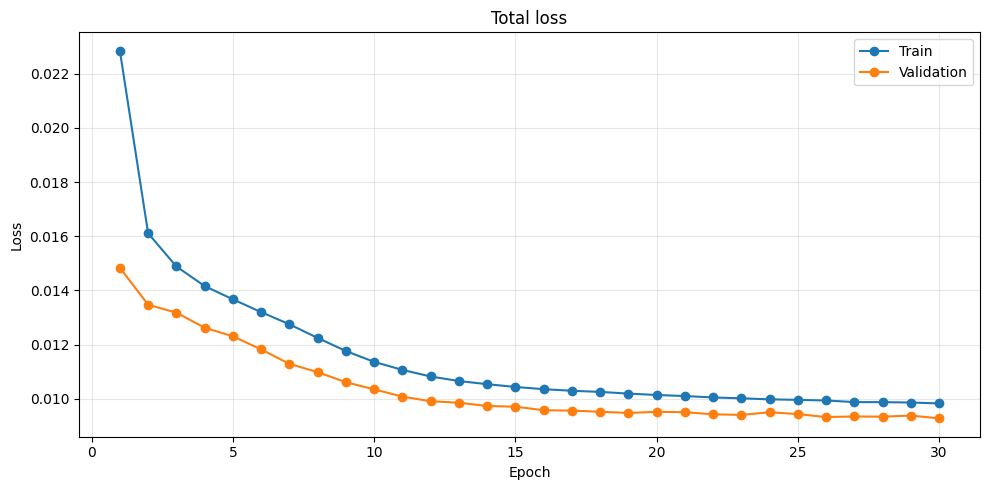

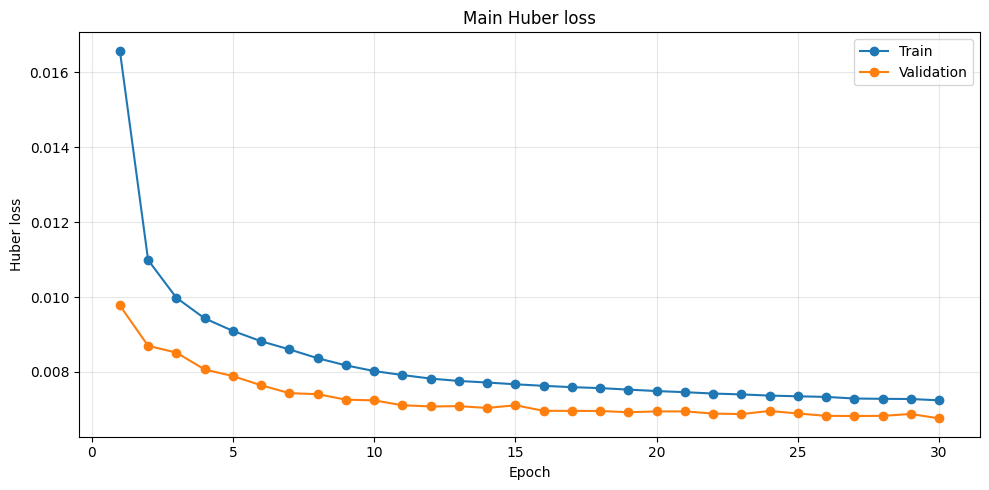

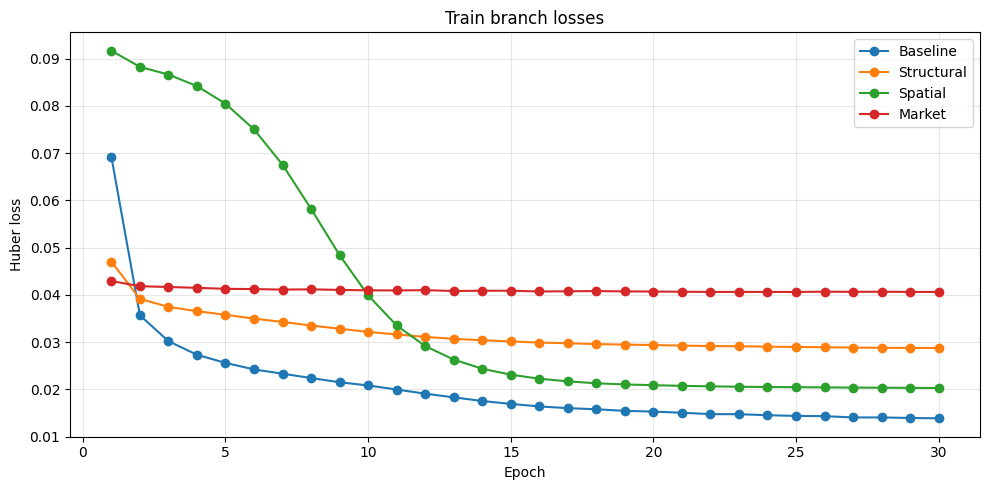

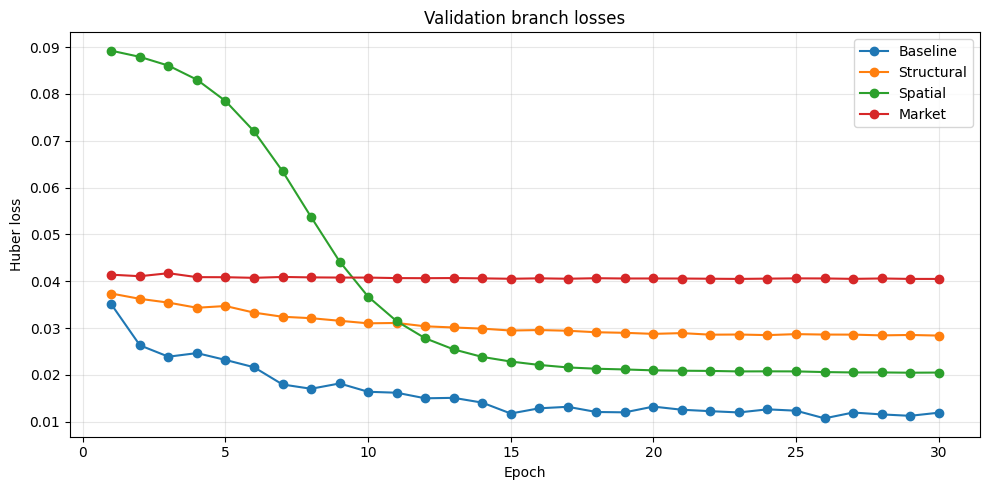

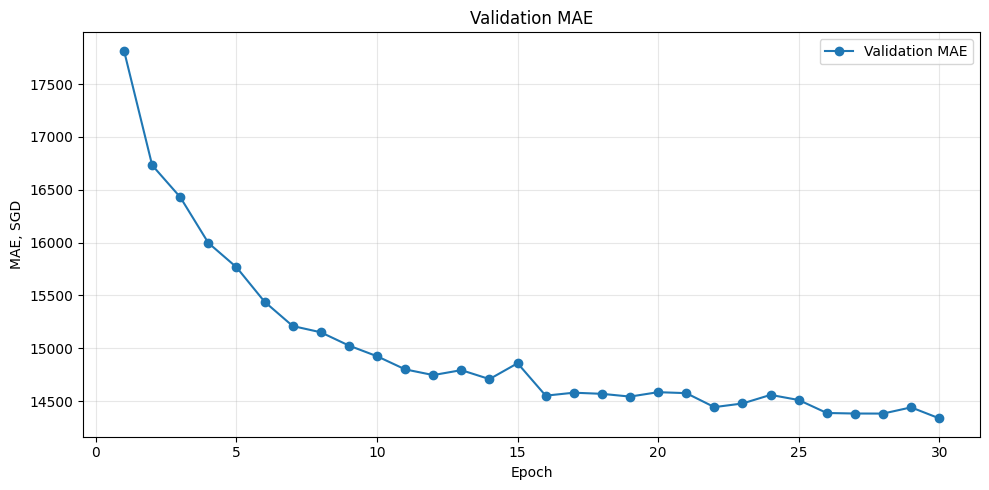

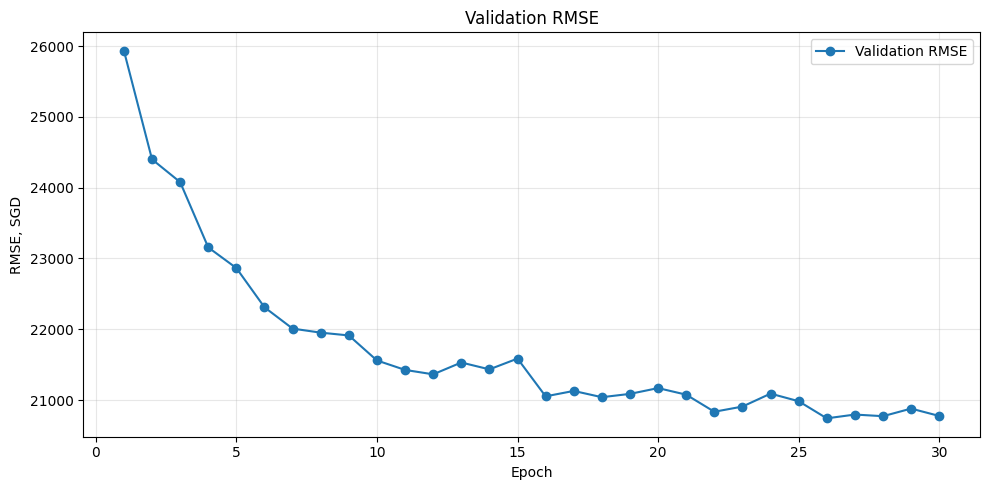

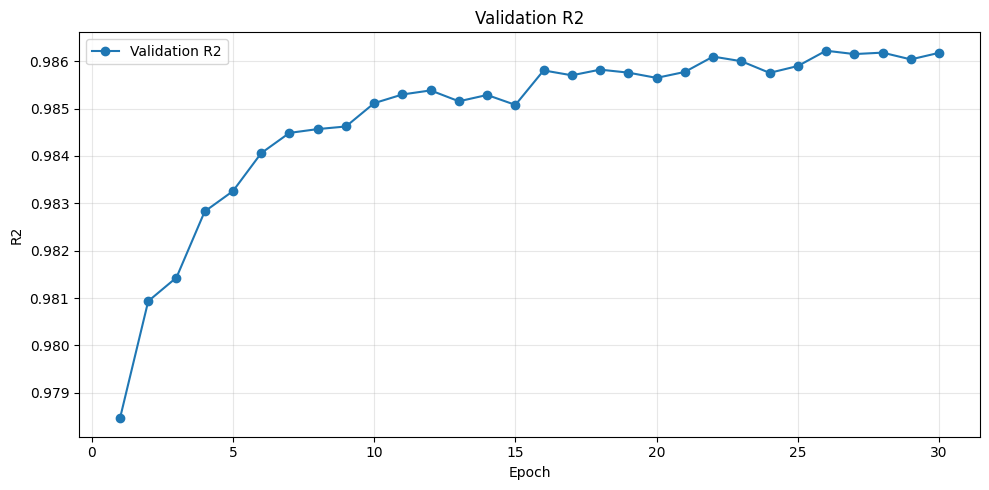

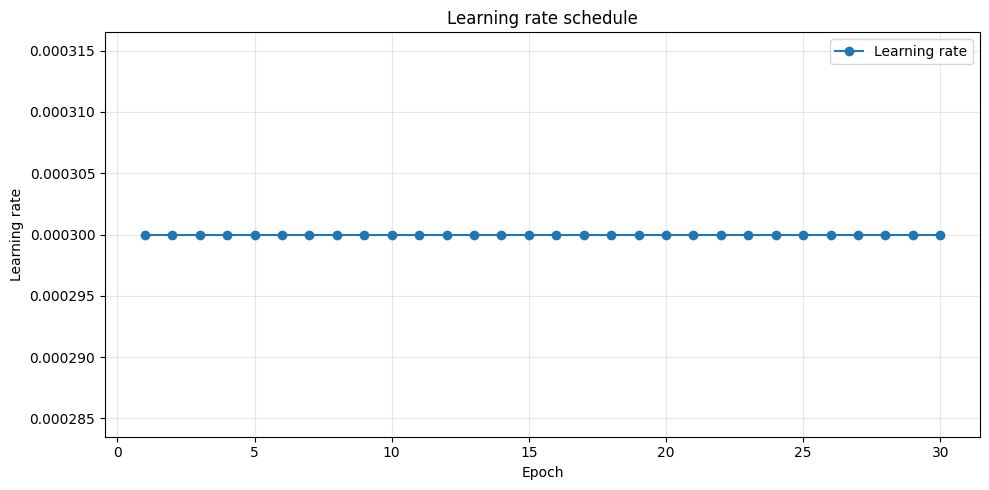

Epoch 30/30 | Train main loss: 0.007241 | Validation main loss: 0.006760 | Validation MAE: 14,337 SGD | Validation RMSE: 20,776 SGD | Validation R2: 0.9862 | LR: 3.00e-04
Best epoch: 30 | Epochs without improvement: 0


In [241]:
fit_output = fit_hdb_compnet(
    model=hdb_compnet_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    target_scaler=target_scaler,
    config=hdb_compnet_config,
    checkpoint_dir=CHECKPOINT_DIR,
    log_transform=LOG_TRANSFORM,
    resume_from=None,
    plot_after_each_epoch=True
)

In [242]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch


RESULTS_DIR = CHECKPOINT_DIR.parent / 'results'

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

hdb_compnet_model = fit_output['model']
training_history = fit_output['training_history']
device = fit_output['device']

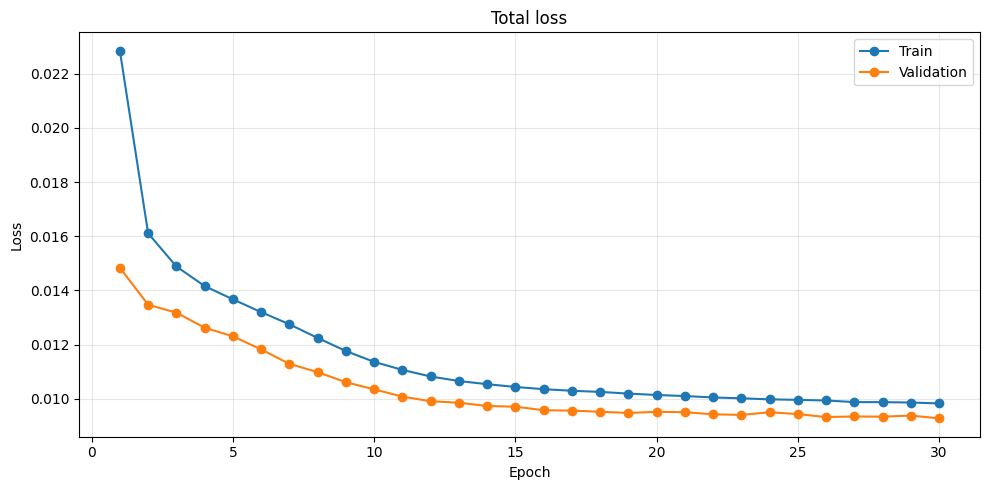

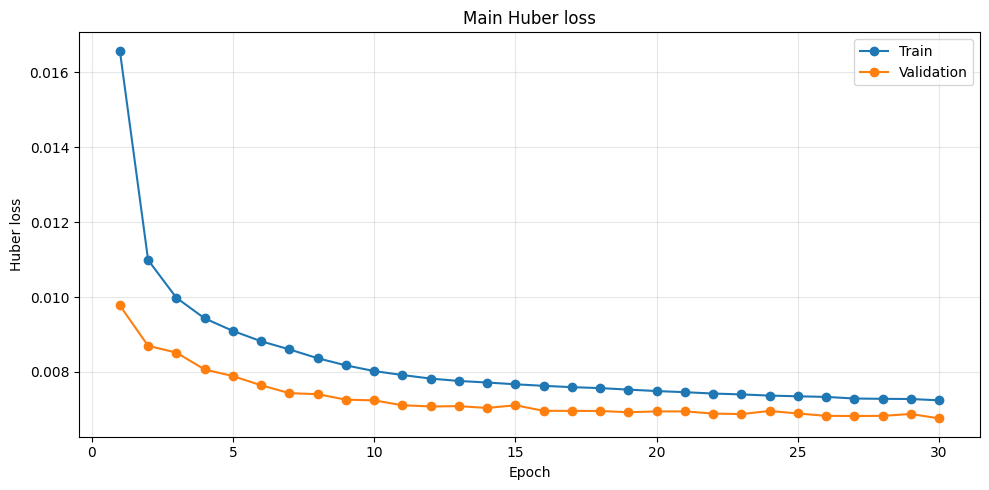

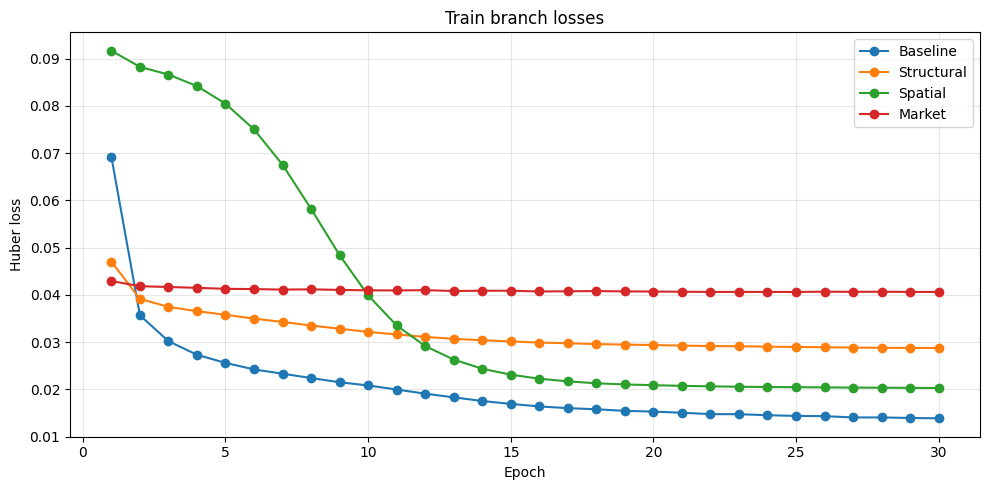

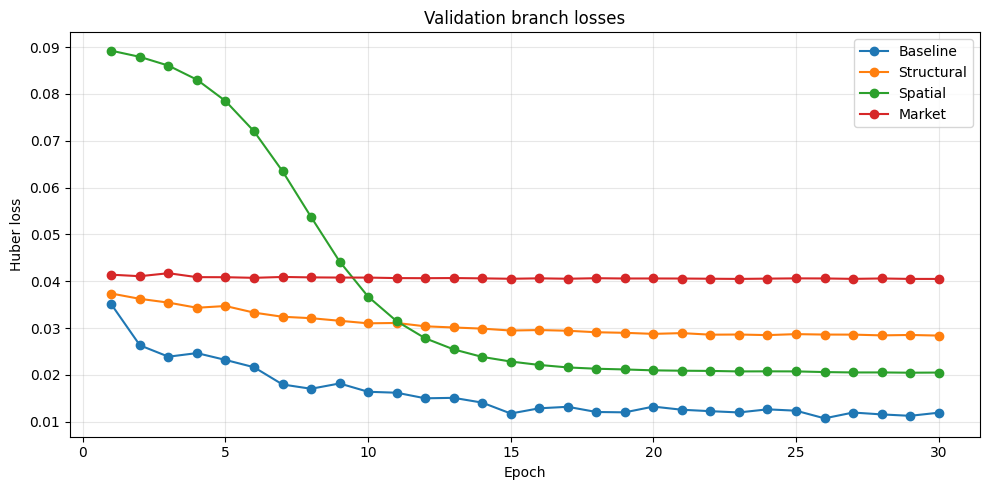

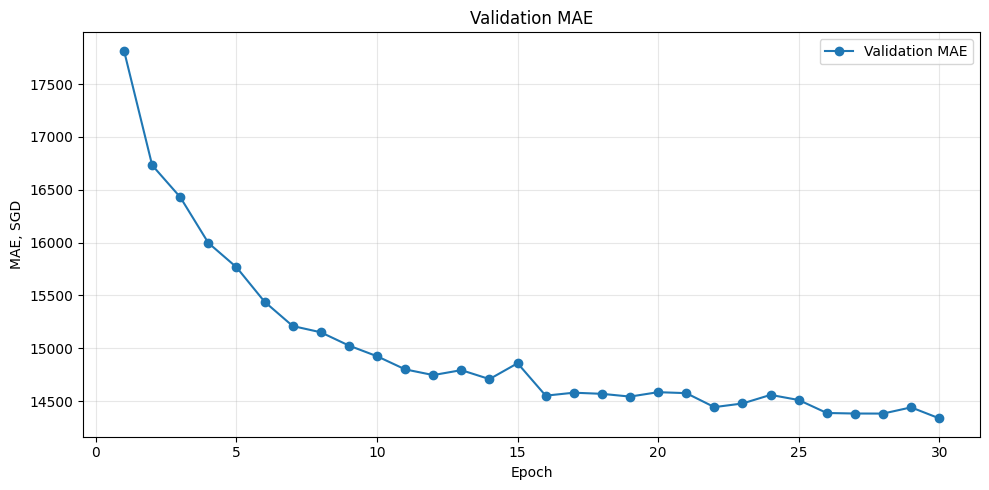

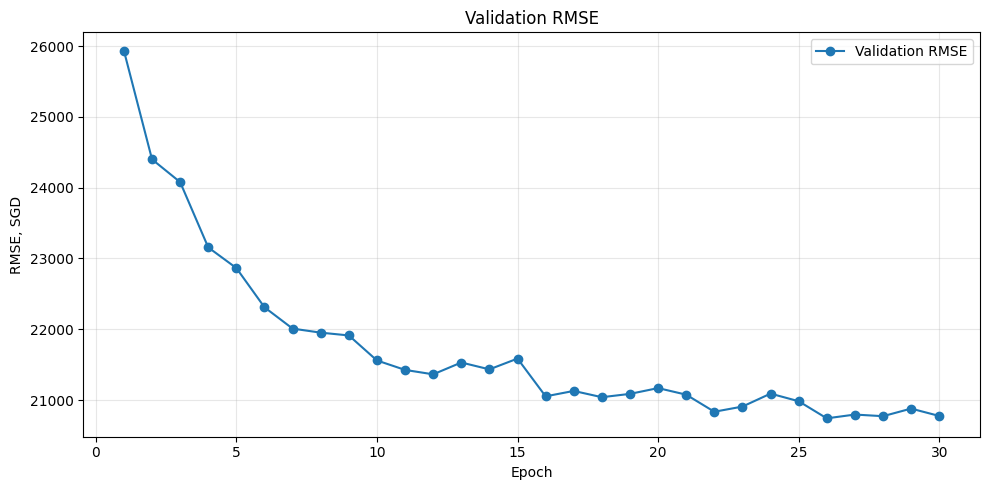

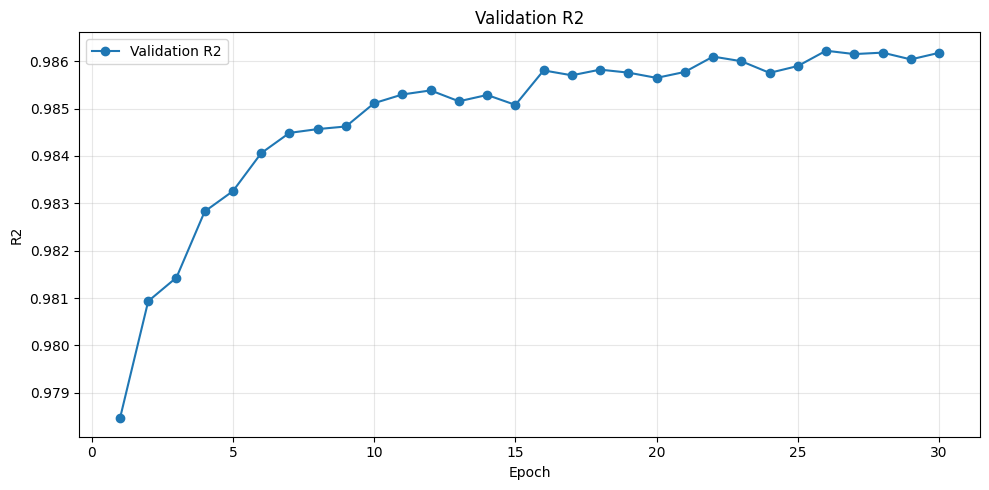

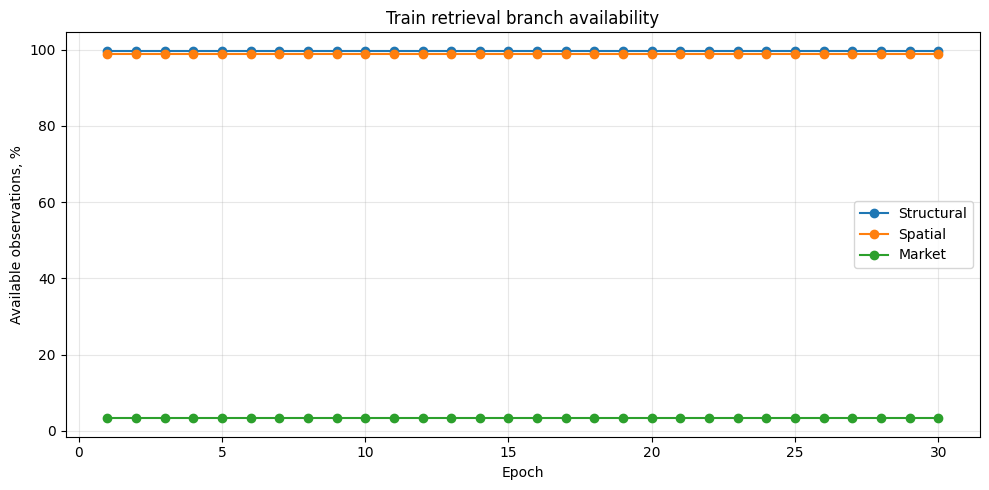

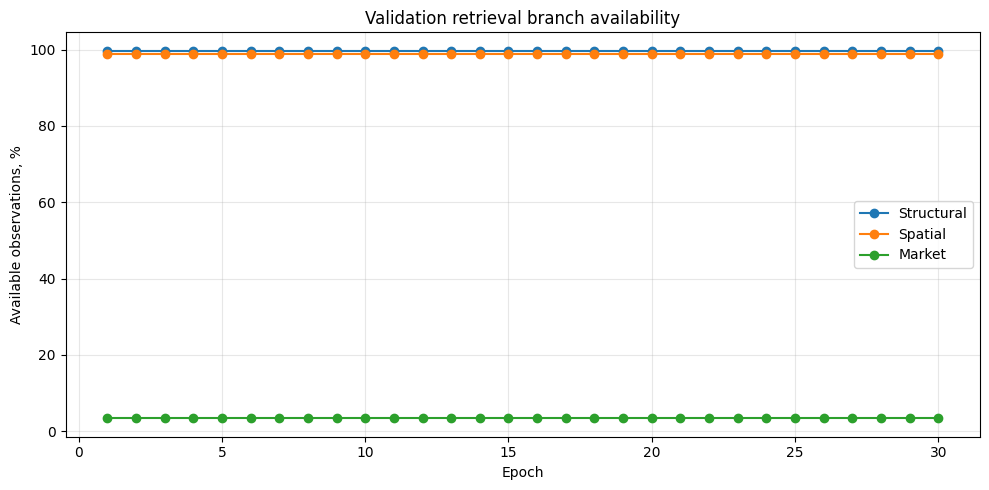

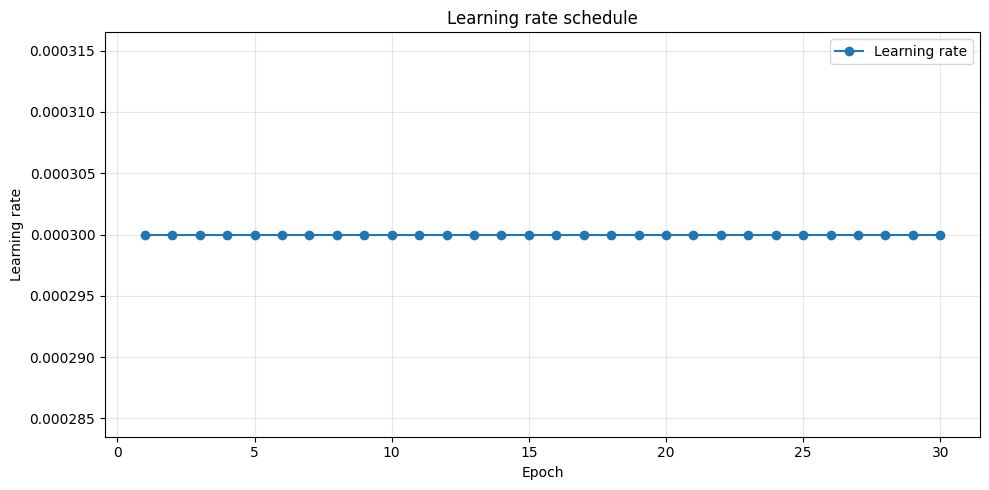

In [243]:
plot_training_progress(
    training_history=training_history,
    clear_previous=False,
    show_availability=True,
    show_learning_rate=True
)

In [291]:
test_statistics = evaluate_hdb_compnet_on_test(
    fit_output=fit_output,
    test_loader=test_loader,
    target_scaler=target_scaler,
    config=hdb_compnet_config,
    log_transform=LOG_TRANSFORM,
    plot_comparison=False
)

In [289]:
test_results = pd.Series(
    {
        'Best epoch': fit_output['best_epoch'],
        'Test total loss': test_statistics['loss'],
        'Test main Huber loss': (
            test_statistics['main_loss']
        ),
        'Test auxiliary loss': (
            test_statistics['auxiliary_loss']
        ),
        'Test scaled MAE': (
            test_statistics[
                'metrics'
            ]['scaled_mae']
        ),
        'Test scaled RMSE': (
            test_statistics[
                'metrics'
            ]['scaled_rmse']
        ),
        'Test log MAE': (
            test_statistics[
                'metrics'
            ]['log_mae']
        ),
        'Test log RMSE': (
            test_statistics[
                'metrics'
            ]['log_rmse']
        ),
        'Test MAE, SGD': (
            test_statistics[
                'metrics'
            ]['price_mae_sgd']
        ),
        'Test RMSE, SGD': (
            test_statistics[
                'metrics'
            ]['price_rmse_sgd']
        ),
        'Test R2': (
            test_statistics[
                'metrics'
            ]['price_r2']
        )
    },
    name='HDB-CompNet test results'
)

test_results

,HDB-CompNet test results
Best epoch,30.000000
Test total loss,0.009214
Test main Huber loss,0.006705
Test auxiliary loss,0.025091
Test scaled MAE,0.085328
Test scaled RMSE,0.115807
Test log MAE,0.041762
Test log RMSE,0.056679
"Test MAE, SGD",14213.816079
"Test RMSE, SGD",20574.811399


In [246]:
test_branch_results = pd.DataFrame(
    {
        'Huber loss': (
            test_statistics[
                'branch_losses'
            ]
        ),
        'Availability, %': {
            branch_name: availability * 100
            for branch_name, availability
            in test_statistics[
                'branch_availability'
            ].items()
        }
    }
)

test_branch_results

,Huber loss,"Availability, %"
baseline,0.011929,100.000000
structural,0.027885,99.703662
spatial,0.020387,98.886556
market,0.040406,3.344390


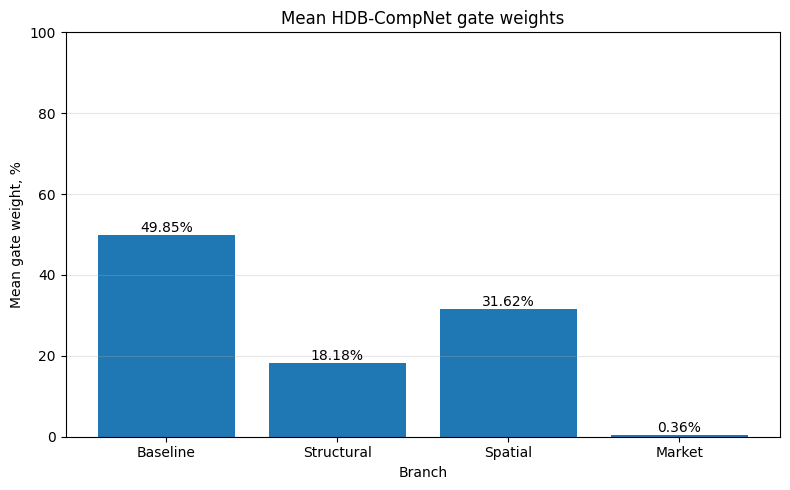

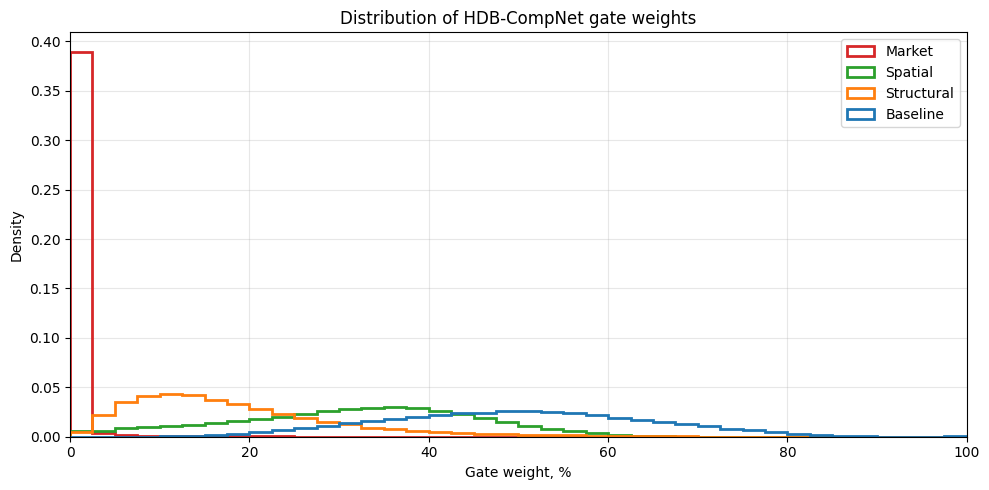

,0
Baseline,49.848007
Structural,18.178644
Spatial,31.616035
Market,0.357317


In [248]:
mean_gate_weights = plot_gate_weight_analysis(
    interpretation_df=interpretation_df,
    config=hdb_compnet_config
)

mean_gate_weights

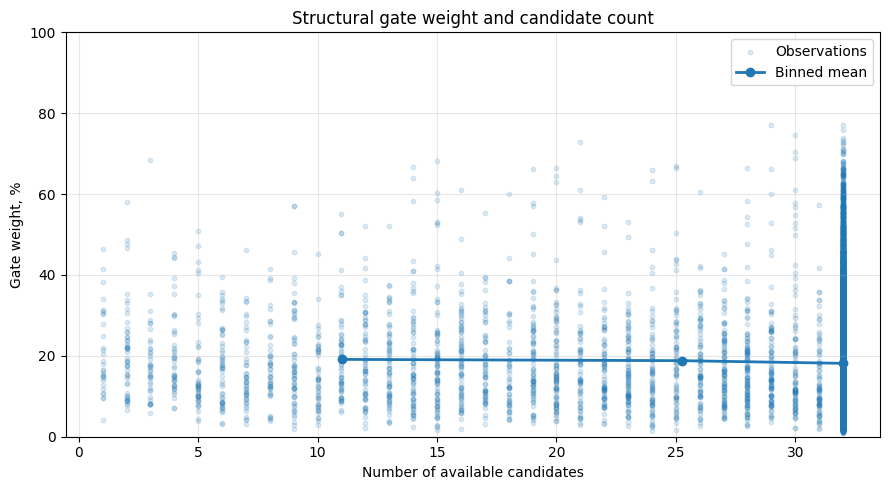

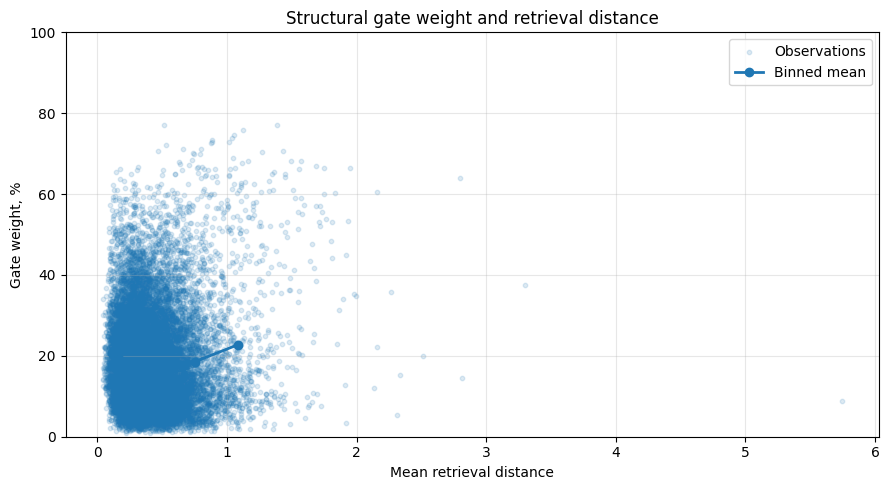

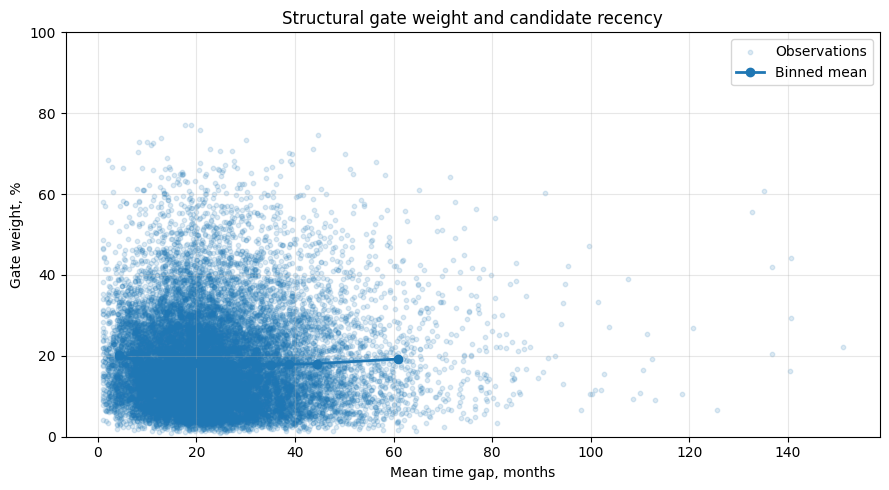

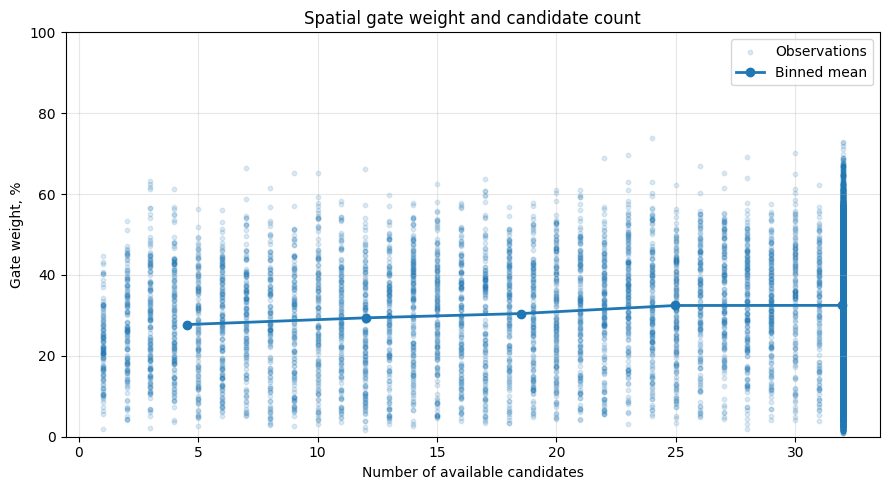

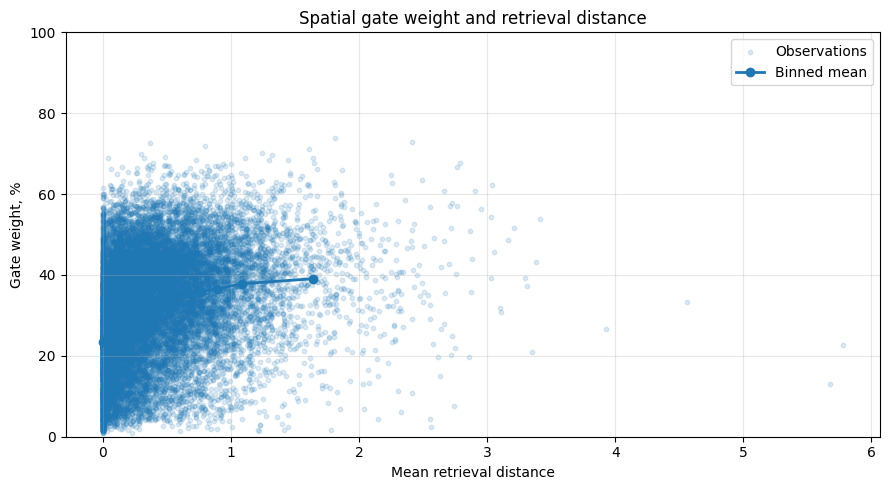

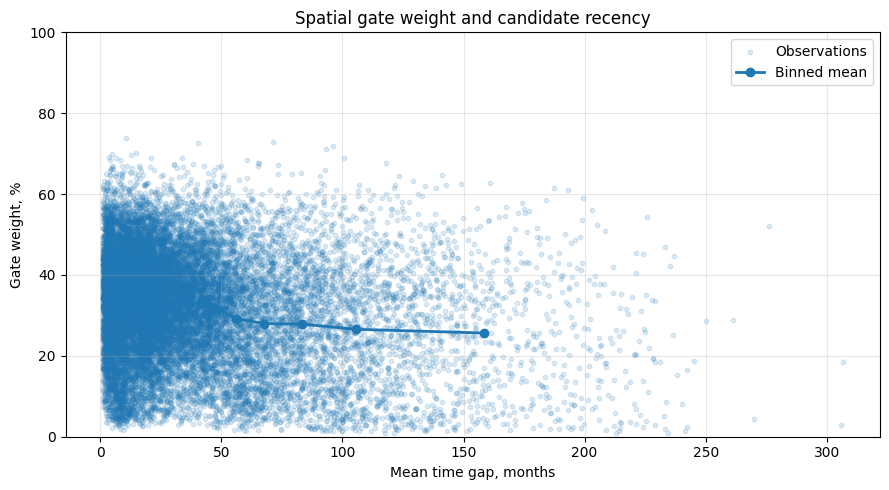

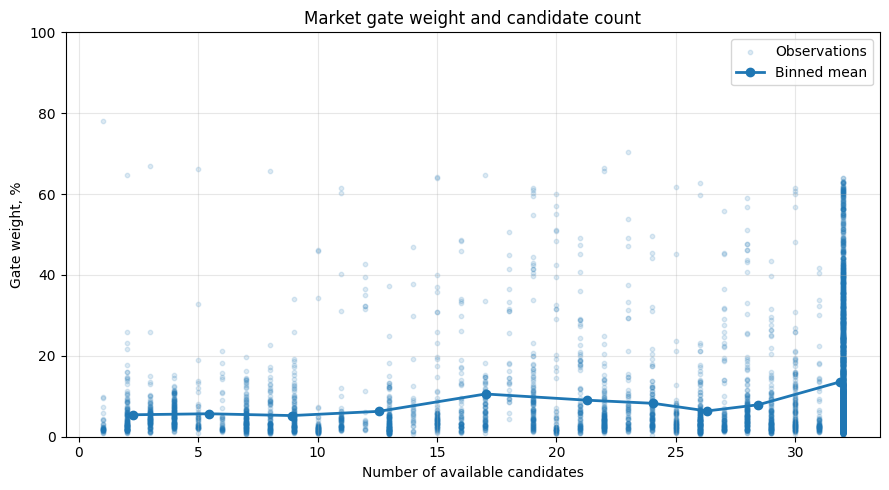

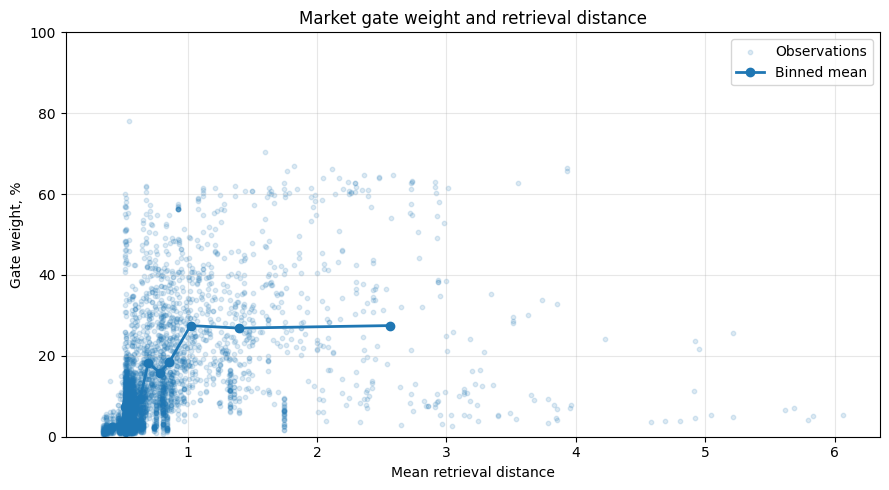

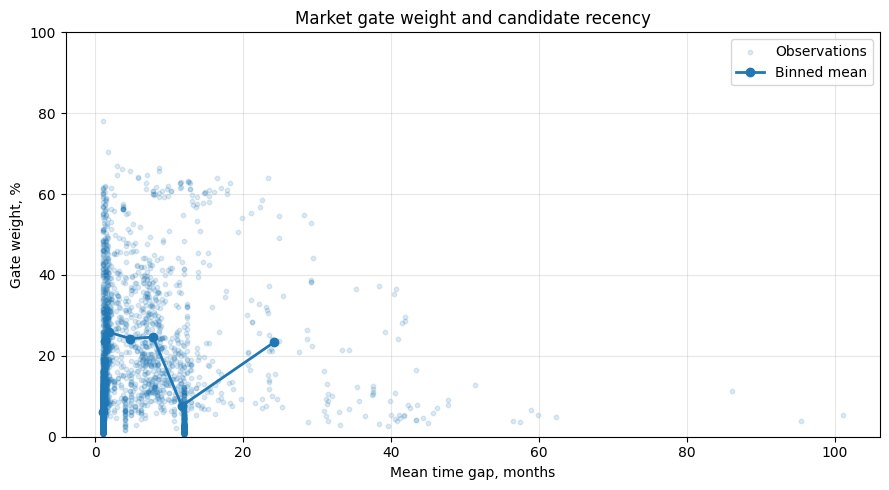

In [249]:
retrieval_relationship_trends = (
    plot_retrieval_branch_analysis(
        interpretation_df=interpretation_df,
        config=hdb_compnet_config,
        max_points=20000,
        trend_bins=20,
        random_state=hdb_compnet_config.seed
    )
)

In [250]:
target_shap_results = calculate_target_shap_analysis(
    model=hdb_compnet_model,
    train_split_data=train_split_data,
    explanation_loader=test_loader,
    device=device,
    config=hdb_compnet_config,
    numeric_background_size=128,
    numeric_examples=500,
    categorical_examples=200,
    numeric_n_samples=50,
    categorical_n_samples=128,
    categorical_perturbations_per_eval=8,
    random_state=hdb_compnet_config.seed
)

In [251]:
target_shap_importance = target_shap_results[
    'combined_importance'
]

target_shap_importance

,feature,feature_type,mean_abs_shap,mean_shap,importance_share_pct
0,floor_area_sqm,numeric,0.259578,-0.027981,12.609657
1,cpi_all_items,numeric,0.217133,0.017131,10.547772
2,household_net_worth,numeric,0.164963,0.014816,8.013494
3,resident_households_hdb,numeric,0.101935,-0.010249,4.951762
4,per_capita_gdp_real,numeric,0.081186,-0.000668,3.943837
...,...,...,...,...,...
56,commercial,numeric,0.002957,0.000210,0.143627
57,miscellaneous,numeric,0.001919,0.000033,0.093212
58,precinct_pavilion,numeric,0.000025,0.000025,0.001211
59,multistorey_carpark,numeric,0.000000,0.000000,0.000000


In [253]:
target_shap_importance.head(10)

,feature,feature_type,mean_abs_shap,mean_shap,importance_share_pct
0,floor_area_sqm,numeric,0.259578,-0.027981,12.609657
1,cpi_all_items,numeric,0.217133,0.017131,10.547772
2,household_net_worth,numeric,0.164963,0.014816,8.013494
3,resident_households_hdb,numeric,0.101935,-0.010249,4.951762
4,per_capita_gdp_real,numeric,0.081186,-0.000668,3.943837
5,month_index,numeric,0.080635,-0.007722,3.917048
6,remaining_lease_full_years,numeric,0.063971,-0.006839,3.107540
7,flat_type,categorical,0.056699,0.020458,2.754316
8,year_completed,numeric,0.056481,-0.013083,2.743718
9,hdb_housing_msr,numeric,0.056406,-0.001238,2.740089


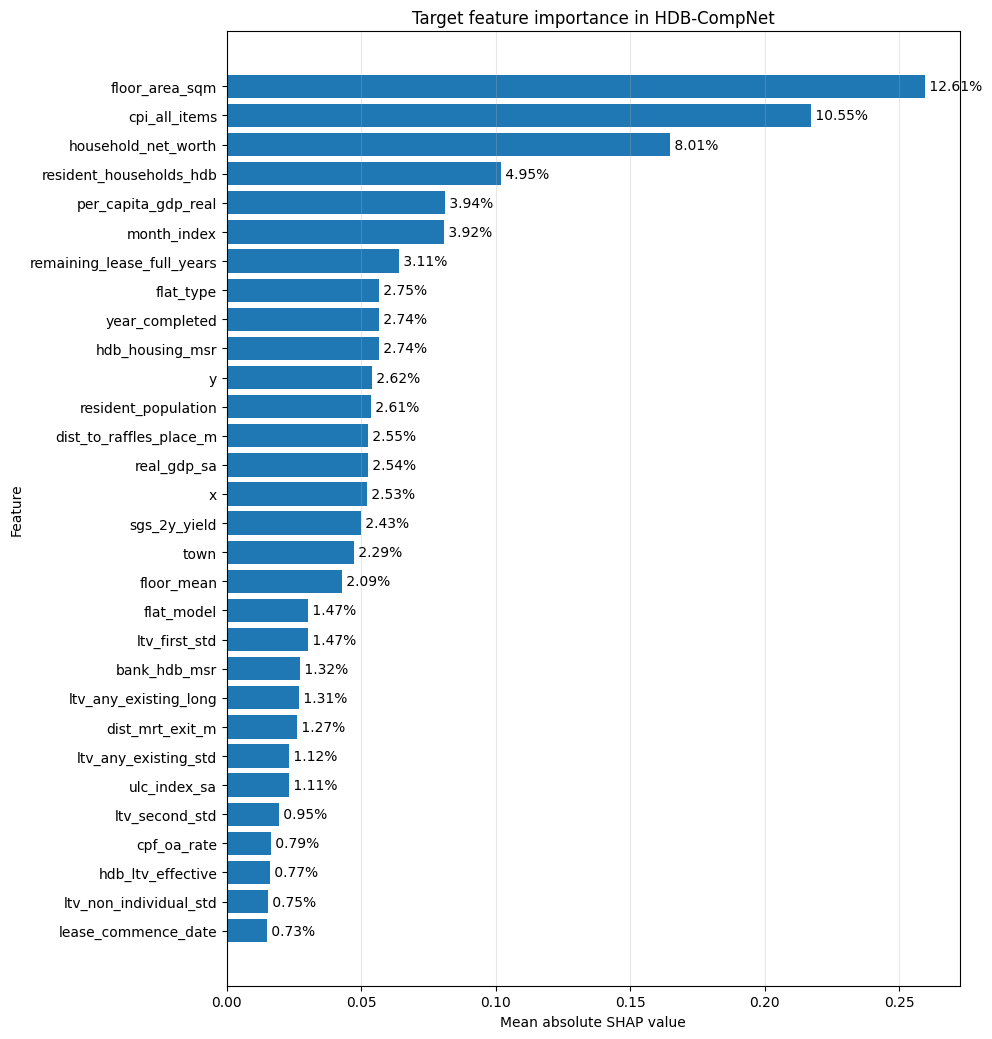

In [252]:
plot_target_shap_importance(
    importance=target_shap_importance,
    top_n=30
)

In [255]:
numeric_shap_importance = target_shap_results[
    'numeric'
]['importance']

numeric_shap_importance.head(15)

,feature,feature_type,mean_abs_shap,mean_shap
0,floor_area_sqm,numeric,0.259578,-0.027981
1,cpi_all_items,numeric,0.217133,0.017131
2,household_net_worth,numeric,0.164963,0.014816
3,resident_households_hdb,numeric,0.101935,-0.010249
4,per_capita_gdp_real,numeric,0.081186,-0.000668
5,month_index,numeric,0.080635,-0.007722
6,remaining_lease_full_years,numeric,0.063971,-0.006839
7,year_completed,numeric,0.056481,-0.013083
8,hdb_housing_msr,numeric,0.056406,-0.001238
9,y,numeric,0.053898,0.004137


In [256]:
categorical_shap_importance = target_shap_results['categorical']['importance']

categorical_shap_importance

,feature,feature_type,mean_abs_shap,mean_shap
0,flat_type,categorical,0.056699,0.020458
1,town,categorical,0.047184,0.025982
2,flat_model,categorical,0.030240,-0.010126
3,nearest_hospital_type,categorical,0.009810,-0.004857
4,nearest_hospital_category,categorical,0.008156,-0.000666


# Эксперимент 2

In [261]:
experiment_1_fit_output = fit_output
experiment_1_test_statistics = test_statistics

In [262]:
from dataclasses import replace
from pathlib import Path

import random

import numpy as np
import pandas as pd
import torch


EXPERIMENT_2_NAME = 'hdb_compnet_lower_lr_longer_training'

EXPERIMENT_2_DIR = (
    PROJECT_DIR
    / 'experiments'
    / EXPERIMENT_2_NAME
)

EXPERIMENT_2_CHECKPOINT_DIR = (
    EXPERIMENT_2_DIR
    / 'checkpoints'
)

EXPERIMENT_2_RESULTS_DIR = (
    EXPERIMENT_2_DIR
    / 'results'
)

EXPERIMENT_2_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EXPERIMENT_2_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [263]:
experiment_2_config = replace(
    hdb_compnet_config,
    max_epochs=60,
    learning_rate=(
        hdb_compnet_config.learning_rate
        * 0.5
    ),
    min_learning_rate=(
        hdb_compnet_config.min_learning_rate
        * 0.5
    ),
    weight_decay=(
        hdb_compnet_config.weight_decay
        * 0.5
    ),
    dropout=max(
        0.05,
        hdb_compnet_config.dropout * 0.75
    ),
    auxiliary_loss_weight=0.05,
    scheduler_patience=max(
        4,
        hdb_compnet_config.scheduler_patience
    ),
    early_stopping_patience=max(
        12,
        hdb_compnet_config.early_stopping_patience
    )
)

In [264]:
random.seed(
    experiment_2_config.seed
)

np.random.seed(
    experiment_2_config.seed
)

torch.manual_seed(
    experiment_2_config.seed
)

torch.cuda.manual_seed_all(
    experiment_2_config.seed
)

In [265]:
experiment_2_model = HDBCompNet(
    experiment_2_config
)

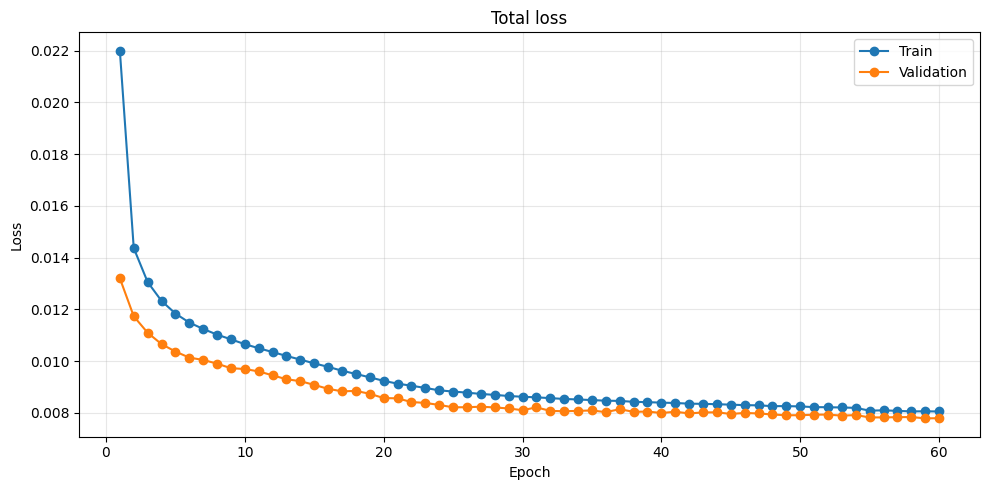

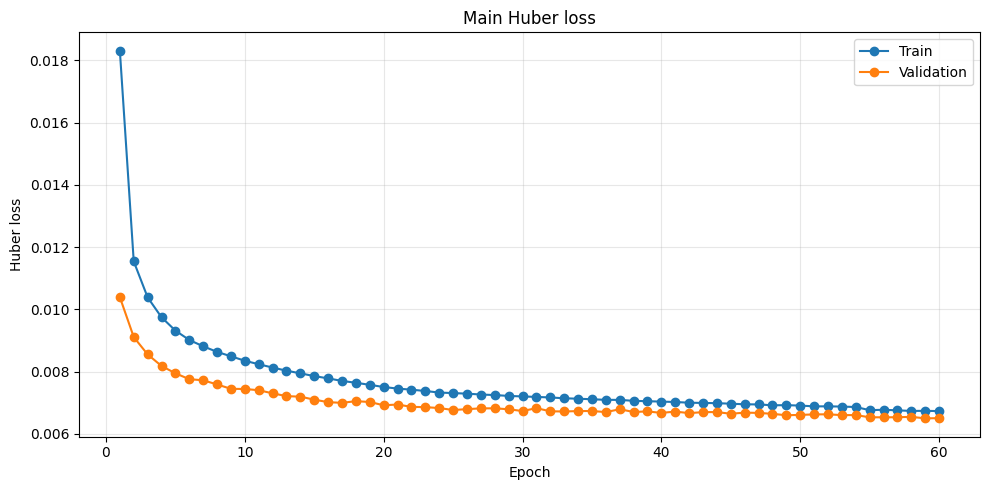

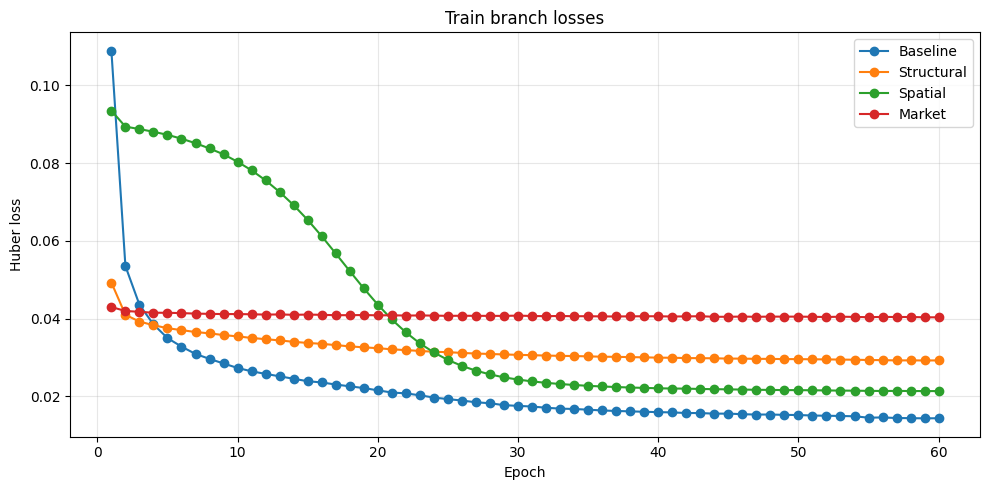

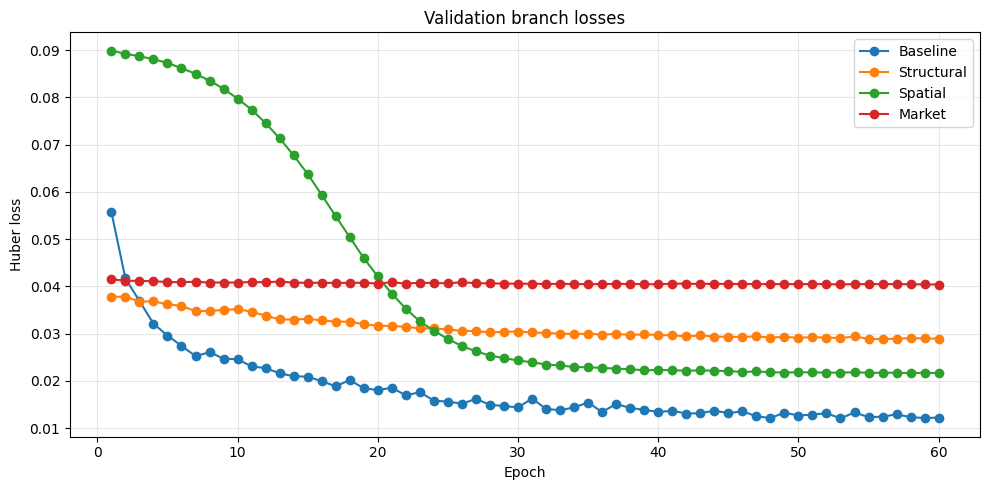

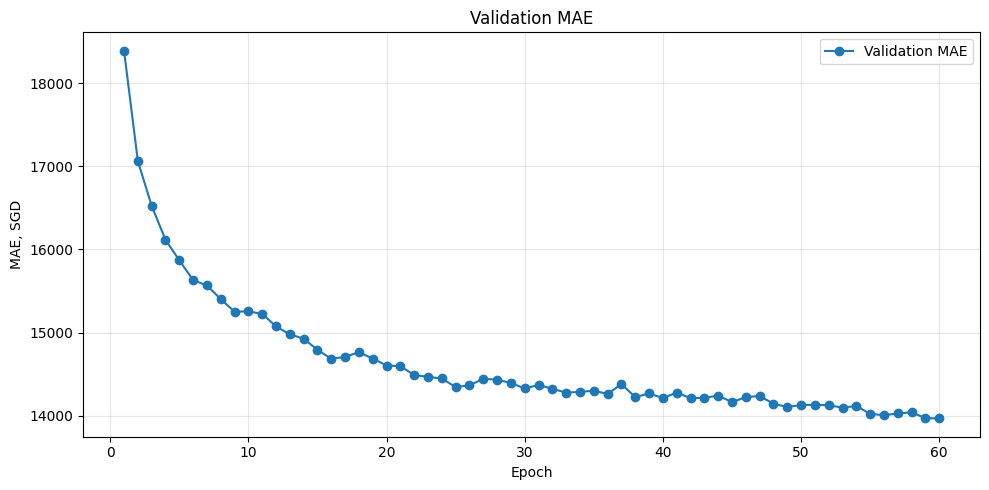

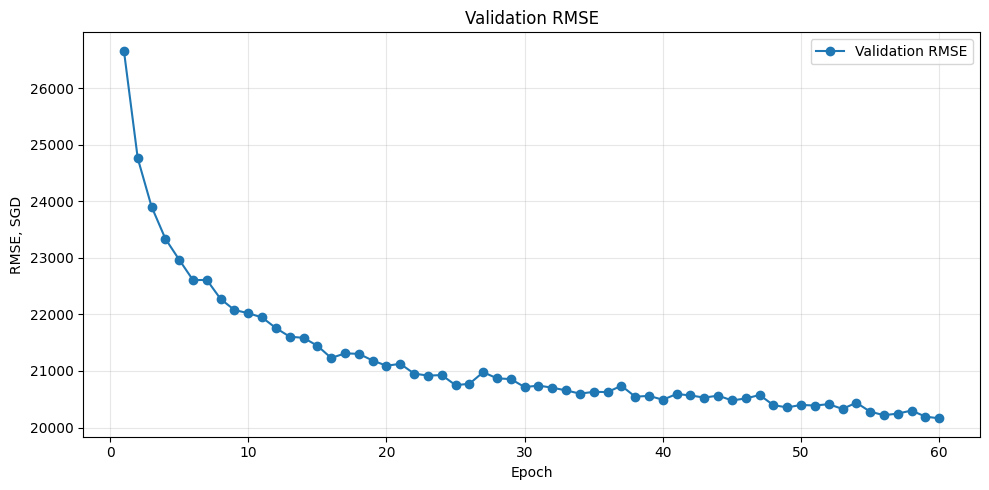

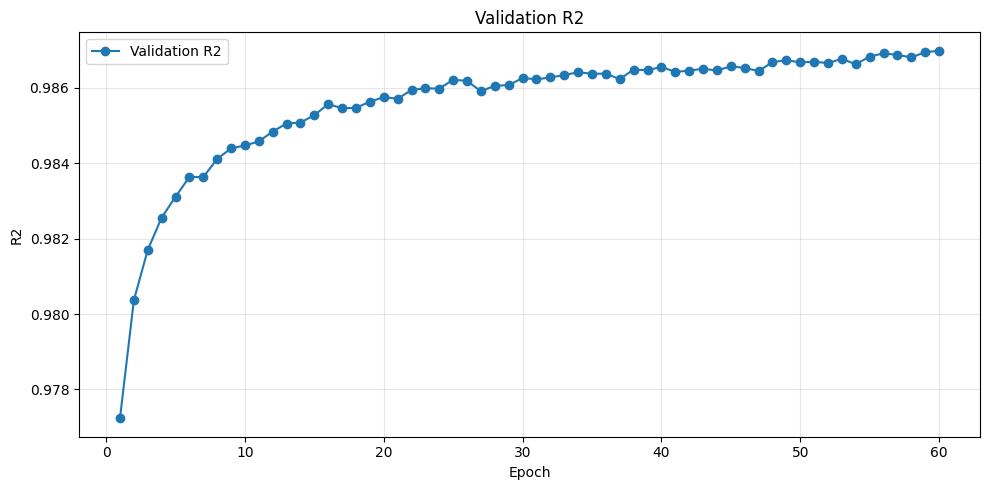

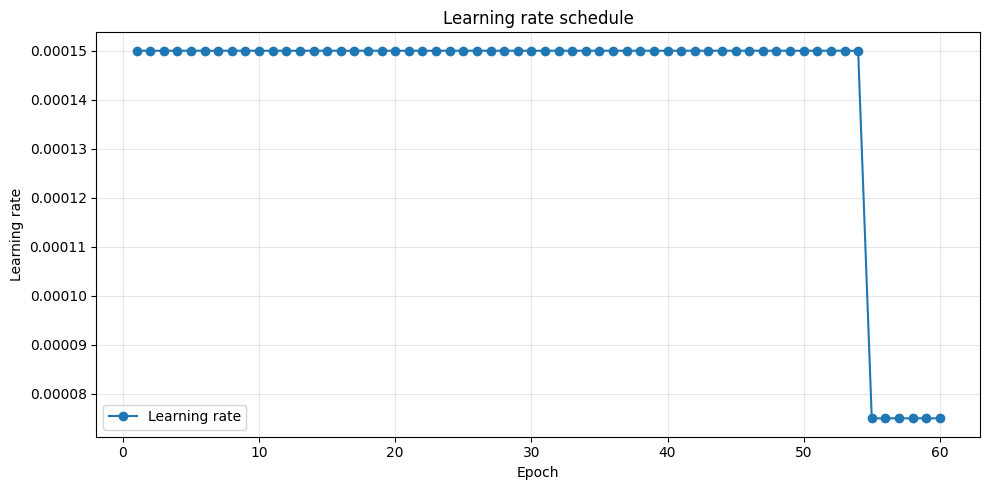

Epoch 60/60 | Train main loss: 0.006733 | Validation main loss: 0.006505 | Validation MAE: 13,968 SGD | Validation RMSE: 20,163 SGD | Validation R2: 0.9870 | LR: 7.50e-05
Best epoch: 59 | Epochs without improvement: 1


In [266]:
experiment_2_fit_output = fit_hdb_compnet(
    model=experiment_2_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    target_scaler=target_scaler,
    config=experiment_2_config,
    checkpoint_dir=(
        EXPERIMENT_2_CHECKPOINT_DIR
    ),
    log_transform=LOG_TRANSFORM,
    resume_from=None,
    plot_after_each_epoch=True
)

In [267]:
from pathlib import Path

import numpy as np
import pandas as pd


EXPERIMENT_2_RESULTS_DIR = (
    PROJECT_DIR
    / 'experiments'
    / 'hdb_compnet_lower_lr_longer_training'
    / 'results'
)

EXPERIMENT_2_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

experiment_2_model = experiment_2_fit_output['model']

experiment_2_training_history = (
    experiment_2_fit_output['training_history']
)

experiment_2_device = experiment_2_fit_output['device']

experiment_2_checkpoint_manager = (
    experiment_2_fit_output['checkpoint_manager']
)

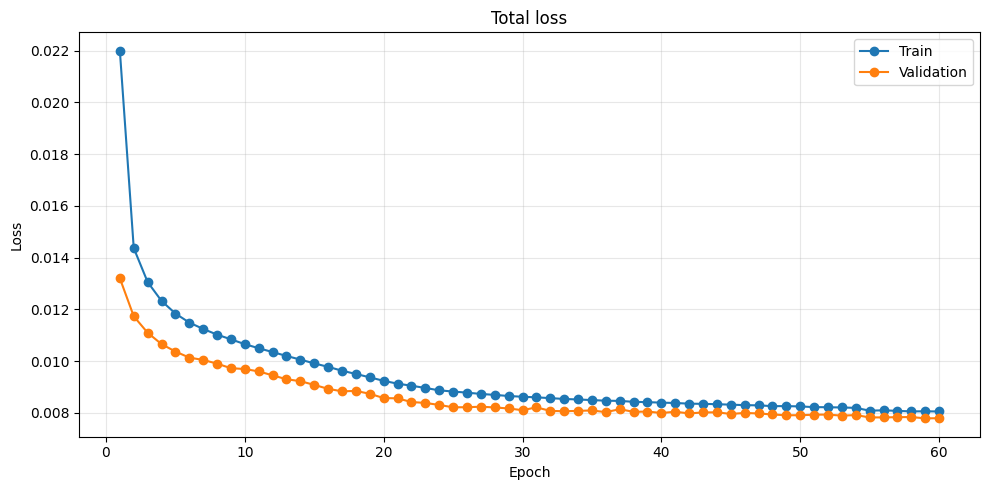

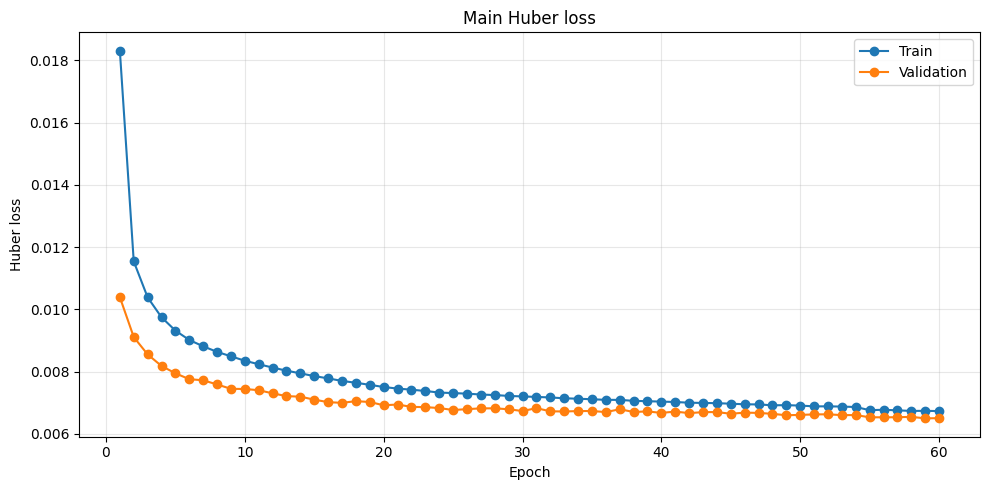

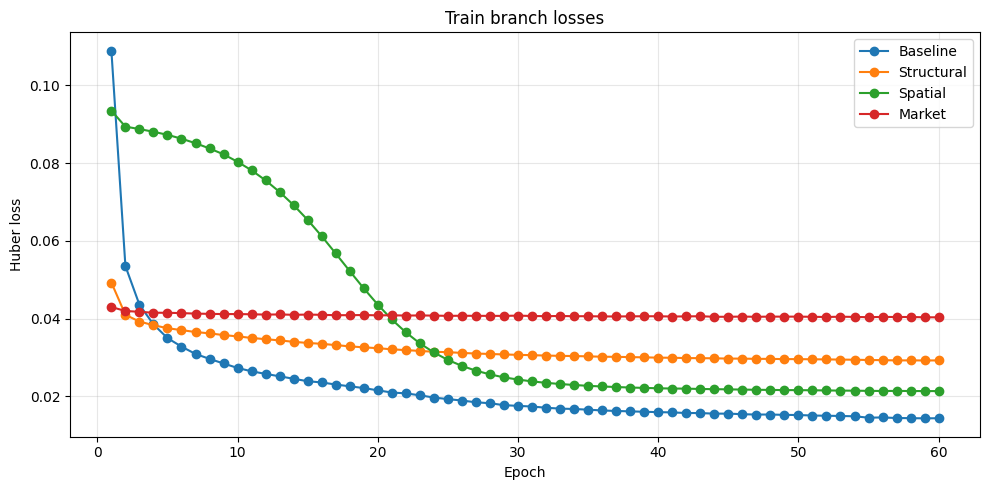

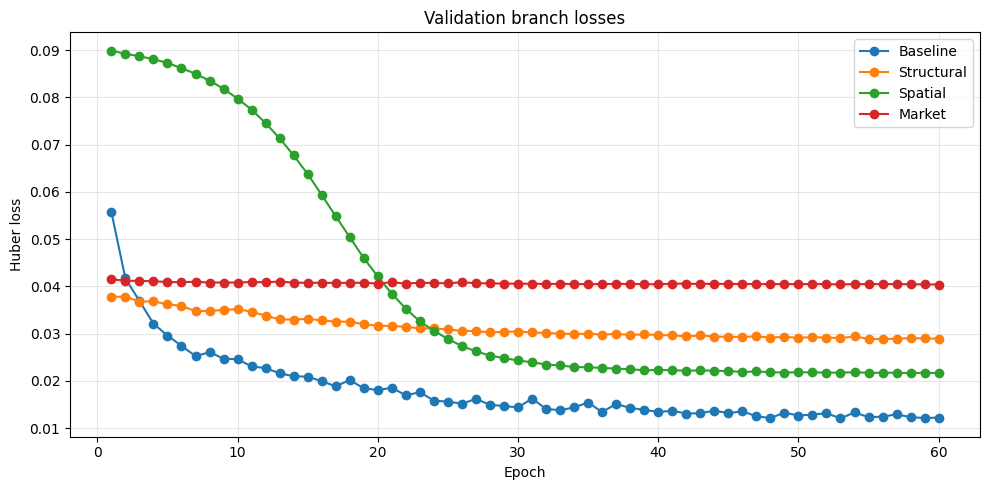

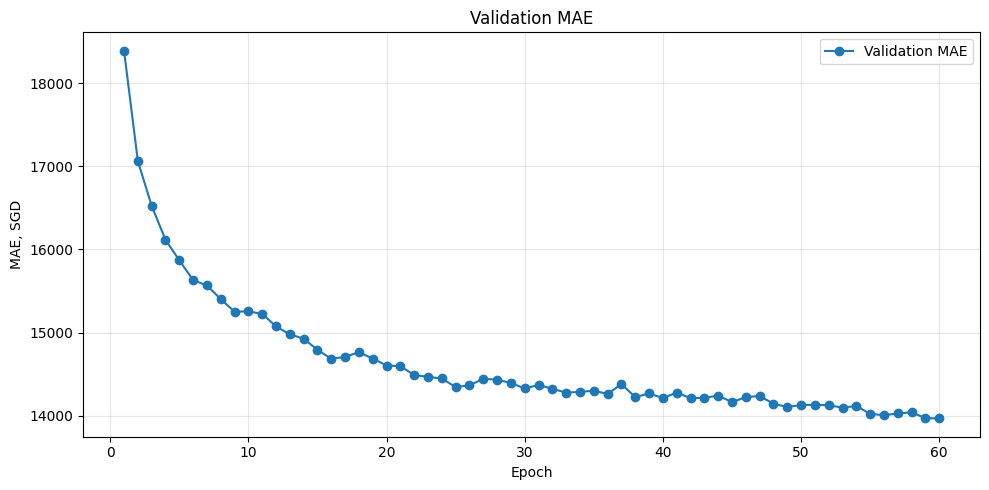

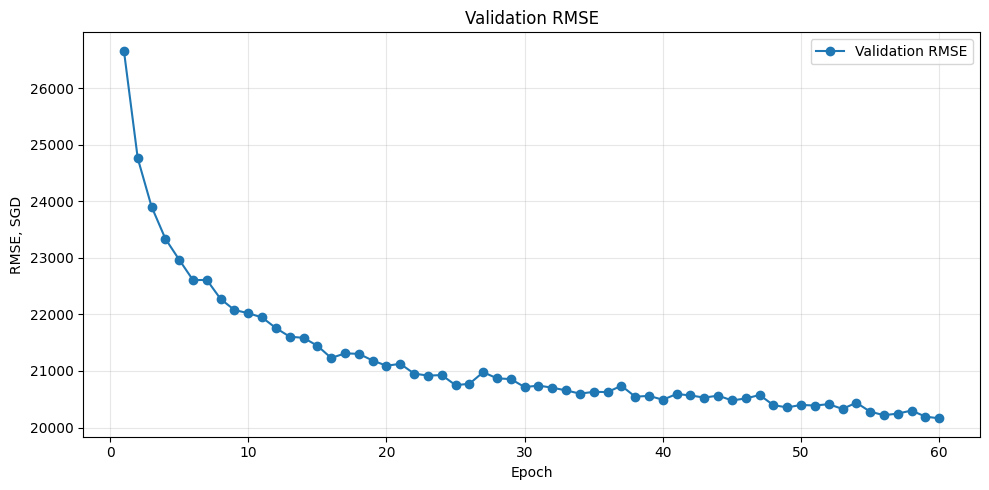

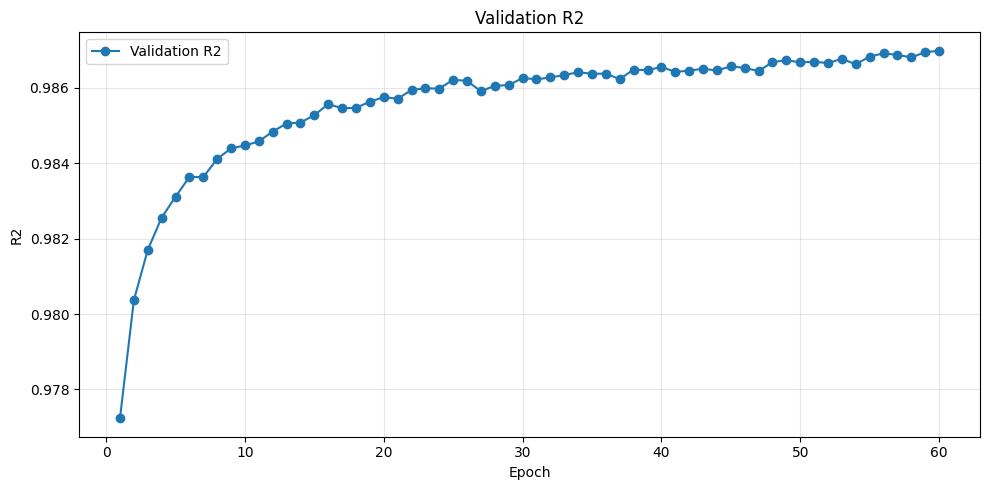

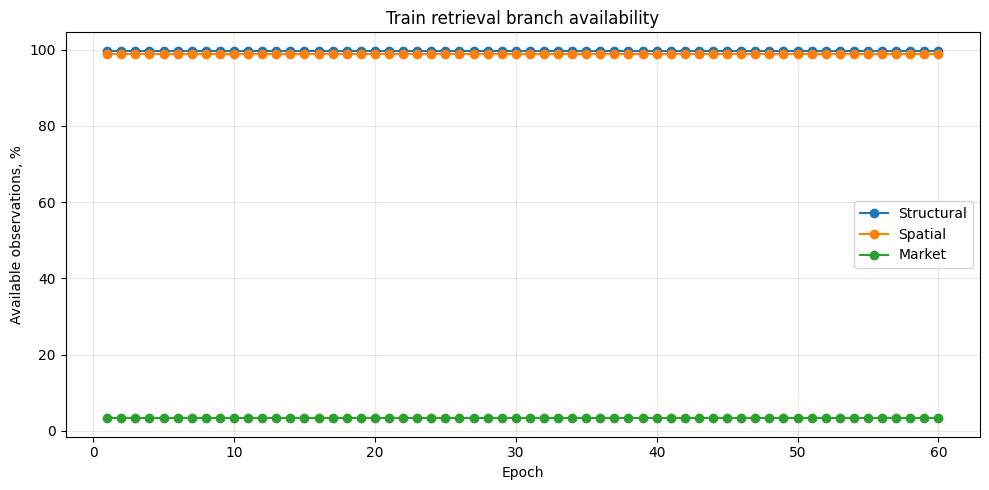

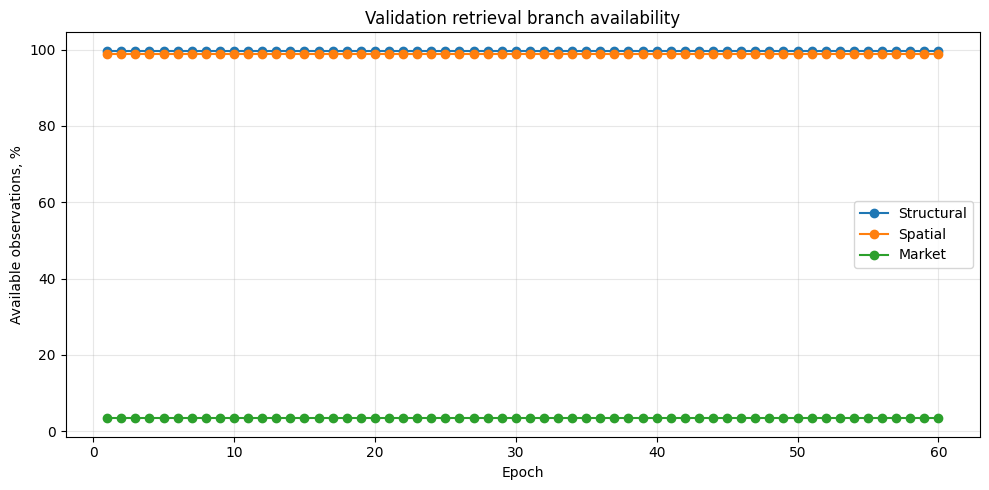

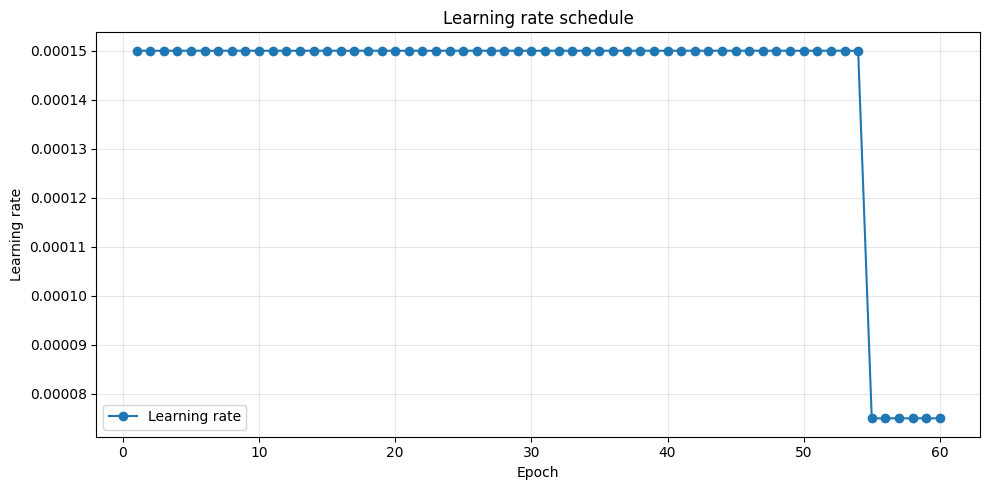

In [268]:
plot_training_progress(
    training_history=experiment_2_training_history,
    clear_previous=False,
    show_availability=True,
    show_learning_rate=True
)

In [290]:
experiment_2_test_statistics = (
    evaluate_hdb_compnet_on_test(
        fit_output=experiment_2_fit_output,
        test_loader=test_loader,
        target_scaler=target_scaler,
        config=experiment_2_config,
        log_transform=LOG_TRANSFORM,
        plot_comparison=False
    )
)

In [294]:
experiment_2_test_results = pd.Series(
    {
        'Best epoch': (
            experiment_2_fit_output['best_epoch']
        ),
        'Test total loss': (
            experiment_2_test_statistics['loss']
        ),
        'Test main Huber loss': (
            experiment_2_test_statistics['main_loss']
        ),
        'Test auxiliary loss': (
            experiment_2_test_statistics[
                'auxiliary_loss'
            ]
        ),
        'Test scaled MAE': (
            experiment_2_test_statistics[
                'metrics'
            ]['scaled_mae']
        ),
        'Test scaled RMSE': (
            experiment_2_test_statistics[
                'metrics'
            ]['scaled_rmse']
        ),
        'Test log MAE': (
            experiment_2_test_statistics[
                'metrics'
            ]['log_mae']
        ),
        'Test log RMSE': (
            experiment_2_test_statistics[
                'metrics'
            ]['log_rmse']
        ),
        'Test MAE, SGD': (
            experiment_2_test_statistics[
                'metrics'
            ]['price_mae_sgd']
        ),
        'Test RMSE, SGD': (
            experiment_2_test_statistics[
                'metrics'
            ]['price_rmse_sgd']
        ),
        'Test R2': (
            experiment_2_test_statistics[
                'metrics'
            ]['price_r2']
        )
    },
    name='HDB-CompNet experiment 2 test results'
)

experiment_2_test_results

,Estimated HDB-CompNet test results
Test total loss,0.007519
Test main Huber loss,0.006273
Test auxiliary loss,0.024911
Test scaled MAE,0.082344
Test scaled RMSE,0.112015
Test log MAE,0.040302
Test log RMSE,0.054823
"Test MAE, SGD",13674.619243
"Test RMSE, SGD",19748.268206
Test R2,0.987295


In [271]:
experiment_2_branch_results = pd.DataFrame(
    {
        'Huber loss': (
            experiment_2_test_statistics[
                'branch_losses'
            ]
        ),
        'Availability, %': {
            branch_name: availability * 100
            for branch_name, availability
            in experiment_2_test_statistics[
                'branch_availability'
            ].items()
        }
    }
)

experiment_2_branch_results

,Huber loss,"Availability, %"
baseline,0.012171,100.000000
structural,0.028350,99.703662
spatial,0.021589,98.886556
market,0.040491,3.344390


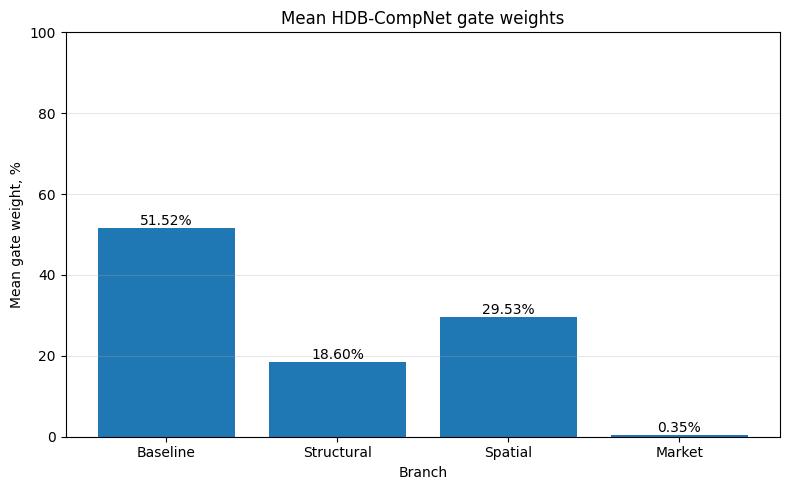

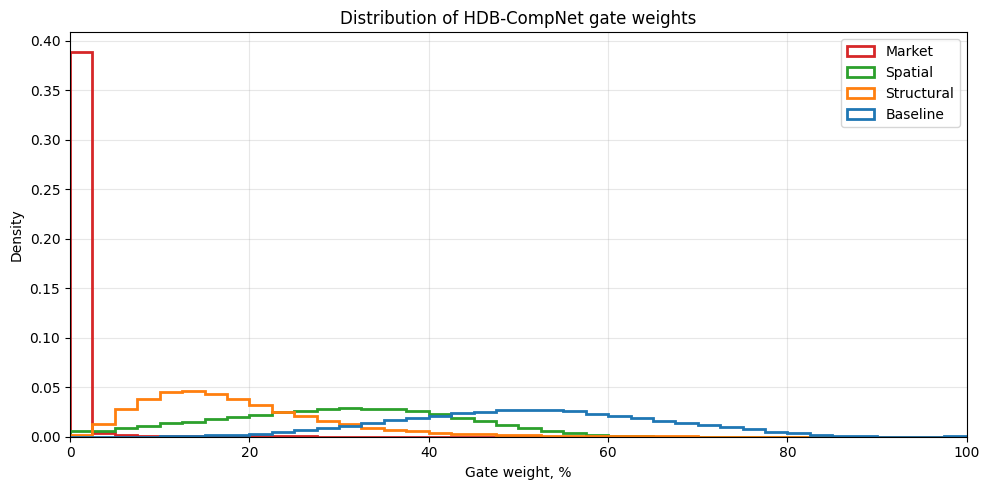

,0
Baseline,51.524925
Structural,18.595671
Spatial,29.533392
Market,0.345974


In [273]:
experiment_2_mean_gate_weights = (
    plot_gate_weight_analysis(
        interpretation_df=(
            experiment_2_interpretation_df
        ),
        config=experiment_2_config
    )
)

experiment_2_mean_gate_weights

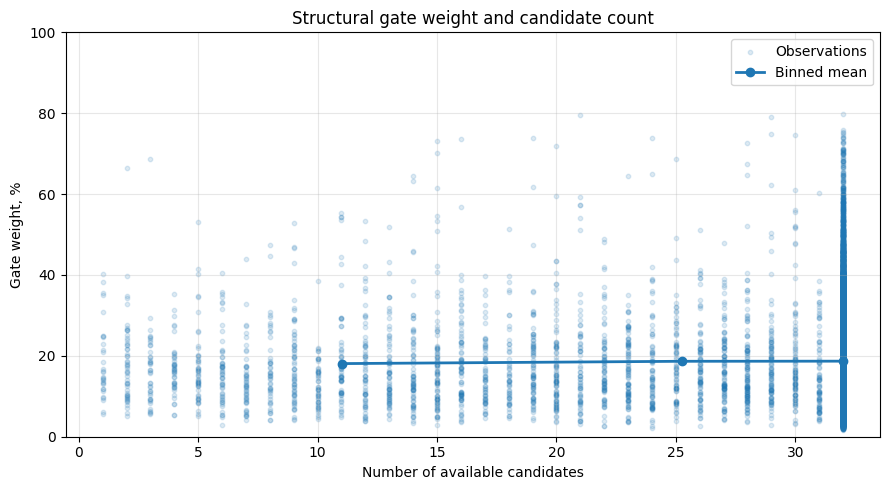

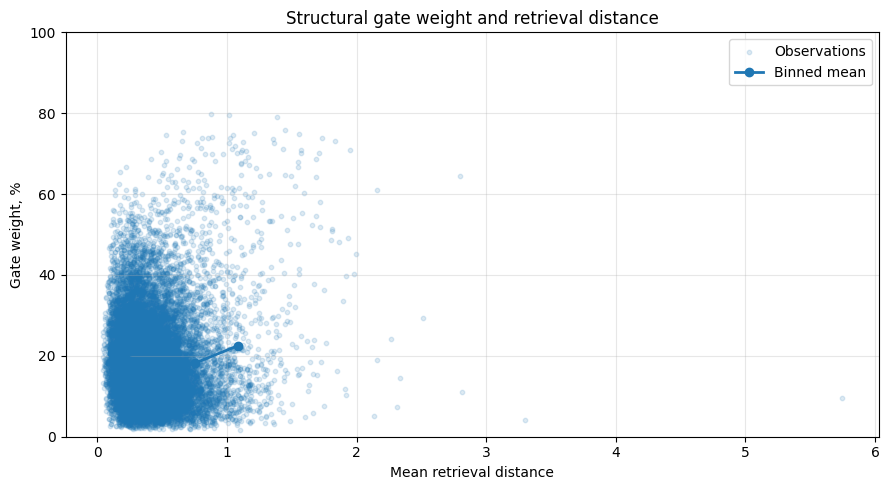

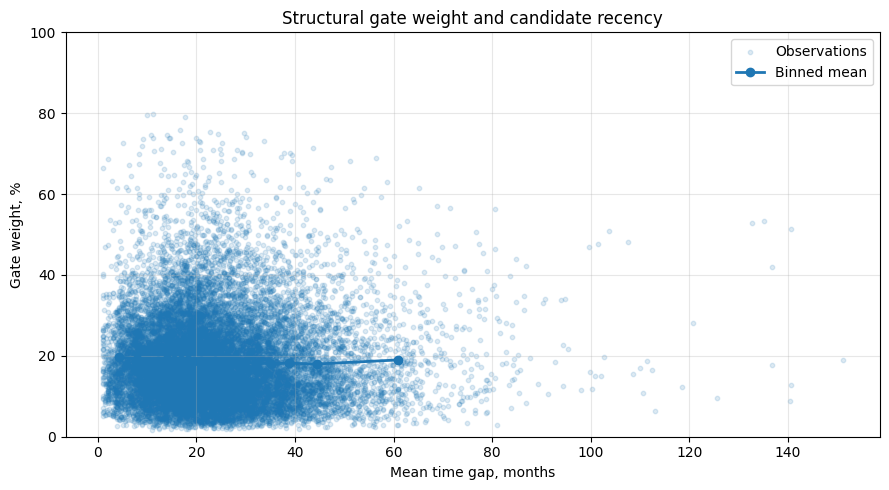

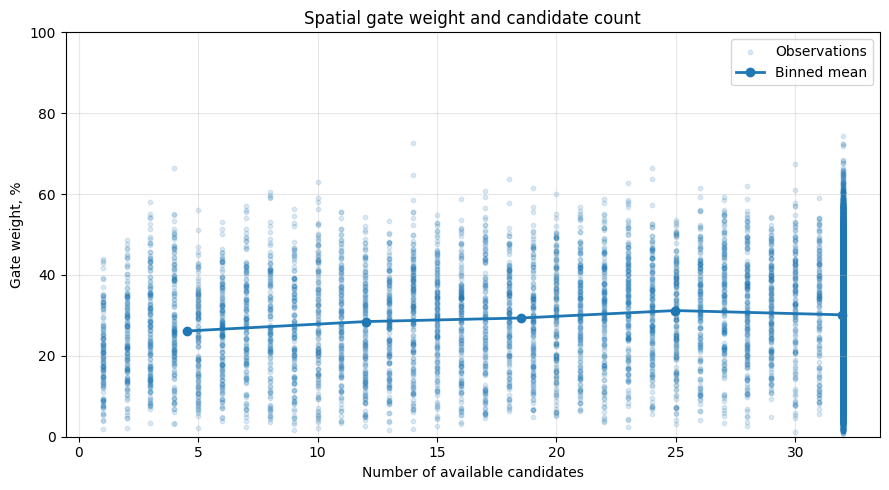

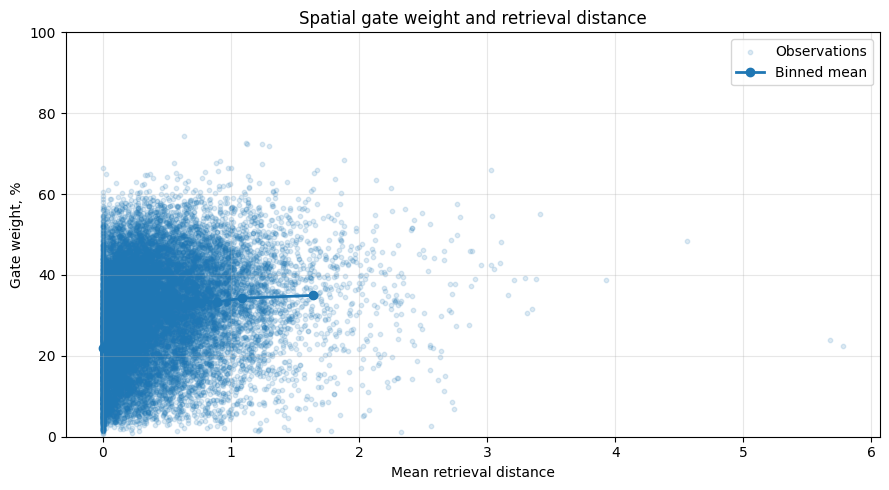

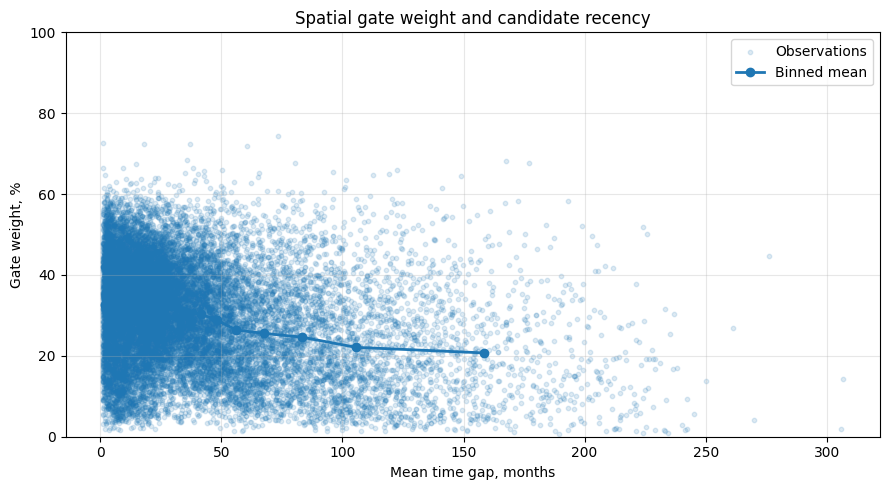

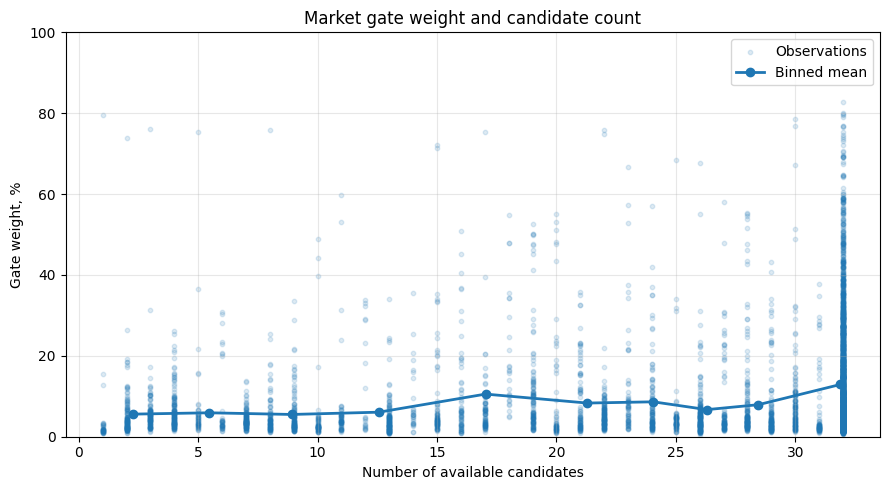

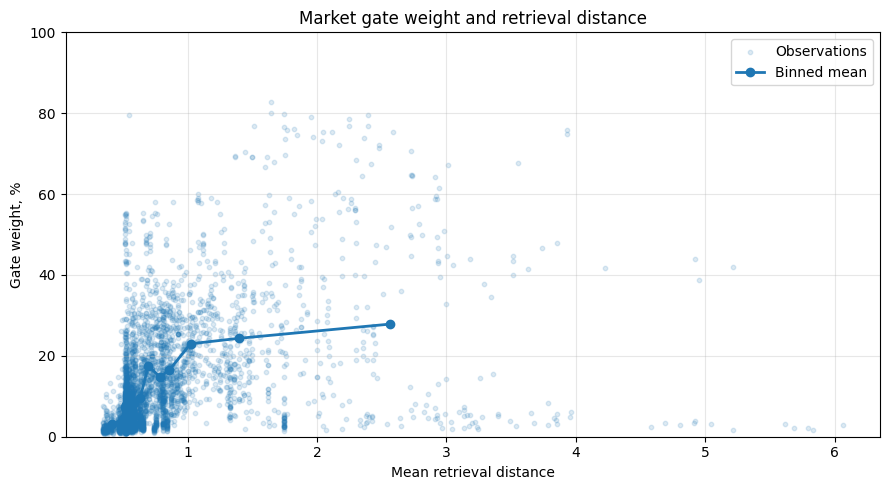

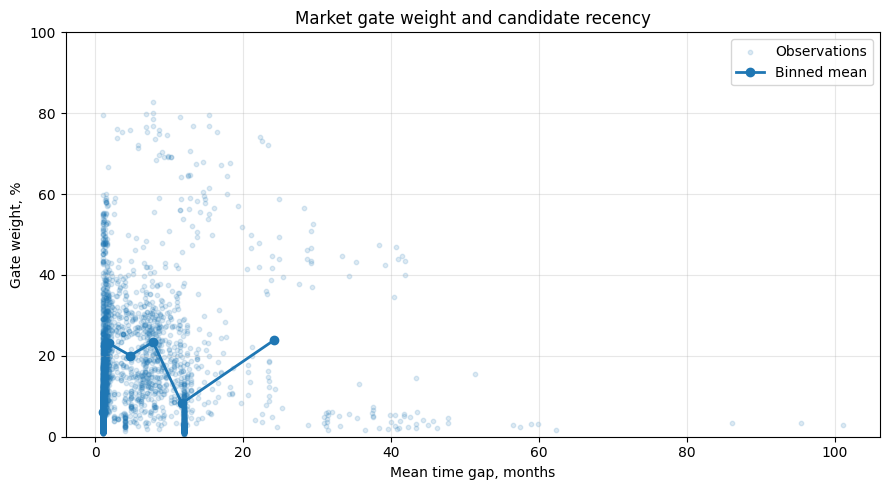

In [274]:
experiment_2_retrieval_trends = (
    plot_retrieval_branch_analysis(
        interpretation_df=(
            experiment_2_interpretation_df
        ),
        config=experiment_2_config,
        max_points=20000,
        trend_bins=20,
        random_state=experiment_2_config.seed
    )
)

In [275]:
experiment_2_shap_results = (
    calculate_target_shap_analysis(
        model=experiment_2_model,
        train_split_data=train_split_data,
        explanation_loader=test_loader,
        device=experiment_2_device,
        config=experiment_2_config,
        numeric_background_size=128,
        numeric_examples=500,
        categorical_examples=200,
        numeric_n_samples=50,
        categorical_n_samples=128,
        categorical_perturbations_per_eval=8,
        random_state=experiment_2_config.seed
    )
)

In [276]:
experiment_2_shap_importance = (
    experiment_2_shap_results[
        'combined_importance'
    ]
)

experiment_2_shap_importance.head(10)

,feature,feature_type,mean_abs_shap,mean_shap,importance_share_pct
0,floor_area_sqm,numeric,0.271578,-0.050456,12.195472
1,cpi_all_items,numeric,0.220928,0.016820,9.921003
2,household_net_worth,numeric,0.181801,0.013830,8.163964
3,resident_households_hdb,numeric,0.108367,-0.003658,4.866322
4,hdb_housing_msr,numeric,0.086190,0.003381,3.870460
5,month_index,numeric,0.085522,-0.004695,3.840441
6,dist_to_raffles_place_m,numeric,0.080143,0.008105,3.598914
7,per_capita_gdp_real,numeric,0.072169,0.003320,3.240812
8,remaining_lease_full_years,numeric,0.071123,-0.014989,3.193866
9,flat_type,categorical,0.067272,-0.000064,3.020916


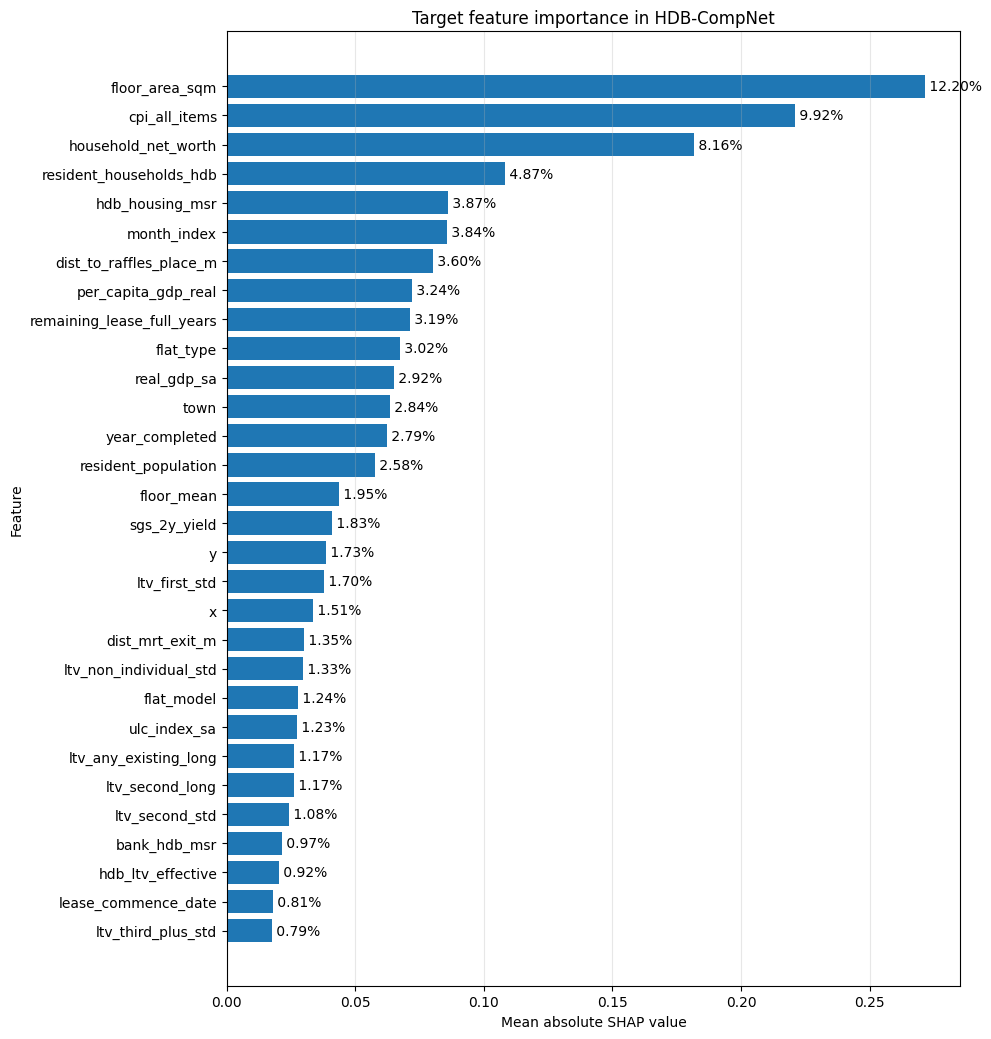

In [277]:
plot_target_shap_importance(
    importance=experiment_2_shap_importance,
    top_n=30
)

In [278]:
experiment_2_numeric_shap_importance = (
    experiment_2_shap_results[
        'numeric'
    ]['importance']
)

experiment_2_numeric_shap_importance.head(15)

,feature,feature_type,mean_abs_shap,mean_shap
0,floor_area_sqm,numeric,0.271578,-0.050456
1,cpi_all_items,numeric,0.220928,0.016820
2,household_net_worth,numeric,0.181801,0.013830
3,resident_households_hdb,numeric,0.108367,-0.003658
4,hdb_housing_msr,numeric,0.086190,0.003381
5,month_index,numeric,0.085522,-0.004695
6,dist_to_raffles_place_m,numeric,0.080143,0.008105
7,per_capita_gdp_real,numeric,0.072169,0.003320
8,remaining_lease_full_years,numeric,0.071123,-0.014989
9,real_gdp_sa,numeric,0.064947,0.007943


In [279]:
experiment_2_categorical_shap_importance = (
    experiment_2_shap_results[
        'categorical'
    ]['importance']
)

experiment_2_categorical_shap_importance

,feature,feature_type,mean_abs_shap,mean_shap
0,flat_type,categorical,0.067272,-0.000064
1,town,categorical,0.063261,-0.054099
2,flat_model,categorical,0.027585,-0.005210
3,nearest_hospital_category,categorical,0.009644,0.002157
4,nearest_hospital_type,categorical,0.006335,-0.003554
